# Depth Anything V2 Small — DIMER E2E supervised adaptation tutorial: zero-shot vs neck/head vs bounded unfreeze on DIODE (standalone)

[![GitHub](https://img.shields.io/badge/GitHub-181717?style=flat&logo=github&logoColor=white)](https://github.com/kurtvalcorza/depth-anything-depth-estimation-pipeline) [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kurtvalcorza/depth-anything-depth-estimation-pipeline/blob/main/tutorials/depth_anything_depth_estimation_colab.ipynb) [![Hugging Face](https://img.shields.io/badge/%F0%9F%A4%97%20Hugging%20Face-depth--anything%2FDepth--Anything--V2--Small--hf-ffcc4d?style=flat)](https://huggingface.co/depth-anything/Depth-Anything-V2-Small-hf) [![Upstream](https://img.shields.io/badge/Upstream-DepthAnything%2FDepth--Anything--V2-181717?style=flat&logo=github&logoColor=white)](https://github.com/DepthAnything/Depth-Anything-V2) [![arXiv](https://img.shields.io/badge/arXiv-2406.09414-b31b1b.svg)](https://arxiv.org/abs/2406.09414)

**Profile:** `E2E`  
**Mode:** `GUIDED`  
**Notebook specification:** DIMER Notebook Specification 2.2 — **standalone** (§4)  
**Capability:** monocular relative depth estimation from one RGB still image and bounded supervised adaptation — the DPT neck and head on the frozen backbone with an optional unfreeze of the last transformer blocks, selected on validation against the untouched checkpoint — measured by affine-aligned AbsRel and δ1 against metric depth, using the pinned Depth Anything V2 Small weights

**This notebook is standalone.** It carries the repository's package (3 modules under `src/depth_anything_depth_estimation_pipeline/`, at revision `24eb2c1efdbd`) verbatim in Section 2, the pinned model identity and the per-file SHA-256 manifest in Section 3, and the exact runtime pins in Section 1, so it keeps working after export even if the repository changes or disappears. Its only external dependencies are the pinned Python distributions and the Hugging Face Hub at the immutable revision `5426e4f0f36572d16453bbda7a8389317b1bef99` (~99 MB, digest-verified before loading). It was generated by `tools/build_notebook.py` (build_notebook.py/2.1); edit the repository and regenerate rather than editing cells.

**Run all:** Selecting **Run all** in a fresh supported runtime installs the pinned dependencies, stages and digest-verifies the pinned Depth Anything V2 Small snapshot (safetensors, 99 MB), fetches 40 digest-pinned DIODE validation views — RGB, metric depth and validity mask, 312 MB in total — by pinned byte ranges of the Marigold evaluation dataset archive at ETH Zürich (no credential), validates them and draws 24 / 8 / 8 training, validation and test views by a seeded split of whole scans, runs one test view through the inference contract with an input manifest, a rejection probe and a `sample-sanity` evaluation report against its metric reference, scores the untouched checkpoint on the test split beside a constant prior and a vertical-gradient prior (the **zero-shot policy**), trains the DPT neck and head on the frozen backbone (the **frozen policy**) and then the last two transformer blocks with them (the **unfrozen policy**), selects the policy ladder's best epoch by validation AbsRel — where epoch 0 is the untouched checkpoint — scores the held-out split with the selected model, renders depth maps before and after, exports the trained tensors as safetensors with a manifest, and reloads that artifact into a fresh pipeline to verify parity. The default path needs no repository clone, no DIMER worker or service, no credential, no upload dialog and no configuration edit (NOTEBOOK_SPEC 2.0 §5). On CPU the whole path takes about four minutes of model time after the downloads; a CUDA runtime is used automatically when present.

**Bring Your Own Data:** After the tutorial workflow completes, set `USE_BYOD = True` in Section 4 and re-run from that cell to supply your own RGB-D records as a `.zip` holding `records.csv` (columns `id`, `image`, `depth`, `group`, optional `mask`; `group` — the scan, session or device — must be non-empty on every row, or the loader refuses the set) beside the image files and `.npy` arrays (depth in metres, mask boolean) — files are decoded from the archive, never extracted to disk. They pass through the same validation, seeded group-disjoint split, priors, zero-shot scoring, policy ladder, held-out evaluation, preview, artifact export and reload-parity cells as the DIODE sample. The expected schema and the ceilings are stated in the Prerequisites and in Section 4, and uploaded files stay inside this runtime. BYOD is optional and never part of the default path.

At inference the image is rescaled so its sides are multiples of 14 near 518 px, passed through the DINOv2 ViT-S/14 backbone and the DPT neck and head, and the raw prediction is interpolated back to the input resolution: a per-pixel map of **relative inverse depth** — larger is nearer, the scale and shift are unknown, and the values are **not metres**. The carried pipeline module adds manifest verification, input validation with named ceilings, the resize back to the input resolution, and the `abs_rel`, `validate_inputs` and `evaluation_report` helpers; `evaluation_report` becomes `sample-sanity` only when a caller supplies metric reference depth — which this notebook, unlike its inference-only predecessor, does.

What this notebook adds to inference is **supervised adaptation under an explicit policy ladder**. The dataset is real and carries metric ground truth: 40 views from the DIODE validation release (CC BY 4.0) — the first two views of each of its 20 laser-scanned scenes, 10 indoor and 10 outdoor — pinned per file by byte size and SHA-256 and read by HTTP Range requests at pinned offsets of the uncompressed DIODE validation tar in the Marigold evaluation dataset archive (ETH Zürich), fetched at run time and refused on any mismatch. Views of one scan share a scene, so the sample is split by **scan**, never by view. The carried `metrics.py` scores a prediction by **AbsRel** and **δ1** after a per-image least-squares alignment of the prediction to inverse reference depth (the standard protocol for a relative-depth model, with the far cap at 350 m); a **constant prior** (the image's own median depth) and a **vertical-gradient prior** (nearer at the bottom) frame the numbers. The **zero-shot policy** is the checkpoint as published; the **frozen policy** trains the DPT neck and head (2.7 M parameters) on the frozen backbone under a scale-and-shift-invariant loss; the **unfrozen policy** continues by training the last two transformer blocks with them; the epoch with the lowest validation AbsRel is kept — epoch 0, the untouched checkpoint, competes on equal terms, so the honest outcome "do not adapt" is available. The adaptation question is whether 24 DIODE training views buy anything over a model trained on 62 million images. Nothing here is a quality claim about your images: it is one seeded split of one small corpus.

**Learning objectives:** install the pinned runtime; read what the carried pipeline, metrics and dataset modules guarantee; stage and digest-verify the immutable upstream snapshot; fetch a digest-pinned real RGB-D corpus and validate and split it by scan without leakage; run one view through the public inference API and read a `sample-sanity` evaluation report against metric depth; read AbsRel and δ1 beside two trivial priors and understand why a relative-depth prediction must be aligned before it is scored; run a three-policy adaptation ladder with explicit hyperparameters and validation-based selection in which the untouched checkpoint can win; evaluate on an independent scan-disjoint test split; compare depth maps before and after; and export a safetensors adapter (neck and head plus any trained blocks) that reloads against the pinned base with verified parity.

**This notebook does not demonstrate:** metric (absolute) depth, video or temporal depth, stereo or multi-view fusion, surface normals, 3D reconstruction, batch inference, data augmentation, full-backbone or patch-embedding training, and any claim that 20 DIODE scenes stand in for your images. The repository exposes none of these; an adapted model still emits relative inverse depth.

## Prerequisites

- **Runtime:** a fresh supported runtime (Google Colab, Kaggle or Linux Jupyter — **Linux x86_64 only**; the notebook builds its own isolated Python 3.12.12 environment). The default path runs on CPU and uses CUDA automatically when available; float32 on both. The build record measured about 0.4 s per 1024 × 768 view to predict on CPU (3.2 s for the 8-view test split) and about 0.8 s per view per training step on the last two blocks with the neck and head, so the five-epoch ladder over 24 views with six validation passes took about 150 s. The pinned `torch==2.14.0` install and the 99 MB checkpoint are the large downloads of the run, then the 312 MB of DIODE files.
- **Knowledge:** basic Python and NumPy; the difference between inverse depth (larger = nearer, arbitrary scale and shift) and metric distance; why a least-squares alignment is needed before a relative prediction can be scored against metres; what AbsRel and δ1 measure; what validation-based selection between policies means.
- **Data contract:** records are `{{id, image, depth, mask}}` — a PIL image (or a path to one) with sides 14..4,096 px and aspect ratio at most 4.0, a float H × W array of metric depth in metres (or a path to a `.npy`), an optional boolean H × W validity mask (missing means `depth > 0`) covering at least 5 % of the pixels, depth at most 1,000 m, ids matching `[A-Za-z0-9_.:-]{{1,64}}` and unique; a training set needs 4..2,000 records; images are de-duplicated by decoded-pixel digest and split by `scan` / `group` so views of one scene never straddle splits. Only reference pixels inside 0.6..350 m are scored. BYOD accepts a `.zip` (or a directory) holding `records.csv` and the files, and requires a non-empty `group` on every row — the notebook's automatic split is group-disjoint only because the loader refuses ungrouped rows (`load_byod_dataset(..., require_group=False)` is the explicit opt-out, without that guarantee).
- **Validation is structural, not semantic:** nothing checks that a depth map belongs to its image or that its unit is metres beyond the 1,000 m ceiling — a mis-paired or mis-scaled set is trained on without complaint.
- **Privacy:** Do not upload confidential or restricted data to a hosted runtime unless you are authorized to process it there — RGB-D captures of homes, workplaces or people are exactly that. The default path uploads nothing.
- **External access (data):** besides the Hub snapshot, the default path fetches 120 pinned objects — for each of 40 DIODE views the RGB PNG, the `_depth.npy` and the `_depth_mask.npy`, 312,448,846 bytes in total, one SHA-256 each in the carried `SAMPLE_RECORDS` table — by HTTPS Range requests at pinned byte offsets (`ARCHIVE_MEMBERS`) of `share.phys.ethz.ch/~pf/bingkedata/marigold/evaluation_dataset/diode/diode_val.tar` (6,400,440,320 bytes, uncompressed; a reply that is not `206 Partial Content` with the pinned `Content-Range` is refused), each refused on any byte-size or SHA-256 mismatch before it is decoded; the files are DIODE's own (CC BY 4.0, Vasiljevic et al. 2019) as served by the Marigold evaluation dataset archive at ETH Zürich PRS. (Until 2026-10 the same files, with identical digests, came from a Hugging Face Hub mirror that has since been withdrawn.)
- **External access:** the Hugging Face Hub only, to fetch the pinned `depth-anything/Depth-Anything-V2-Small-hf` snapshot (~99 MB in total) at revision `5426e4f0f365…`. No repository access and no credentials are required; nothing is installed from this repository. The isolated environment also needs PyPI (`pypi.org`, `files.pythonhosted.org`) for the pinned `uv` wheel and the 47 hash-locked packages, and the managed CPython 3.12.12 build (python-build-standalone) that `uv` downloads.

## 1. Install the pinned runtime (isolated environment)

Hosted runtimes such as Colab import some packages, NumPy among them, before the first cell runs, and Python cannot swap a module that is already loaded. Installing the pins into the notebook's own Python would therefore leave mixed versions or require a manual restart. Instead, the next cell builds a separate environment (`dimer_isolated_env/`) and leaves the kernel's packages untouched: it downloads the pinned `uv` 0.12.15 wheel and refuses it unless its size and SHA-256 match, has `uv` install the managed CPython **3.12.12** (whatever Python the kernel itself runs), and installs the 47 packages of the carried hash-locked requirements (`tutorials/requirements-colab.lock.txt`, compiled from the pins below) with `--require-hashes --only-binary :all:`, so every package, direct or transitive, is the exact file that was locked. No repository code is installed. The lock holds manylinux x86_64 wheels, so the notebook supports **Linux x86_64 runtimes only** (Google Colab, Kaggle or Linux Jupyter); on any other platform the cell stops with that message. The printed dictionary names the isolated Python version and the kernel's.

In [ ]:
# @title Infrastructure: install the locked runtime into an isolated environment
# dimer: kernel cell (runs in the notebook kernel, not in the isolated environment)
import hashlib
import io
import os
import platform
import subprocess
import sys
import time
import urllib.error
import urllib.request
import zipfile
from pathlib import Path

PINS = [
    'torch==2.14.0',
    'torchvision==0.29.0',
    'torchaudio==2.11.0',
    'transformers==4.57.6',
    'safetensors==0.8.0',
    'numpy==2.5.3',
    'pillow==11.3.0',
    'huggingface-hub==0.36.2',
]
MANAGED_PYTHON = '3.12.12'
UV_URL = 'https://files.pythonhosted.org/packages/1e/fd/432451d732917c49152a291de3ef171aa6b0f1a22d39780fb2c1f085ca4c/uv-0.12.15-py3-none-manylinux_2_17_x86_64.manylinux2014_x86_64.whl'
UV_BYTES = 20081404
UV_SHA256 = 'aee9802f46bae436bd91751bb33ddeb379ef1596b5c19df193219d545d244b60'
LOCK_NAME = 'requirements-colab.lock.txt'
LOCK_SHA256 = 'b2266d8fec3542bd1d5a94cecb8c0d9e4ef9fc9345bc5cc8596f4e803a1e80df'
LOCKED_PACKAGES = 47
# The hash-locked requirements, compiled from the PINS above with `uv pip compile --generate-hashes` for manylinux x86_64.
LOCK_TEXT = r'''# This file was autogenerated by uv via the following command:
#    uv pip compile pyproject.toml -c <workshop requirements.txt versions> --python-version 3.12 --python-platform x86_64-manylinux_2_28 --generate-hashes --only-binary :all: -o tutorials/requirements-colab.lock.txt
# Direct pins: the pyproject.toml dependencies at this revision, unchanged (torch 2.14.0, torchvision 0.29.0, torchaudio 2.11.0,
# transformers 4.57.6, safetensors 0.8.0, numpy 2.5.3, pillow 11.3.0, huggingface-hub 0.36.2). Every transitive version is
# constrained to the workshop notebook's carried requirements.txt, so both notebooks of this repository install the same files.
certifi==2026.7.22 \
    --hash=sha256:62f22742b58a1a33014a2b6b706588a8d7e2a88ae7bd1a6ebe8c992928483775 \
    --hash=sha256:741e2c3b351ddf169a738da9f2c048608ff7f2c5cc02f1ebc6b118bb090d5d55
    # via
    #   -c <workshop requirements.txt versions>
    #   requests
charset-normalizer==3.5.1 \
    --hash=sha256:00668ebb0609751758682eb0b5857e7c35b9f00e84dfdef062e103244ec94d45 \
    --hash=sha256:012a22b88a77ca2e59b98ac5889b0deb604147666032f45e6d6e217634d2550d \
    --hash=sha256:01e93745f7f219b703b60ba7afead36cfc4242782be5af484673fc500df12da5 \
    --hash=sha256:04368edf83514385ffc3e1cfd4546e595f4f1272dd23ba437a93a9cc3741d47b \
    --hash=sha256:0722590aabf9dc6a6c0343d523c05458fa2b5047dbe6302fd526bb570600753f \
    --hash=sha256:07ffd07412fc5d5e84cd8952acf9ff7e4ed7a708e69d1bada19d8ba91711353f \
    --hash=sha256:09a7bba9f739468c8e78c36a75c33768e53cb1959fc638f510454c14683f00d5 \
    --hash=sha256:0b2b1b3fa5670c127b246df1d0c059defd41f689a868a3b9d79df9b1cac42d22 \
    --hash=sha256:0c6dfb5ca6723eeed15aa8e564a014d69fcb8812f94eef11fe3631e0508199f5 \
    --hash=sha256:0d929fc574b4d6fd9e7c0f5c2ede8716a41911923aa7fa5fce38e0818aa4a1ac \
    --hash=sha256:13e3afe97712e8887cd516e960c63f0b93122971e5b5e4b2622fe7701771e838 \
    --hash=sha256:15f024313246a4ed976c60f440bb8d257815513a681d212ff74fd46f7d715a90 \
    --hash=sha256:195ce897c6153c0700078142cf8efe3e6454ca4cf4357499e4078dfd83396626 \
    --hash=sha256:19a3dd5aa73cef1c99687c4fc57db016a9c17104ae1185da88ba566a5d3bebe4 \
    --hash=sha256:1d1c7a53a6c2103925cdd6d7229f8c567379f211c869793df679f2e9f738c369 \
    --hash=sha256:1f5883d77fd409a261abb5dc8ccbe335720d798b1de4abb3b1d47ccbbc76b53b \
    --hash=sha256:21b82d8082f6f5e7f456ef0bd16323d08de1266efbfeb476e64b2a91d1471a4e \
    --hash=sha256:252d099029bcbea642f2a06c4ed5046bdf8b5a8150b64afa5e027e88b106e5ee \
    --hash=sha256:256dd4d85d9e4dc595e2bc983c980e73f62ddeb3165c58b4c3dfe78c5c8548c1 \
    --hash=sha256:26422d45fd13551cf564c58932f7d72b4f58b93b0fcf18c35ba6be12b46bb102 \
    --hash=sha256:2679de311c7946dde5d3b6f44941844133ff5c7cb86099c0061ab1e8901c20a8 \
    --hash=sha256:29880d17a8eb0b5cfdfd8944b468322928059aa35f1f5fa8ff22b149ec0b42f8 \
    --hash=sha256:2bced4061f000f7187254a02ad3433ae17eaf991747ceea2f478422590a5bba9 \
    --hash=sha256:2e9cf9253119d8e5d111f05d71626786fd3d6193817316eab1ca088cdb8593cf \
    --hash=sha256:2f06b7eae9dbe77fe1d644ca244dad508de8d302870a43f3c559b521270938a0 \
    --hash=sha256:2f293479cce755c75f1697e87c409b7ae4c555c7dfecb6e988ad13abba943031 \
    --hash=sha256:329fc3ccb63ad22d867d84c2adea759a64079a37ba4a343433b02c7a2816871e \
    --hash=sha256:343fb4f2821043bd87095f7b08a1a181febc8e36ac64212143bbfd0a0e1bc235 \
    --hash=sha256:3588e376b3ea2eea84976f67273d679f229e24c66dce7b82ae45aef04ff6e072 \
    --hash=sha256:35aea775dc2bd5f54cd84a1cd2696cc3207c479cb9cf0bd346f0d343e4300ddb \
    --hash=sha256:35fe081843b35aad20ffeccec3eeffbe637b15d14f3fb22cc1b59cd8ec17e93c \
    --hash=sha256:36047af20e17097c3bb9476c2b7655f2f7aa51322c0ba58c07695bedf755a950 \
    --hash=sha256:3617ac3cfd8b9888f145ad89dd6e692285834b0201c6074a5eeaad3fd4d668c2 \
    --hash=sha256:366ec70f5547c640d3ce1985722490f23faf4eb5216a7eeba78277490e78dacb \
    --hash=sha256:394fea06235c8543390050ed5f529187074b029fb027213f6c46ac11ab5d950e \
    --hash=sha256:3d27167433c0d5f18dc850f07d0b3816221984fecdc405d6c157a6f0b8f8e9e6 \
    --hash=sha256:3e5e1224c0a6a90e05843e07adfec669edebec17801c67072f51e59561d63c0b \
    --hash=sha256:41876ee62a3dddf48ff1121ad8f0798032aa03f2fd35f21f34a4cab14f18d8d2 \
    --hash=sha256:433c5a81eade63b47e522303bad236f59dba55ea6951746f5558355eeed8c75d \
    --hash=sha256:4582c27e8c889d64811987b5967fbd3ae0c823fe1fd933b543d55ac20bb475fa \
    --hash=sha256:485a0d363cafefcd2538a73c7c838daa2035f09b2c9f9b5e3133f80c6aeb84c2 \
    --hash=sha256:494b70049a4d69aec6e8137c13af4cf8db8c9f9820a1392ac293b0dd2987a818 \
    --hash=sha256:496846868fea80e479324862fa877f02411f2fd0f83b79ccee2607aa68b2a032 \
    --hash=sha256:4abdc5f9ad448c1ecbfae2974b820535d6bc6e7eef63babbab3d81cf46968c71 \
    --hash=sha256:4b599739b93b2cbeded49645ae3c8d1405c29ddfbceac1545c87a3f9580a9e96 \
    --hash=sha256:4bea7f8ebe90bbd7f0e4a2de42ca6924ba23e3e76418c408ff82f1d46fabd687 \
    --hash=sha256:4c4fb141a727957c93edfe5c32a26ceb6b5f6461d67146e2d39f51e16170bea8 \
    --hash=sha256:4c9548dc78002099910abaebc0a72ac58b7d30931869e0351c09b507dff4ece3 \
    --hash=sha256:4d26f14f041e83dd8edfd61f4cd4fa7285d31798b5bf1f28e70c367ba6c41d61 \
    --hash=sha256:4f298bdadb8f0b9e5672877f647d1be9373ef5320c9e2f049795e26cad28b6a9 \
    --hash=sha256:52ec005752a56ae79547a05c0139ca2501a0c866390b6115008456b9f0e7cde1 \
    --hash=sha256:55261ac0d2941c42f196dd576f543d87a8ee03cd6f5e30dfb4d807b2e3b9121a \
    --hash=sha256:56490c595a28b1bb27dfc583e816152a9767721ef58b2c03b13f954d2f707420 \
    --hash=sha256:58d3e12c88e0950bca850ae1f7c256055c097639c2edb9eb123af9807d8b15e4 \
    --hash=sha256:58d4aa13a59c969dbfdf9e6a9560e242cbfd9e8a8f50c2747714df1a423adf65 \
    --hash=sha256:59171c6e45bf07d0d5cab3b0bf81d945035530f6873398b3b531c31184d46663 \
    --hash=sha256:5b6d1386bf0096d26d3a863dc0a487a5b4eb9aa93cf5ba69683d29dde6b9d60f \
    --hash=sha256:5c0ea61a470e070686aa30892fed79e297d2c8d0ab46b8bcdf027d38c51da591 \
    --hash=sha256:5c84bec0ab5ae0c64bfe73a7d2adcb5ce73b467523fc27fd6a28ab2aa6cbe35a \
    --hash=sha256:5ca0555312ae2fe82715cada7fac375530c2f3349e1eaa1bcb33d0283ac79a18 \
    --hash=sha256:5d8531a6569d025f68e2321e7638fb7978f23db58e5f69f56913837aae03816e \
    --hash=sha256:5e2d0e146dcb57034f8b97dc58d2d512cb90aba253960ce449f695fec6a82c6f \
    --hash=sha256:5fc45d653ea8c9a20479167e11d4a0f8cb2fa3470737ab6f9c827532313187b7 \
    --hash=sha256:6117b84ea48435e5356dc737f5121485c30920ba43375fa7b434fd753df0eac3 \
    --hash=sha256:6199d5606e2bbf2b096cf64d03f8b6790c91081d5ac866b8e7bb6422738cc60c \
    --hash=sha256:62b55f6722735a6c472f88361cde6640608773d9443cebdbb51abf436a1fcdd3 \
    --hash=sha256:687c9ca3035544b113bea2055e180af96fb63c0c476e22a9180f51925186e7b7 \
    --hash=sha256:6b7430cf5728e68f6c462254009a6ef4086e1bea43cf2f57aa9c55fb4f50ff96 \
    --hash=sha256:6ba32c4d2abf1d2fe7cf27d280f4cca5664233b0f885549c7761719eb977f486 \
    --hash=sha256:6c9cdde8becb25a7fde49924511aa2644d6f8081cc8df8e9452724303348d8e3 \
    --hash=sha256:6df0ec430f9a831772c23ca5a224cba36517a58a84bb32c32bb59a9fa67c47f6 \
    --hash=sha256:6e2912d4babbc65196ac13c2f53468dc57fb8b9c25ef913e8c59ddf7c6dc0e1b \
    --hash=sha256:6e5e4d73d588ca5ed09df1b7dcd1b203d1df3c542e3f50d126c947d432b10731 \
    --hash=sha256:70055ff39b97c99e7ae40ea3e393fb62aa2e44dbd9b29f8d14f42fb0025c3959 \
    --hash=sha256:706bfd38730a5ac7a365793269a00f4e988178cec121391f4248d84ad8c972e9 \
    --hash=sha256:7235dc28fc6dd9d832ac7c7bce95367dedb85929f17368a0c2bee1e080b9acbf \
    --hash=sha256:774d157f112367ff4abd29019f38f023c24e00e56edc7829c20e358a5a913ad8 \
    --hash=sha256:77efcff2b23071c349402ac1066667a3d011f62398d81408c9b88ad991747c9e \
    --hash=sha256:789b8982559ae28dad2356519f841655756cdcd96616410590ae0b17454ee64f \
    --hash=sha256:7ac76cf9afd34929d76eb7fcb63be476a4853d8a96f0dcf2d0db68a0cbdf9885 \
    --hash=sha256:7c0c10730342b0c9b35dd1d619beb8214e520bd96a1f870f452680b238aab3e0 \
    --hash=sha256:823f82903d189af463d7df250ef1f7f696f3cee08cc8d91deb565e8d425f6506 \
    --hash=sha256:838648accb3a7fd9803fd45c87bce8509648eb0c11bc34e216141300977244f2 \
    --hash=sha256:854066be00447fa8de2ccbbe893e2ffc4b123ef16d897af794c1e18bd4a714b0 \
    --hash=sha256:85d5855daafc240cc045c026d7a15fd198a09b0fc8ff6f5ecbb5297b509cb11e \
    --hash=sha256:85de3134b5379856e323ba37c19c9256d39425f7b76a63af52b09fb4664c2e8f \
    --hash=sha256:87e4f41d375c0b9be2fb5251aee4b8a689169e134535aed81bf085c3b647451e \
    --hash=sha256:88ca277405c2d3b71c4e1c2ee0e7966e807bcba86a69d11e19ba199d18ae4491 \
    --hash=sha256:88e85ab89cb822c1e635f51d6d32e488f94e002e70e2f492bdb8b945543f345a \
    --hash=sha256:8ac8c94b6539074e0f40899301273ac8402b9b3e01c7b7ba269ff30340aaaf20 \
    --hash=sha256:8fe532b3c966d1fb794e0698e4589d0444017ae77fc0b31edea13c0e35bcc449 \
    --hash=sha256:9085f87b0e38a2b92b8923059b4e8789fe40d9279712d15dcc670048d77079af \
    --hash=sha256:90b7481fb62fbe172c558bc6fd1c4c98d82004a54a7551f20e11ac9bf0b8708c \
    --hash=sha256:92caef967d287a407085d61176fce4012b1dd62daed4eb6d5ceb26d3d2538712 \
    --hash=sha256:9362dd90aa7dab48c0054a21187791ccf05473f7dba5d92b8033ae62164675e7 \
    --hash=sha256:94d78ecec2605a8d0398b0f365d5f12a63248438516f5dac536a5eff7337df4a \
    --hash=sha256:94fbf1c0c6cc0d3d5e50f9a9313a8cdca90dd696d34b381cd1704f8c9e939f20 \
    --hash=sha256:950f23cb393f85543777b0433f082cddd25b51ab398eac7971146495679efe5f \
    --hash=sha256:96eefc178f8636b9c760c5829345307fd81cfae9ab1e80997dbddeb0f54ee9a3 \
    --hash=sha256:96fef3e886d6a9874b14f27fc193fbdc69d5d8035783d86aa4e1cea594e695f9 \
    --hash=sha256:977cdbd483a9cff38179bea4fd754289a6f2195c7abd414aba85410b3e66cc5e \
    --hash=sha256:978eab16f55b4ab2c2a745be9a0a840bf8f09a7f227d9c76eb30214d078865a5 \
    --hash=sha256:994e883d17c559cdfd38c84003c8b27d25424a1077272a17e7cd27bfe0bf57b2 \
    --hash=sha256:9ac4444d8d4fd4c4bd08bf451ed3167aa9e7ec6cdb41b648794f1d1103652e36 \
    --hash=sha256:9b5db6052055d34d41230fb78d7c439c23dc536a9896f6cb039e8dd92cfc1263 \
    --hash=sha256:9d9a0dc7cbe9bec24c3f767c9122c41fe5a1bc43f47cd099d00d393e09769de4 \
    --hash=sha256:9dbdd9205662134957cf0c324f639bdc5031c0ca056e2369e238db75187c0f11 \
    --hash=sha256:9eea3ab2597a5e65fe65296e2d6a84570845a6b55532d90333d740d48bbc850a \
    --hash=sha256:a2028475ba855475b8b4d3cfeb4994269c967aea8b9892dfba907f4263a863a3 \
    --hash=sha256:a3a370082ce34d0612f421e15fe011c53bb1feff21a26d06ad4fb244dab5a375 \
    --hash=sha256:a545775cfe815855ea32d7c27731d79da358ef2055b4a25830231b1622dd18aa \
    --hash=sha256:a5cbd90ecf0fc62e64726917ad083b73001f0563657a87ec3c0b504e277dc90d \
    --hash=sha256:a6d095662e73e74f0a49988e0593373e243e3a52e27bfeea0a859e88acf4a0f5 \
    --hash=sha256:a6dac12ff6b846103483683f60c5f8fee205121adc58ffd87e90a90a3af69e99 \
    --hash=sha256:a951ad59cad9145664a730d3036b40b844e74d2d3683da40111463cd3a83845d \
    --hash=sha256:aa1099b956fb795e686d073568f6dc002a0bb89765ea6d5b055dd7d9bf1b116c \
    --hash=sha256:aa2bb0b37202dca27175591f761108b5d34096ade1191ffe4808bdf6b1571488 \
    --hash=sha256:aae2ee51122d3ae968a3837d97dc24a0aeebb0dea23694422cd172bd30017cd6 \
    --hash=sha256:ab743e9bc90c1f73552ec33e10e3331315acd2c397b36065b591b0181de533cc \
    --hash=sha256:ac00177c4831ffa650f8609e4bdddd5fe09c03b1c0c47acece7e6ea20421598b \
    --hash=sha256:ac13b004224fb341e1e25a1ed5e19d32f57cdb2a403e01f003b46f051a550f6f \
    --hash=sha256:acaf604462bf330b0d07e7a07c1d6e4adac79e5fb13e9c5140590542cafacc00 \
    --hash=sha256:ae31a1a1db2ee6cc2942fccaf695c934bc7f3db9f2133a3fef1f367cf1a4ab10 \
    --hash=sha256:ae4a097991662cd4fff0ddc74e0fe7874f82e00042fa0ea00855645ed0c79598 \
    --hash=sha256:aea996a6aba25260827c9ea511d1addfde2da9eb686ac961838509086188b7e6 \
    --hash=sha256:b39b69b347e5e47a3b5b8cfc005c68c1ba347474e3960236c4944a8ecd174962 \
    --hash=sha256:b54e7e13267d49ffbfe68e25b3cbd774dab38fa37238f71265e91b36146eb21c \
    --hash=sha256:b9af956078716df40d985fb0dfeb2c2120c5ca92ba4ff4b388acfd01cdc14d08 \
    --hash=sha256:ba2f37ee79e6338845261a3c5b1784e5d1acdff2c0785b284f1b633033d136ab \
    --hash=sha256:ba501e667c17d8411f98e67a022d9604ef179aff0e459b7e292c796837c13573 \
    --hash=sha256:baf3775a2635e5a11fbd5e4e64ee69c7e86875d224a5c72aca4c141064589a90 \
    --hash=sha256:bb57753e36e4855b8ca375069482250a6246372331a3e4f3407eaebb007443f5 \
    --hash=sha256:bd6c173f04743d483881bffa1478d5a4624475b8cd1d2194956a75548e191c18 \
    --hash=sha256:be47f99644b208bff7766314013f9acf57b056b04191d570d68ad14022cf5b1d \
    --hash=sha256:c010f5581d9c612804cc59fcf7b524b707fbcb72828551237ab545bb5c7034af \
    --hash=sha256:c1dcc36dcb96abc02236e182d17e0f71430152a6c2c7447421da2d2dc144edea \
    --hash=sha256:c428c6c31eb5f4277d7f8eccaf767fbd548ddd5ce3c8b4f4cbbfab3d96b5904c \
    --hash=sha256:c658c50ac0c98cd755a2dd50b7977d3bca7df401dcc47fbdfa87db53ef7d4e8b \
    --hash=sha256:c71fb0d56c920c269cd3e2e3fe7c610e3f1fdb21a6ce60efa6430ff63676cea6 \
    --hash=sha256:c7b742bf31c88566b4bb6335a7f393bb322e580b6bb98df7bd0c25e6e3519ce8 \
    --hash=sha256:cc0329df4caaceb950d2f580b5ac716a377f7059624a0bafaeaf8a218c6ed774 \
    --hash=sha256:cc5d36d96478aa9c60654bd932525bf32964c62a7281eafdf16d85003a8d6004 \
    --hash=sha256:ce854f5f478050ade5a238731c4ca985a7d3b3cb53ff600a9b5c3b689b5f0a7a \
    --hash=sha256:ced3fdd71aaa83ce593746c2edb42b7a59cb4c19c8b5c407781c72e493aae55a \
    --hash=sha256:cee5dd7c6fb5dd52a0fe2a740f9bc6e3593f5f8b1788bde49de02086f30182b2 \
    --hash=sha256:cfa1c0cc3a8f9f53f1243a5a99ac36fd003880199383b37672e86ddda9cb07e2 \
    --hash=sha256:d1ee1e296209fdce05b81b663250eefa02213a2da7b41bf26f7829b8ba3545aa \
    --hash=sha256:d59b75732e9b6f27388e10c14b0259cc5f2e48c78627d185e6a177b58ad3cffe \
    --hash=sha256:d63600d620ad0064c3a748b950ac5ea38a80190e5498532efefa4b7b3f1da1f3 \
    --hash=sha256:dd732602a7009217f658d5863d12d79d373a4de0eebc111094bcdd3bb8e0a6cc \
    --hash=sha256:e06efa066f7dbadbc84ebc126a97c452a6451dfcf589d89d788484949e1cf795 \
    --hash=sha256:e199fb99720074809a7720f1c0b4d919eea8b87e88713e0f8f602f7bef543d9d \
    --hash=sha256:e4b018dc5a0eee4676e38fe84a47a427816c590b93b55d9025274ec4d6ffc2dc \
    --hash=sha256:e6621fb2a4988d6e53eedc455e5903e2679f3967b8acb3d639f1b63c14a2e893 \
    --hash=sha256:e71c909f353863b2b89c83de2ebed71ea6d0df8a6ef65a128193c5e650766bef \
    --hash=sha256:e90251c0c7bdd54a100a0dce3c07b7e637278c93af29dbf78ebb89a58c4bac7d \
    --hash=sha256:e9fbdce1e47394b09bc9f26ab117dfc8d6491977a11d86f592bb42c779db2fda \
    --hash=sha256:eb12fb2ba69ffa05f8695f61c69e591dc4b4a12ac3757ac8af8adb259bf56d17 \
    --hash=sha256:eda059b6bc8bc0812d626fd91a7ce01bf583df0a61296eff390fd94141a34e30 \
    --hash=sha256:f03ac127268b43ef4fe9e6ab6794a6794b49485a0cc0c1db79876d2f33f75bc7 \
    --hash=sha256:f298e218441525d3794428b4c8b8fb8662c6d3ea79925d4807ee6b9a96a3bca5 \
    --hash=sha256:f5542f9b941279d82d41eb0aa9f98eba36fe4df5c7086c651df7944935b37182 \
    --hash=sha256:f6f7deae3feb4edfa2efaf7c574fe88cbf055038a6abdb40188e4fff66d5699f \
    --hash=sha256:f9b1e28d0e8dbfa858abdba91d6b547beaf2df1a59bec6da6faae7b96a4991a9 \
    --hash=sha256:f9f8405c2c758532c74fed975dbee57be1f31a6e865c031870c79a6ed3212ada \
    --hash=sha256:fa48b1b63d639f9483e0633e092f5851e2348c352f1f9bb6c8182f87884ef876 \
    --hash=sha256:fb78f6e7fcd8ad785d28cd577168bc1aaee827b25bb8755638f694794ea98f0a \
    --hash=sha256:fbc597639158fd7c14d55e808718848319540f51b0e6746e3eefa59723a4a348 \
    --hash=sha256:fce8cbd4997efeb450bd298b54f755dcdff18d496f7a5ddbb4867c6d7c88fdc3 \
    --hash=sha256:fd0350afdc3aabd5576f60ea109228bd5538139713c7b094c5cd27c73a98bc6f \
    --hash=sha256:fd0a274c0e5f9a21565cd9d3dd749b61f96b7aa1e20a93aa1ba4029518f2e5c0 \
    --hash=sha256:fdb8a068947befafba9952162645dc2fecaeb400e64584829ed5e9b2fbe21a7f
    # via
    #   -c <workshop requirements.txt versions>
    #   requests
cuda-bindings==13.4.3 \
    --hash=sha256:044c03b056dcc5cecfad426a071187dd9e1e6817fbb363bc2f3a7520170b3e67 \
    --hash=sha256:0deff5b22462bb410859684299b1fc6a621780c43a4729342aa6ec28783485b4 \
    --hash=sha256:130ff1daae550db2cef559ba477f3a63d040756bd135f5deba4b5bdc4e110252 \
    --hash=sha256:145cc9b02dfb7bcc3288701b6f19c69c590e4451c62916ba0a8a3db9a64a91a8 \
    --hash=sha256:1fd7d8459b364aedc11f3e59703453ced823135f78a9111ca70feef8d56d4d21 \
    --hash=sha256:3d7a6506e625be59cdc119ef4423afa0fc3a4830b129dc010cbd51324b93d66d \
    --hash=sha256:4796864ce829bd95ef2ef0d23c6ba21bb64e08f7fab0a377302ed1affb6605c7 \
    --hash=sha256:52d7f3f5f7f014dddddc66cd802ed0ddf65ae99ad42b5619fae7b82e5ddd6771 \
    --hash=sha256:6c6bb1a4c4f7520e062669c6f3605a7016b2e65ba51b8922f92edd91d5fadf8d \
    --hash=sha256:7e11cfe8fec4c85ce79feda18124971c52596f0cbd642a94f5dafc257124a4b3 \
    --hash=sha256:81eef62bbb95cb4a705fb423b2ad1c63d716edb352ee2af0c28bf8a29cc8258c \
    --hash=sha256:a9ea13b9cfe711515ae83b5efc99101af4d3f8ad882f99724a839c8b5417fb7e \
    --hash=sha256:b89d6e738494b7b95c38e3413f86d32c24682c8e714870531a5a2b193a2fc50a \
    --hash=sha256:bbacde6f75665b197016b986164cfdaa33b17515e5e635a63ddb75926aaa71c3 \
    --hash=sha256:bc51990309b416e0780a11a921ac597ef9c0e52e1bdf5ae0b8e8c4766b66442b \
    --hash=sha256:bfbd3f7d4ac04dd41dc49121b9e408c8283992f47124c2290ecb79bbbadcca8e \
    --hash=sha256:c2af7e69d2557fdb4e5fc1169159fd08da7e861aa84fb83307a1a0396b6b0973 \
    --hash=sha256:d5f72bcfcdf3be23e1da3c792f68f508586f48d037bca8b10f552c4cca5971f2 \
    --hash=sha256:d6eb969920e28f66f8fc3b0b3afcb6e09381cc96bf8e8158d774e9488ae89980 \
    --hash=sha256:d7c6c9f46fca7f3fc61959ef9a2398ac656172145b43f408e0a6492360cf1c0c \
    --hash=sha256:df8b3767facca8acde216460df684dfc3826d519096c13adfd3030a55870dc79 \
    --hash=sha256:e52f66340785a51b8b77f4487329de188f3cabbf37c62e68f410a8299e8677ae \
    --hash=sha256:f8519603001c92bf83e7095df3b8211e3999a9c4ded096b57de0f3ff52b66368
    # via
    #   -c <workshop requirements.txt versions>
    #   torch
cuda-pathfinder==1.8.2 \
    --hash=sha256:4e65059febdb4d19d5cbc4798677e19db2b582f2f702f457b609e571690d357e
    # via
    #   -c <workshop requirements.txt versions>
    #   cuda-bindings
cuda-toolkit==13.0.3.0 \
    --hash=sha256:d693caaa261214ddd7dbb60d68e71cbed884e68c2be7509778f3051da0b91c3f
    # via
    #   -c <workshop requirements.txt versions>
    #   torch
filelock==4.0.4 \
    --hash=sha256:0df72be195ca7892216d16f2edce8d9b93a571f02402972020a8cff84c594c7b \
    --hash=sha256:90999ed63a26ccf86b93b959ab10cf1017f422d816be454ed54cbed263e71ab5
    # via
    #   -c <workshop requirements.txt versions>
    #   huggingface-hub
    #   torch
    #   transformers
fsspec==2026.9.0 \
    --hash=sha256:0f08147951c8cb31d844c3547d631053b127863b60be04cf06e121333ee0e2fe \
    --hash=sha256:8dd6e646e99ea382bd85f97a45e6b526a442d79423a7dc673f1e2756d05fcb5f
    # via
    #   -c <workshop requirements.txt versions>
    #   huggingface-hub
    #   torch
hf-xet==1.6.0 \
    --hash=sha256:0e6e21fa3cdfcdcd76748564bf593870a5e013f47d97cf10aed63aa222cff5b7 \
    --hash=sha256:23379c2f9ec8696d952b16414a2bae72cad86a52df869b050698ba60f538c675 \
    --hash=sha256:2e58454a340b3556dfa4972d5451aff4fba8dd42a236600ba1a1d2b1514f0fef \
    --hash=sha256:35cec30d75c6f9eb9c16a77cef68e85a103b72e24d4b473714ec9ff06428bab9 \
    --hash=sha256:3dc3e35441ba395006af5aaacc40ef2e603c51ef46c3530b9156185f00935ea3 \
    --hash=sha256:4fc74352a17015bd0ee90038bc9efe38db894cde45f268b6712b04fce8cd0acb \
    --hash=sha256:5153e6bb103ad49d6ea9f1b2e230db5a2ea32551ad09a706d2f61d7c7c80d80e \
    --hash=sha256:5789835d7c6bc9436962853192082374297fb72d7eff7e7762ec25ceb7e25338 \
    --hash=sha256:633dc0cd71d32da58ab8c03ad38e2fac452c15c2b0a2866ebf6ededfe0a5061d \
    --hash=sha256:70cbb9c896901600128cb9b6f06e132954fbede1db30f31f7c6c63f84cb7c31d \
    --hash=sha256:75765820ce4700db3750c94acc8fe27c5fae4c9ec000a0dbac3ca082acf97765 \
    --hash=sha256:8fb4f71cba6129110c3374a33f919001ff130488fc23553698e34cc1c2a1198c \
    --hash=sha256:948f15d3a9545cfe5932f6bd8b440f6ae630aee108f14b7bd6c561f7c2dcc522 \
    --hash=sha256:d62671bb130879cef0ee4c9ebe47a14af6c66ec53e6d84dc15936e5ffdfac82f \
    --hash=sha256:f0906082d9932ae0c0057fa194041c22b4e2cdb46b2592ef3b91f020d62a081a \
    --hash=sha256:f2f7278c05c22fd60cb436cda1269649b3e81db65ecdc8496e5e164aa4143e7b \
    --hash=sha256:fb4fadde1b2b70bf4c0c14a6dccbe7194b1c28947fefd5bbe3fed9d940676c3b
    # via
    #   -c <workshop requirements.txt versions>
    #   huggingface-hub
huggingface-hub==0.36.2 \
    --hash=sha256:1934304d2fb224f8afa3b87007d58501acfda9215b334eed53072dd5e815ff7a \
    --hash=sha256:48f0c8eac16145dfce371e9d2d7772854a4f591bcb56c9cf548accf531d54270
    # via
    #   -c <workshop requirements.txt versions>
    #   depth-anything-depth-estimation-pipeline (pyproject.toml)
    #   tokenizers
    #   transformers
idna==3.20 \
    --hash=sha256:a7db850025b95ded1eae8a46181a1a6c56c92c96f0e2b005d9ff8dc0210cab44 \
    --hash=sha256:ab7ae7122974553370f0bdb919e1a960b2cd1bc1ef0276416d896db81c14582c
    # via
    #   -c <workshop requirements.txt versions>
    #   requests
jinja2==3.1.6 \
    --hash=sha256:0137fb05990d35f1275a587e9aee6d56da821fc83491a0fb838183be43f66d6d \
    --hash=sha256:85ece4451f492d0c13c5dd7c13a64681a86afae63a5f347908daf103ce6d2f67
    # via
    #   -c <workshop requirements.txt versions>
    #   torch
markupsafe==3.0.3 \
    --hash=sha256:0303439a41979d9e74d18ff5e2dd8c43ed6c6001fd40e5bf2e43f7bd9bbc523f \
    --hash=sha256:068f375c472b3e7acbe2d5318dea141359e6900156b5b2ba06a30b169086b91a \
    --hash=sha256:0bf2a864d67e76e5c9a34dc26ec616a66b9888e25e7b9460e1c76d3293bd9dbf \
    --hash=sha256:0db14f5dafddbb6d9208827849fad01f1a2609380add406671a26386cdf15a19 \
    --hash=sha256:0eb9ff8191e8498cca014656ae6b8d61f39da5f95b488805da4bb029cccbfbaf \
    --hash=sha256:0f4b68347f8c5eab4a13419215bdfd7f8c9b19f2b25520968adfad23eb0ce60c \
    --hash=sha256:1085e7fbddd3be5f89cc898938f42c0b3c711fdcb37d75221de2666af647c175 \
    --hash=sha256:116bb52f642a37c115f517494ea5feb03889e04df47eeff5b130b1808ce7c219 \
    --hash=sha256:12c63dfb4a98206f045aa9563db46507995f7ef6d83b2f68eda65c307c6829eb \
    --hash=sha256:133a43e73a802c5562be9bbcd03d090aa5a1fe899db609c29e8c8d815c5f6de6 \
    --hash=sha256:1353ef0c1b138e1907ae78e2f6c63ff67501122006b0f9abad68fda5f4ffc6ab \
    --hash=sha256:15d939a21d546304880945ca1ecb8a039db6b4dc49b2c5a400387cdae6a62e26 \
    --hash=sha256:177b5253b2834fe3678cb4a5f0059808258584c559193998be2601324fdeafb1 \
    --hash=sha256:1872df69a4de6aead3491198eaf13810b565bdbeec3ae2dc8780f14458ec73ce \
    --hash=sha256:1b4b79e8ebf6b55351f0d91fe80f893b4743f104bff22e90697db1590e47a218 \
    --hash=sha256:1b52b4fb9df4eb9ae465f8d0c228a00624de2334f216f178a995ccdcf82c4634 \
    --hash=sha256:1ba88449deb3de88bd40044603fafffb7bc2b055d626a330323a9ed736661695 \
    --hash=sha256:1cc7ea17a6824959616c525620e387f6dd30fec8cb44f649e31712db02123dad \
    --hash=sha256:218551f6df4868a8d527e3062d0fb968682fe92054e89978594c28e642c43a73 \
    --hash=sha256:26a5784ded40c9e318cfc2bdb30fe164bdb8665ded9cd64d500a34fb42067b1c \
    --hash=sha256:2713baf880df847f2bece4230d4d094280f4e67b1e813eec43b4c0e144a34ffe \
    --hash=sha256:2a15a08b17dd94c53a1da0438822d70ebcd13f8c3a95abe3a9ef9f11a94830aa \
    --hash=sha256:2f981d352f04553a7171b8e44369f2af4055f888dfb147d55e42d29e29e74559 \
    --hash=sha256:32001d6a8fc98c8cb5c947787c5d08b0a50663d139f1305bac5885d98d9b40fa \
    --hash=sha256:3524b778fe5cfb3452a09d31e7b5adefeea8c5be1d43c4f810ba09f2ceb29d37 \
    --hash=sha256:3537e01efc9d4dccdf77221fb1cb3b8e1a38d5428920e0657ce299b20324d758 \
    --hash=sha256:35add3b638a5d900e807944a078b51922212fb3dedb01633a8defc4b01a3c85f \
    --hash=sha256:38664109c14ffc9e7437e86b4dceb442b0096dfe3541d7864d9cbe1da4cf36c8 \
    --hash=sha256:3a7e8ae81ae39e62a41ec302f972ba6ae23a5c5396c8e60113e9066ef893da0d \
    --hash=sha256:3b562dd9e9ea93f13d53989d23a7e775fdfd1066c33494ff43f5418bc8c58a5c \
    --hash=sha256:457a69a9577064c05a97c41f4e65148652db078a3a509039e64d3467b9e7ef97 \
    --hash=sha256:4bd4cd07944443f5a265608cc6aab442e4f74dff8088b0dfc8238647b8f6ae9a \
    --hash=sha256:4e885a3d1efa2eadc93c894a21770e4bc67899e3543680313b09f139e149ab19 \
    --hash=sha256:4faffd047e07c38848ce017e8725090413cd80cbc23d86e55c587bf979e579c9 \
    --hash=sha256:509fa21c6deb7a7a273d629cf5ec029bc209d1a51178615ddf718f5918992ab9 \
    --hash=sha256:5678211cb9333a6468fb8d8be0305520aa073f50d17f089b5b4b477ea6e67fdc \
    --hash=sha256:591ae9f2a647529ca990bc681daebdd52c8791ff06c2bfa05b65163e28102ef2 \
    --hash=sha256:5a7d5dc5140555cf21a6fefbdbf8723f06fcd2f63ef108f2854de715e4422cb4 \
    --hash=sha256:69c0b73548bc525c8cb9a251cddf1931d1db4d2258e9599c28c07ef3580ef354 \
    --hash=sha256:6b5420a1d9450023228968e7e6a9ce57f65d148ab56d2313fcd589eee96a7a50 \
    --hash=sha256:722695808f4b6457b320fdc131280796bdceb04ab50fe1795cd540799ebe1698 \
    --hash=sha256:729586769a26dbceff69f7a7dbbf59ab6572b99d94576a5592625d5b411576b9 \
    --hash=sha256:77f0643abe7495da77fb436f50f8dab76dbc6e5fd25d39589a0f1fe6548bfa2b \
    --hash=sha256:795e7751525cae078558e679d646ae45574b47ed6e7771863fcc079a6171a0fc \
    --hash=sha256:7be7b61bb172e1ed687f1754f8e7484f1c8019780f6f6b0786e76bb01c2ae115 \
    --hash=sha256:7c3fb7d25180895632e5d3148dbdc29ea38ccb7fd210aa27acbd1201a1902c6e \
    --hash=sha256:7e68f88e5b8799aa49c85cd116c932a1ac15caaa3f5db09087854d218359e485 \
    --hash=sha256:83891d0e9fb81a825d9a6d61e3f07550ca70a076484292a70fde82c4b807286f \
    --hash=sha256:8485f406a96febb5140bfeca44a73e3ce5116b2501ac54fe953e488fb1d03b12 \
    --hash=sha256:8709b08f4a89aa7586de0aadc8da56180242ee0ada3999749b183aa23df95025 \
    --hash=sha256:8f71bc33915be5186016f675cd83a1e08523649b0e33efdb898db577ef5bb009 \
    --hash=sha256:915c04ba3851909ce68ccc2b8e2cd691618c4dc4c4232fb7982bca3f41fd8c3d \
    --hash=sha256:949b8d66bc381ee8b007cd945914c721d9aba8e27f71959d750a46f7c282b20b \
    --hash=sha256:94c6f0bb423f739146aec64595853541634bde58b2135f27f61c1ffd1cd4d16a \
    --hash=sha256:9a1abfdc021a164803f4d485104931fb8f8c1efd55bc6b748d2f5774e78b62c5 \
    --hash=sha256:9b79b7a16f7fedff2495d684f2b59b0457c3b493778c9eed31111be64d58279f \
    --hash=sha256:a320721ab5a1aba0a233739394eb907f8c8da5c98c9181d1161e77a0c8e36f2d \
    --hash=sha256:a4afe79fb3de0b7097d81da19090f4df4f8d3a2b3adaa8764138aac2e44f3af1 \
    --hash=sha256:ad2cf8aa28b8c020ab2fc8287b0f823d0a7d8630784c31e9ee5edea20f406287 \
    --hash=sha256:b8512a91625c9b3da6f127803b166b629725e68af71f8184ae7e7d54686a56d6 \
    --hash=sha256:bc51efed119bc9cfdf792cdeaa4d67e8f6fcccab66ed4bfdd6bde3e59bfcbb2f \
    --hash=sha256:bdc919ead48f234740ad807933cdf545180bfbe9342c2bb451556db2ed958581 \
    --hash=sha256:bdd37121970bfd8be76c5fb069c7751683bdf373db1ed6c010162b2a130248ed \
    --hash=sha256:be8813b57049a7dc738189df53d69395eba14fb99345e0a5994914a3864c8a4b \
    --hash=sha256:c0c0b3ade1c0b13b936d7970b1d37a57acde9199dc2aecc4c336773e1d86049c \
    --hash=sha256:c47a551199eb8eb2121d4f0f15ae0f923d31350ab9280078d1e5f12b249e0026 \
    --hash=sha256:c4ffb7ebf07cfe8931028e3e4c85f0357459a3f9f9490886198848f4fa002ec8 \
    --hash=sha256:ccfcd093f13f0f0b7fdd0f198b90053bf7b2f02a3927a30e63f3ccc9df56b676 \
    --hash=sha256:d2ee202e79d8ed691ceebae8e0486bd9a2cd4794cec4824e1c99b6f5009502f6 \
    --hash=sha256:d53197da72cc091b024dd97249dfc7794d6a56530370992a5e1a08983ad9230e \
    --hash=sha256:d6dd0be5b5b189d31db7cda48b91d7e0a9795f31430b7f271219ab30f1d3ac9d \
    --hash=sha256:d88b440e37a16e651bda4c7c2b930eb586fd15ca7406cb39e211fcff3bf3017d \
    --hash=sha256:de8a88e63464af587c950061a5e6a67d3632e36df62b986892331d4620a35c01 \
    --hash=sha256:df2449253ef108a379b8b5d6b43f4b1a8e81a061d6537becd5582fba5f9196d7 \
    --hash=sha256:e1c1493fb6e50ab01d20a22826e57520f1284df32f2d8601fdd90b6304601419 \
    --hash=sha256:e1cf1972137e83c5d4c136c43ced9ac51d0e124706ee1c8aa8532c1287fa8795 \
    --hash=sha256:e2103a929dfa2fcaf9bb4e7c091983a49c9ac3b19c9061b6d5427dd7d14d81a1 \
    --hash=sha256:e56b7d45a839a697b5eb268c82a71bd8c7f6c94d6fd50c3d577fa39a9f1409f5 \
    --hash=sha256:e8afc3f2ccfa24215f8cb28dcf43f0113ac3c37c2f0f0806d8c70e4228c5cf4d \
    --hash=sha256:e8fc20152abba6b83724d7ff268c249fa196d8259ff481f3b1476383f8f24e42 \
    --hash=sha256:eaa9599de571d72e2daf60164784109f19978b327a3910d3e9de8c97b5b70cfe \
    --hash=sha256:ec15a59cf5af7be74194f7ab02d0f59a62bdcf1a537677ce67a2537c9b87fcda \
    --hash=sha256:f190daf01f13c72eac4efd5c430a8de82489d9cff23c364c3ea822545032993e \
    --hash=sha256:f34c41761022dd093b4b6896d4810782ffbabe30f2d443ff5f083e0cbbb8c737 \
    --hash=sha256:f3e98bb3798ead92273dc0e5fd0f31ade220f59a266ffd8a4f6065e0a3ce0523 \
    --hash=sha256:f42d0984e947b8adf7dd6dde396e720934d12c506ce84eea8476409563607591 \
    --hash=sha256:f71a396b3bf33ecaa1626c255855702aca4d3d9fea5e051b41ac59a9c1c41edc \
    --hash=sha256:f9e130248f4462aaa8e2552d547f36ddadbeaa573879158d721bbd33dfe4743a \
    --hash=sha256:fed51ac40f757d41b7c48425901843666a6677e3e8eb0abcff09e4ba6e664f50
    # via
    #   -c <workshop requirements.txt versions>
    #   jinja2
mpmath==1.3.0 \
    --hash=sha256:7a28eb2a9774d00c7bc92411c19a89209d5da7c4c9a9e227be8330a23a25b91f \
    --hash=sha256:a0b2b9fe80bbcd81a6647ff13108738cfb482d481d826cc0e02f5b35e5c88d2c
    # via
    #   -c <workshop requirements.txt versions>
    #   sympy
networkx==3.7 \
    --hash=sha256:e3fd2c13a7814cee3746340d8d7f8598a67f16a58bf47fb7f8793fab6efca1b0 \
    --hash=sha256:fd77a511bd90f39f3d016351345b52cf5319b813bdca01de3f755d3cca62e96a
    # via
    #   -c <workshop requirements.txt versions>
    #   torch
numpy==2.5.3 \
    --hash=sha256:012e66aca395d795496446e52aeeb5866312a5d4d3f27da270e5a0b43f70dc5c \
    --hash=sha256:09d5a423c71ad5feb5625844ad58050e35df43871004b52ac9c0ad44a56775be \
    --hash=sha256:09ffa5d903faeaa5c4dd05009cf81c8bab9f2cb37c548b8d39b65b4cfa7c97f7 \
    --hash=sha256:0a59a421a32580a009e8a1751345bf829631b990dc1794b80514ab722b435def \
    --hash=sha256:116f96cadd935c6122e9228d676fe7ede19e741f5c8bb1c3cddbe0c51ccebea2 \
    --hash=sha256:1302b90c0e52281681b2975adfe8a860cb7b12216a27b4b0b4207c44bf7bccf0 \
    --hash=sha256:15aa985ac73a8db02db7663381aa109510449d3819d37206caed27b33a65a8a6 \
    --hash=sha256:1aad64d99730d013cfc6debafed22783b4fc5a7f4b8bc744d2d8cf7dcc880551 \
    --hash=sha256:1c80eabb4035ecf4ca9cd49cde8a9fdd69a729e63e6474887d1523ade7aa277f \
    --hash=sha256:1f3ed25271581281f2fccb1adcedfcde4c07362eec69189b50baf6f90e3ae159 \
    --hash=sha256:1fb6f8fb9ff0b3a69f52c66ce397b0246583e9f28616231b0e32ca49259a5fa6 \
    --hash=sha256:214045a5bf00113a146ab9ee9730c44501af6723cdf1f6830932f7b5ef2e7af0 \
    --hash=sha256:26e15e4aecd8617dfbaecb37d223e365d7b39411fba20454be2670a96aa74cb5 \
    --hash=sha256:2c25dfa72943e4336ddb6b0ee4277b47a0c85bede0807530ec68103bf58e2c10 \
    --hash=sha256:2d8240cb4c16fd831074aa2b2cf9fc54664d826341d61c372245b96a74a49a9a \
    --hash=sha256:350ba9783ce969cf9f7ce6e6a9a58e1a6e2a19ca025b7ee448c4db727706212a \
    --hash=sha256:4c8a6d2ebce6305fd82fbefca827775437147052a976ee7c94b36a0c1b52ac6c \
    --hash=sha256:4f8929ee6c96bfbd7b4ed2032e0c03af86fe1826740ab61ddabf9072d06e57ff \
    --hash=sha256:536f963710a4e63934d80ac0dc4f478804a83e9a84b6828018f25d09953ada33 \
    --hash=sha256:54a115e5a73b8fc44f0cebef486365a1894b5c9760685d4558b72b7c3eb846e0 \
    --hash=sha256:595d020938c84e320bcf40ad71089e108eac0d377cd018e14a8c094f39e98d85 \
    --hash=sha256:66a78fe4556c60aceda5916f9eacd638b18e9e681016ec302dcb4682d6d4d034 \
    --hash=sha256:6b05c171afb3aa07adbd20abc00aea86fe375beb0fdb9ef780ec5b7f63bab1c0 \
    --hash=sha256:6cef4bb1706dfec49243c05d921eefb4e190d41e2528b30d8035ea1f36b4c24a \
    --hash=sha256:6f24021b9f22bc6301c37b196974a92c1c18dccedb6fef3dd252e95f2d6adbe4 \
    --hash=sha256:71b39d9f935b6ec0f8753e3e2afb51e3efba6f2e05b68b32a40754d24bcd4a3c \
    --hash=sha256:71cad2b2a7451ab79d8f5e71b453485b6775963d5cf794179144a7463fe6e8ec \
    --hash=sha256:76c2c1e6bfa5c84adc6434dfbf013aa92096a7985221762c8f11fedfd20fff58 \
    --hash=sha256:8617bbfae4486cf99c9f899966699428d19da931d06ca94ad3da986c76e15997 \
    --hash=sha256:86bff898a431c0fb71f7610b75726e75a54d47b37edc9d537f48de63bb3c0b90 \
    --hash=sha256:8e4dd766076855b5ff7ea52fa5f07ce26286726e0f8bff446b7739d02e6ea204 \
    --hash=sha256:92f30e89b8ee0ecf363033576c422b2f58fed6a80bed0aa48dff6d14c654663e \
    --hash=sha256:93e1f5447e2b1e479d7bd74701e84746b86450cff1fc368b132d195e2b8f8211 \
    --hash=sha256:9a37475425b431b4d060f23b4f52cd2f3aef6bc7c654bd760adf0040eec9d435 \
    --hash=sha256:9deb49575e5b0b94ed72c8a64ec4d033381adc27e9060ae842971f697ba96104 \
    --hash=sha256:a5fa86b80fd24bcd1aff83ad23be44ea323de3f787be8f8b15d4a65621e25321 \
    --hash=sha256:a6391fafaba97500887132cd582abc6e19452b1ac775a47caa7b24490e152058 \
    --hash=sha256:a72f874bc9e10e4b8f80426fb49716d5141f64442a0c8418065093ec8017fbb0 \
    --hash=sha256:ac7bb1c52d445bd4f8f7f97fefe6abc3a084dc4d63df50d79b17fa2b78e89297 \
    --hash=sha256:adc1ada2662f8a5f960b8a10d9986897e7499ef07e06d4cfe7197f8cce923c07 \
    --hash=sha256:b00eefbcf0f292945c4b4dec2ae845389ef5bcdcd596e6e4328051db5b5ba694 \
    --hash=sha256:b0521d0f4aebb6e06189451025fa17a913287b13c03d5fe05c017333b654ea5b \
    --hash=sha256:b5d93cf48f687479941d12b69c873ad2cc76bbd487f0091c2200636497f34034 \
    --hash=sha256:b7e18c623bb5c95acb3b3328861272816ba199fb531921c5d6d0b675f1fde9e3 \
    --hash=sha256:bd4cb9ad3c7889b9b3fe0a9a9fb5d2ed26f9879bff2608d9f01aed147a20d231 \
    --hash=sha256:be5a8381859b6da607c84f4f7d6847725f1cf1853ef8a2c9e115b7d58bef47dc \
    --hash=sha256:befa1ae5bd6030b3f512b43ff3fa5290bbed6b84411a44244b14adf835f5b89d \
    --hash=sha256:bf63afbe037eb5d2fe87fbcc7778e61da53ebaf21d938a4515aa73b62532a5d4 \
    --hash=sha256:c00abe94c1a69d75d827dcf1c025b25c8a45d230b3bcd77a9020883a1b047653 \
    --hash=sha256:c2381f82999704f818e2c987a865050e285ec3621262c66d40f5a96c8f899f8e \
    --hash=sha256:c76d5dde9f445058f83d0c02af00557a4db91de9a9a57c0df87d1535001d654b \
    --hash=sha256:cb189f09db39283b26bfd061ec16189e14f71c6755207f72a0f7540867afe5b9 \
    --hash=sha256:ccb32e0525d29e8b0572eb84c9a57af0e7a4e615726927506f55063c62414034 \
    --hash=sha256:ccbc4665079665c3cf3bab4db9f6b095370cd6437d66be549b6c2a1fd19e1958 \
    --hash=sha256:d1c89973648c85069c5046ad460f7b8a00218b29a2e42359ac8cc63e9ab94832 \
    --hash=sha256:df2d5874ff183595a4ba404edd04f6bd9b5505c1d7708573f6a6c17489a67563 \
    --hash=sha256:e01c918ac3d48e18a927cf7b14a26a3e29ff2bdf2eacb976da0aecd6a43ed034 \
    --hash=sha256:e6ab667ba76450084eb64013762c438ea76d9d29cc676dcd6c2e9892ba37f841 \
    --hash=sha256:e931e4f499e0dc7ef29d269a8e5b35dd722e5d14be07df6240166ea7c6532fae \
    --hash=sha256:f54660b0eb6b0b9f36e7fe1cdfdff472028dd0d14acd9b9b65098efbad059469 \
    --hash=sha256:f59a878c33d6b88122d80d239bb3b845d58708750b0cb06a09aebb9b18ec696c \
    --hash=sha256:f7fabeb6cea87d65f3b926de33d03fb016cfdc29314c90974383b5582ae72891 \
    --hash=sha256:f9579f383d1bf9df80081e72760e84960a7fd4f88cf0c9e535a8597c9bb646f5 \
    --hash=sha256:f9a2353b37a1a9e78fd82b27ad7e2a32a2d036604d18f02b05e3136c62ca3b09 \
    --hash=sha256:fc36dc566135b5eceec4cf89758fcb719266a019ef07dae1754ae7c9f617ef3e \
    --hash=sha256:ffdc76bfcae6b255dff75202c5e7feaf95b40246bc0a17944facc1fecf9f79ab
    # via
    #   -c <workshop requirements.txt versions>
    #   depth-anything-depth-estimation-pipeline (pyproject.toml)
    #   torchvision
    #   transformers
nvidia-cublas==13.1.1.3 \
    --hash=sha256:37936a16db8fe4ac1f065c2139360608a543a09275cb1a1af612e08cfa065436 \
    --hash=sha256:b6cdce694e47ff6aadf0a69df1cab6628d696f5ff56e8d16af50309d855fa20f \
    --hash=sha256:b7a210458267ac818974c53038fbec2e969d5c99f305ab15c72522fa9f001dd5
    # via
    #   -c <workshop requirements.txt versions>
    #   cuda-toolkit
    #   nvidia-cudnn-cu13
    #   nvidia-cusolver
nvidia-cuda-cupti==13.0.85 \
    --hash=sha256:4eb01c08e859bf924d222250d2e8f8b8ff6d3db4721288cf35d14252a4d933c8 \
    --hash=sha256:683f58d301548deeefcb8f6fac1b8d907691b9d8b18eccab417f51e362102f00 \
    --hash=sha256:796bd679890ee55fb14a94629b698b6db54bcfd833d391d5e94017dd9d7d3151
    # via
    #   -c <workshop requirements.txt versions>
    #   cuda-toolkit
nvidia-cuda-nvrtc==13.0.88 \
    --hash=sha256:6bcd4e7f8e205cbe644f5a98f2f799bef9556fefc89dd786e79a16312ce49872 \
    --hash=sha256:ad9b6d2ead2435f11cbb6868809d2adeeee302e9bb94bcf0539c7a40d80e8575 \
    --hash=sha256:d27f20a0ca67a4bb34268a5e951033496c5b74870b868bacd046b1b8e0c3267b
    # via
    #   -c <workshop requirements.txt versions>
    #   cuda-toolkit
    #   nvidia-cublas
nvidia-cuda-runtime==13.0.96 \
    --hash=sha256:7f82250d7782aa23b6cfe765ecc7db554bd3c2870c43f3d1821f1d18aebf0548 \
    --hash=sha256:ef9bcbe90493a2b9d810e43d249adb3d02e98dd30200d86607d8d02687c43f55 \
    --hash=sha256:f79298c8a098cec150a597c8eba58ecdab96e3bdc4b9bc4f9983635031740492
    # via
    #   -c <workshop requirements.txt versions>
    #   cuda-toolkit
nvidia-cudnn-cu13==9.24.0.43 \
    --hash=sha256:67a7273b5cf062f9446fd76cf464351a1c0f66501e6cd78f6675c0d604d8ac87 \
    --hash=sha256:71f181cd810e90f9b6023b01186fe82d13d65f0ec098581ee201d39fad769e4b \
    --hash=sha256:a6812a554a1ff0413e9c52b84c26c050380649ab9615f9c16bded368ce9f421f
    # via
    #   -c <workshop requirements.txt versions>
    #   torch
nvidia-cufft==12.0.0.61 \
    --hash=sha256:2708c852ef8cd89d1d2068bdbece0aa188813a0c934db3779b9b1faa8442e5f5 \
    --hash=sha256:2abce5b39d2f5ae12730fb7e5db6696533e36c26e2d3e8fd1750bdd2853364eb \
    --hash=sha256:6c44f692dce8fd5ffd3e3df134b6cdb9c2f72d99cf40b62c32dde45eea9ddad3
    # via
    #   -c <workshop requirements.txt versions>
    #   cuda-toolkit
nvidia-cufile==1.15.1.6 \
    --hash=sha256:08a3ecefae5a01c7f5117351c64f17c7c62efa5fffdbe24fc7d298da19cd0b44 \
    --hash=sha256:bdc0deedc61f548bddf7733bdc216456c2fdb101d020e1ab4b88d232d5e2f6d1
    # via
    #   -c <workshop requirements.txt versions>
    #   cuda-toolkit
nvidia-curand==10.4.0.35 \
    --hash=sha256:133df5a7509c3e292aaa2b477afd0194f06ce4ea24d714d616ff36439cee349a \
    --hash=sha256:1aee33a5da6e1db083fe2b90082def8915f30f3248d5896bcec36a579d941bfc \
    --hash=sha256:65b1710aa6961d326b411e314b374290904c5ddf41dc3f766ebc3f1d7d4ca69f
    # via
    #   -c <workshop requirements.txt versions>
    #   cuda-toolkit
nvidia-cusolver==12.0.4.66 \
    --hash=sha256:02c2457eaa9e39de20f880f4bd8820e6a1cfb9f9a34f820eb12a155aa5bc92d2 \
    --hash=sha256:0a759da5dea5c0ea10fd307de75cdeb59e7ea4fcb8add0924859b944babf1112 \
    --hash=sha256:16515bd33a8e76bb54d024cfa068fa68d30e80fc34b9e1090813ea9362e0cb65
    # via
    #   -c <workshop requirements.txt versions>
    #   cuda-toolkit
nvidia-cusparse==12.6.3.3 \
    --hash=sha256:2b3c89c88d01ee0e477cb7f82ef60a11a4bcd57b6b87c33f789350b59759360b \
    --hash=sha256:80bcc4662f23f1054ee334a15c72b8940402975e0eab63178fc7e670aa59472c \
    --hash=sha256:cbcf42feb737bd7ec15b4c0a63e62351886bd3f975027b8815d7f720a2b5ea79
    # via
    #   -c <workshop requirements.txt versions>
    #   cuda-toolkit
    #   nvidia-cusolver
nvidia-cusparselt-cu13==0.8.1 \
    --hash=sha256:4dca476c50bf4780d46cd0bfbd82e2bc10a08e4fef7950917ce8d7578d22a23f \
    --hash=sha256:786ce87568c303fadb5afcc7102d454cd3040d75f6f8626f5db460d1871f4dd0 \
    --hash=sha256:dccbd362f91a7b9024d1f55ee9f548ac065027ff15d8c8b0db889ab3a8f31215
    # via
    #   -c <workshop requirements.txt versions>
    #   torch
nvidia-nccl-cu13==2.30.7 \
    --hash=sha256:ca786ffa5a647c75d4d1f5cc72a6c4f537947e2ba8823d7c8aaf768e7a7b9f77 \
    --hash=sha256:cefa7fdb9710efd0f39c5f1be1d61ff6fc9a996c451265bd7fbdcf9455ed4b50
    # via
    #   -c <workshop requirements.txt versions>
    #   torch
nvidia-nvjitlink==13.4.92 \
    --hash=sha256:25f74fad0d654271c921ac4dca614bd6258bc21791242fc7b2289dad7ae9c099 \
    --hash=sha256:9e4a7ff4f0cafa8c624917055b863dc11f5c2912ead23c462889e166f3b0e57d \
    --hash=sha256:b286f3a4f227a9363efdec263c7b91788cef1478d2b8a5fa8bab7f3e82ff82fd \
    --hash=sha256:e0391f24ed94ec879b84e3da4d4ec320c879aff681f2c7a638462f7199284323
    # via
    #   -c <workshop requirements.txt versions>
    #   cuda-toolkit
    #   nvidia-cufft
    #   nvidia-cusolver
    #   nvidia-cusparse
nvidia-nvshmem-cu13==3.4.5 \
    --hash=sha256:290f0a2ee94c9f3687a02502f3b9299a9f9fe826e6d0287ee18482e78d495b80 \
    --hash=sha256:6dc2a197f38e5d0376ad52cd1a2a3617d3cdc150fd5966f4aee9bcebb1d68fe9
    # via
    #   -c <workshop requirements.txt versions>
    #   torch
nvidia-nvtx==13.0.85 \
    --hash=sha256:4936d1d6780fbe68db454f5e72a42ff64d1fd6397df9f363ae786930fd5c1cd4 \
    --hash=sha256:cb7780edb6b14107373c835bf8b72e7a178bac7367e23da7acb108f973f157a6 \
    --hash=sha256:d66ea44254dd3c6eacc300047af6e1288d2269dd072b417e0adffbf479e18519
    # via
    #   -c <workshop requirements.txt versions>
    #   cuda-toolkit
packaging==26.3 \
    --hash=sha256:94edc256424af38762eb31306eed28beb9f0efc50a8837492c9d6fd6004aed79 \
    --hash=sha256:d7193f7c8e4e93f444fde0262bf90af30e16fa0ad0ad44cb553c87339b23cd1c
    # via
    #   -c <workshop requirements.txt versions>
    #   huggingface-hub
    #   transformers
pillow==11.3.0 \
    --hash=sha256:023f6d2d11784a465f09fd09a34b150ea4672e85fb3d05931d89f373ab14abb2 \
    --hash=sha256:02a723e6bf909e7cea0dac1b0e0310be9d7650cd66222a5f1c571455c0a45214 \
    --hash=sha256:040a5b691b0713e1f6cbe222e0f4f74cd233421e105850ae3b3c0ceda520f42e \
    --hash=sha256:05f6ecbeff5005399bb48d198f098a9b4b6bdf27b8487c7f38ca16eeb070cd59 \
    --hash=sha256:068d9c39a2d1b358eb9f245ce7ab1b5c3246c7c8c7d9ba58cfa5b43146c06e50 \
    --hash=sha256:0743841cabd3dba6a83f38a92672cccbd69af56e3e91777b0ee7f4dba4385632 \
    --hash=sha256:092c80c76635f5ecb10f3f83d76716165c96f5229addbd1ec2bdbbda7d496e06 \
    --hash=sha256:0b275ff9b04df7b640c59ec5a3cb113eefd3795a8df80bac69646ef699c6981a \
    --hash=sha256:0bce5c4fd0921f99d2e858dc4d4d64193407e1b99478bc5cacecba2311abde51 \
    --hash=sha256:1019b04af07fc0163e2810167918cb5add8d74674b6267616021ab558dc98ced \
    --hash=sha256:106064daa23a745510dabce1d84f29137a37224831d88eb4ce94bb187b1d7e5f \
    --hash=sha256:118ca10c0d60b06d006be10a501fd6bbdfef559251ed31b794668ed569c87e12 \
    --hash=sha256:13f87d581e71d9189ab21fe0efb5a23e9f28552d5be6979e84001d3b8505abe8 \
    --hash=sha256:155658efb5e044669c08896c0c44231c5e9abcaadbc5cd3648df2f7c0b96b9a6 \
    --hash=sha256:1904e1264881f682f02b7f8167935cce37bc97db457f8e7849dc3a6a52b99580 \
    --hash=sha256:19d2ff547c75b8e3ff46f4d9ef969a06c30ab2d4263a9e287733aa8b2429ce8f \
    --hash=sha256:1a992e86b0dd7aeb1f053cd506508c0999d710a8f07b4c791c63843fc6a807ac \
    --hash=sha256:1b9c17fd4ace828b3003dfd1e30bff24863e0eb59b535e8f80194d9cc7ecf860 \
    --hash=sha256:1c627742b539bba4309df89171356fcb3cc5a9178355b2727d1b74a6cf155fbd \
    --hash=sha256:1cd110edf822773368b396281a2293aeb91c90a2db00d78ea43e7e861631b722 \
    --hash=sha256:1f85acb69adf2aaee8b7da124efebbdb959a104db34d3a2cb0f3793dbae422a8 \
    --hash=sha256:23cff760a9049c502721bdb743a7cb3e03365fafcdfc2ef9784610714166e5a4 \
    --hash=sha256:2465a69cf967b8b49ee1b96d76718cd98c4e925414ead59fdf75cf0fd07df673 \
    --hash=sha256:2a3117c06b8fb646639dce83694f2f9eac405472713fcb1ae887469c0d4f6788 \
    --hash=sha256:2aceea54f957dd4448264f9bf40875da0415c83eb85f55069d89c0ed436e3542 \
    --hash=sha256:2d6fcc902a24ac74495df63faad1884282239265c6839a0a6416d33faedfae7e \
    --hash=sha256:30807c931ff7c095620fe04448e2c2fc673fcbb1ffe2a7da3fb39613489b1ddd \
    --hash=sha256:30b7c02f3899d10f13d7a48163c8969e4e653f8b43416d23d13d1bbfdc93b9f8 \
    --hash=sha256:3828ee7586cd0b2091b6209e5ad53e20d0649bbe87164a459d0676e035e8f523 \
    --hash=sha256:3cee80663f29e3843b68199b9d6f4f54bd1d4a6b59bdd91bceefc51238bcb967 \
    --hash=sha256:3e184b2f26ff146363dd07bde8b711833d7b0202e27d13540bfe2e35a323a809 \
    --hash=sha256:41342b64afeba938edb034d122b2dda5db2139b9a4af999729ba8818e0056477 \
    --hash=sha256:41742638139424703b4d01665b807c6468e23e699e8e90cffefe291c5832b027 \
    --hash=sha256:4445fa62e15936a028672fd48c4c11a66d641d2c05726c7ec1f8ba6a572036ae \
    --hash=sha256:45dfc51ac5975b938e9809451c51734124e73b04d0f0ac621649821a63852e7b \
    --hash=sha256:465b9e8844e3c3519a983d58b80be3f668e2a7a5db97f2784e7079fbc9f9822c \
    --hash=sha256:48d254f8a4c776de343051023eb61ffe818299eeac478da55227d96e241de53f \
    --hash=sha256:4c834a3921375c48ee6b9624061076bc0a32a60b5532b322cc0ea64e639dd50e \
    --hash=sha256:4c96f993ab8c98460cd0c001447bff6194403e8b1d7e149ade5f00594918128b \
    --hash=sha256:504b6f59505f08ae014f724b6207ff6222662aab5cc9542577fb084ed0676ac7 \
    --hash=sha256:527b37216b6ac3a12d7838dc3bd75208ec57c1c6d11ef01902266a5a0c14fc27 \
    --hash=sha256:5418b53c0d59b3824d05e029669efa023bbef0f3e92e75ec8428f3799487f361 \
    --hash=sha256:59a03cdf019efbfeeed910bf79c7c93255c3d54bc45898ac2a4140071b02b4ae \
    --hash=sha256:5e05688ccef30ea69b9317a9ead994b93975104a677a36a8ed8106be9260aa6d \
    --hash=sha256:6359a3bc43f57d5b375d1ad54a0074318a0844d11b76abccf478c37c986d3cfc \
    --hash=sha256:643f189248837533073c405ec2f0bb250ba54598cf80e8c1e043381a60632f58 \
    --hash=sha256:65dc69160114cdd0ca0f35cb434633c75e8e7fad4cf855177a05bf38678f73ad \
    --hash=sha256:67172f2944ebba3d4a7b54f2e95c786a3a50c21b88456329314caaa28cda70f6 \
    --hash=sha256:676b2815362456b5b3216b4fd5bd89d362100dc6f4945154ff172e206a22c024 \
    --hash=sha256:6a418691000f2a418c9135a7cf0d797c1bb7d9a485e61fe8e7722845b95ef978 \
    --hash=sha256:6abdbfd3aea42be05702a8dd98832329c167ee84400a1d1f61ab11437f1717eb \
    --hash=sha256:6be31e3fc9a621e071bc17bb7de63b85cbe0bfae91bb0363c893cbe67247780d \
    --hash=sha256:7107195ddc914f656c7fc8e4a5e1c25f32e9236ea3ea860f257b0436011fddd0 \
    --hash=sha256:71f511f6b3b91dd543282477be45a033e4845a40278fa8dcdbfdb07109bf18f9 \
    --hash=sha256:7859a4cc7c9295f5838015d8cc0a9c215b77e43d07a25e460f35cf516df8626f \
    --hash=sha256:7966e38dcd0fa11ca390aed7c6f20454443581d758242023cf36fcb319b1a874 \
    --hash=sha256:79ea0d14d3ebad43ec77ad5272e6ff9bba5b679ef73375ea760261207fa8e0aa \
    --hash=sha256:7aee118e30a4cf54fdd873bd3a29de51e29105ab11f9aad8c32123f58c8f8081 \
    --hash=sha256:7b161756381f0918e05e7cb8a371fff367e807770f8fe92ecb20d905d0e1c149 \
    --hash=sha256:7c8ec7a017ad1bd562f93dbd8505763e688d388cde6e4a010ae1486916e713e6 \
    --hash=sha256:7d1aa4de119a0ecac0a34a9c8bde33f34022e2e8f99104e47a3ca392fd60e37d \
    --hash=sha256:7db51d222548ccfd274e4572fdbf3e810a5e66b00608862f947b163e613b67dd \
    --hash=sha256:819931d25e57b513242859ce1876c58c59dc31587847bf74cfe06b2e0cb22d2f \
    --hash=sha256:83e1b0161c9d148125083a35c1c5a89db5b7054834fd4387499e06552035236c \
    --hash=sha256:857844335c95bea93fb39e0fa2726b4d9d758850b34075a7e3ff4f4fa3aa3b31 \
    --hash=sha256:8797edc41f3e8536ae4b10897ee2f637235c94f27404cac7297f7b607dd0716e \
    --hash=sha256:8924748b688aa210d79883357d102cd64690e56b923a186f35a82cbc10f997db \
    --hash=sha256:89bd777bc6624fe4115e9fac3352c79ed60f3bb18651420635f26e643e3dd1f6 \
    --hash=sha256:8dc70ca24c110503e16918a658b869019126ecfe03109b754c402daff12b3d9f \
    --hash=sha256:91da1d88226663594e3f6b4b8c3c8d85bd504117d043740a8e0ec449087cc494 \
    --hash=sha256:921bd305b10e82b4d1f5e802b6850677f965d8394203d182f078873851dada69 \
    --hash=sha256:932c754c2d51ad2b2271fd01c3d121daaa35e27efae2a616f77bf164bc0b3e94 \
    --hash=sha256:93efb0b4de7e340d99057415c749175e24c8864302369e05914682ba642e5d77 \
    --hash=sha256:97afb3a00b65cc0804d1c7abddbf090a81eaac02768af58cbdcaaa0a931e0b6d \
    --hash=sha256:97f07ed9f56a3b9b5f49d3661dc9607484e85c67e27f3e8be2c7d28ca032fec7 \
    --hash=sha256:98a9afa7b9007c67ed84c57c9e0ad86a6000da96eaa638e4f8abe5b65ff83f0a \
    --hash=sha256:9ab6ae226de48019caa8074894544af5b53a117ccb9d3b3dcb2871464c829438 \
    --hash=sha256:9c412fddd1b77a75aa904615ebaa6001f169b26fd467b4be93aded278266b288 \
    --hash=sha256:a1bc6ba083b145187f648b667e05a2534ecc4b9f2784c2cbe3089e44868f2b9b \
    --hash=sha256:a418486160228f64dd9e9efcd132679b7a02a5f22c982c78b6fc7dab3fefb635 \
    --hash=sha256:a4d336baed65d50d37b88ca5b60c0fa9d81e3a87d4a7930d3880d1624d5b31f3 \
    --hash=sha256:a6444696fce635783440b7f7a9fc24b3ad10a9ea3f0ab66c5905be1c19ccf17d \
    --hash=sha256:a7bc6e6fd0395bc052f16b1a8670859964dbd7003bd0af2ff08342eb6e442cfe \
    --hash=sha256:b4b8f3efc8d530a1544e5962bd6b403d5f7fe8b9e08227c6b255f98ad82b4ba0 \
    --hash=sha256:b5f56c3f344f2ccaf0dd875d3e180f631dc60a51b314295a3e681fe8cf851fbe \
    --hash=sha256:be5463ac478b623b9dd3937afd7fb7ab3d79dd290a28e2b6df292dc75063eb8a \
    --hash=sha256:c37d8ba9411d6003bba9e518db0db0c58a680ab9fe5179f040b0463644bc9805 \
    --hash=sha256:c84d689db21a1c397d001aa08241044aa2069e7587b398c8cc63020390b1c1b8 \
    --hash=sha256:c96d333dcf42d01f47b37e0979b6bd73ec91eae18614864622d9b87bbd5bbf36 \
    --hash=sha256:cadc9e0ea0a2431124cde7e1697106471fc4c1da01530e679b2391c37d3fbb3a \
    --hash=sha256:cc3e831b563b3114baac7ec2ee86819eb03caa1a2cef0b481a5675b59c4fe23b \
    --hash=sha256:cd8ff254faf15591e724dc7c4ddb6bf4793efcbe13802a4ae3e863cd300b493e \
    --hash=sha256:d000f46e2917c705e9fb93a3606ee4a819d1e3aa7a9b442f6444f07e77cf5e25 \
    --hash=sha256:d9da3df5f9ea2a89b81bb6087177fb1f4d1c7146d583a3fe5c672c0d94e55e12 \
    --hash=sha256:e5c5858ad8ec655450a7c7df532e9842cf8df7cc349df7225c60d5d348c8aada \
    --hash=sha256:e67d793d180c9df62f1f40aee3accca4829d3794c95098887edc18af4b8b780c \
    --hash=sha256:ea944117a7974ae78059fcc1800e5d3295172bb97035c0c1d9345fca1419da71 \
    --hash=sha256:eb76541cba2f958032d79d143b98a3a6b3ea87f0959bbe256c0b5e416599fd5d \
    --hash=sha256:ec1ee50470b0d050984394423d96325b744d55c701a439d2bd66089bff963d3c \
    --hash=sha256:ee92f2fd10f4adc4b43d07ec5e779932b4eb3dbfbc34790ada5a6669bc095aa6 \
    --hash=sha256:f0f5d8f4a08090c6d6d578351a2b91acf519a54986c055af27e7a93feae6d3f1 \
    --hash=sha256:f1f182ebd2303acf8c380a54f615ec883322593320a9b00438eb842c1f37ae50 \
    --hash=sha256:f8a5827f84d973d8636e9dc5764af4f0cf2318d26744b3d902931701b0d46653 \
    --hash=sha256:f944255db153ebb2b19c51fe85dd99ef0ce494123f21b9db4877ffdfc5590c7c \
    --hash=sha256:fdae223722da47b024b867c1ea0be64e0df702c5e0a60e27daad39bf960dd1e4 \
    --hash=sha256:fe27fb049cdcca11f11a7bfda64043c37b30e6b91f10cb5bab275806c32f6ab3
    # via
    #   -c <workshop requirements.txt versions>
    #   depth-anything-depth-estimation-pipeline (pyproject.toml)
    #   torchvision
pyyaml==6.0.3 \
    --hash=sha256:00c4bdeba853cc34e7dd471f16b4114f4162dc03e6b7afcc2128711f0eca823c \
    --hash=sha256:0150219816b6a1fa26fb4699fb7daa9caf09eb1999f3b70fb6e786805e80375a \
    --hash=sha256:02893d100e99e03eda1c8fd5c441d8c60103fd175728e23e431db1b589cf5ab3 \
    --hash=sha256:02ea2dfa234451bbb8772601d7b8e426c2bfa197136796224e50e35a78777956 \
    --hash=sha256:0f29edc409a6392443abf94b9cf89ce99889a1dd5376d94316ae5145dfedd5d6 \
    --hash=sha256:10892704fc220243f5305762e276552a0395f7beb4dbf9b14ec8fd43b57f126c \
    --hash=sha256:16249ee61e95f858e83976573de0f5b2893b3677ba71c9dd36b9cf8be9ac6d65 \
    --hash=sha256:1d37d57ad971609cf3c53ba6a7e365e40660e3be0e5175fa9f2365a379d6095a \
    --hash=sha256:1ebe39cb5fc479422b83de611d14e2c0d3bb2a18bbcb01f229ab3cfbd8fee7a0 \
    --hash=sha256:214ed4befebe12df36bcc8bc2b64b396ca31be9304b8f59e25c11cf94a4c033b \
    --hash=sha256:2283a07e2c21a2aa78d9c4442724ec1eb15f5e42a723b99cb3d822d48f5f7ad1 \
    --hash=sha256:22ba7cfcad58ef3ecddc7ed1db3409af68d023b7f940da23c6c2a1890976eda6 \
    --hash=sha256:27c0abcb4a5dac13684a37f76e701e054692a9b2d3064b70f5e4eb54810553d7 \
    --hash=sha256:28c8d926f98f432f88adc23edf2e6d4921ac26fb084b028c733d01868d19007e \
    --hash=sha256:2e71d11abed7344e42a8849600193d15b6def118602c4c176f748e4583246007 \
    --hash=sha256:34d5fcd24b8445fadc33f9cf348c1047101756fd760b4dacb5c3e99755703310 \
    --hash=sha256:37503bfbfc9d2c40b344d06b2199cf0e96e97957ab1c1b546fd4f87e53e5d3e4 \
    --hash=sha256:3c5677e12444c15717b902a5798264fa7909e41153cdf9ef7ad571b704a63dd9 \
    --hash=sha256:3ff07ec89bae51176c0549bc4c63aa6202991da2d9a6129d7aef7f1407d3f295 \
    --hash=sha256:41715c910c881bc081f1e8872880d3c650acf13dfa8214bad49ed4cede7c34ea \
    --hash=sha256:418cf3f2111bc80e0933b2cd8cd04f286338bb88bdc7bc8e6dd775ebde60b5e0 \
    --hash=sha256:44edc647873928551a01e7a563d7452ccdebee747728c1080d881d68af7b997e \
    --hash=sha256:4a2e8cebe2ff6ab7d1050ecd59c25d4c8bd7e6f400f5f82b96557ac0abafd0ac \
    --hash=sha256:4ad1906908f2f5ae4e5a8ddfce73c320c2a1429ec52eafd27138b7f1cbe341c9 \
    --hash=sha256:501a031947e3a9025ed4405a168e6ef5ae3126c59f90ce0cd6f2bfc477be31b7 \
    --hash=sha256:5190d403f121660ce8d1d2c1bb2ef1bd05b5f68533fc5c2ea899bd15f4399b35 \
    --hash=sha256:5498cd1645aa724a7c71c8f378eb29ebe23da2fc0d7a08071d89469bf1d2defb \
    --hash=sha256:5cf4e27da7e3fbed4d6c3d8e797387aaad68102272f8f9752883bc32d61cb87b \
    --hash=sha256:5e0b74767e5f8c593e8c9b5912019159ed0533c70051e9cce3e8b6aa699fcd69 \
    --hash=sha256:5ed875a24292240029e4483f9d4a4b8a1ae08843b9c54f43fcc11e404532a8a5 \
    --hash=sha256:5fcd34e47f6e0b794d17de1b4ff496c00986e1c83f7ab2fb8fcfe9616ff7477b \
    --hash=sha256:5fdec68f91a0c6739b380c83b951e2c72ac0197ace422360e6d5a959d8d97b2c \
    --hash=sha256:6344df0d5755a2c9a276d4473ae6b90647e216ab4757f8426893b5dd2ac3f369 \
    --hash=sha256:64386e5e707d03a7e172c0701abfb7e10f0fb753ee1d773128192742712a98fd \
    --hash=sha256:652cb6edd41e718550aad172851962662ff2681490a8a711af6a4d288dd96824 \
    --hash=sha256:66291b10affd76d76f54fad28e22e51719ef9ba22b29e1d7d03d6777a9174198 \
    --hash=sha256:66e1674c3ef6f541c35191caae2d429b967b99e02040f5ba928632d9a7f0f065 \
    --hash=sha256:6adc77889b628398debc7b65c073bcb99c4a0237b248cacaf3fe8a557563ef6c \
    --hash=sha256:79005a0d97d5ddabfeeea4cf676af11e647e41d81c9a7722a193022accdb6b7c \
    --hash=sha256:7c6610def4f163542a622a73fb39f534f8c101d690126992300bf3207eab9764 \
    --hash=sha256:7f047e29dcae44602496db43be01ad42fc6f1cc0d8cd6c83d342306c32270196 \
    --hash=sha256:8098f252adfa6c80ab48096053f512f2321f0b998f98150cea9bd23d83e1467b \
    --hash=sha256:850774a7879607d3a6f50d36d04f00ee69e7fc816450e5f7e58d7f17f1ae5c00 \
    --hash=sha256:8d1fab6bb153a416f9aeb4b8763bc0f22a5586065f86f7664fc23339fc1c1fac \
    --hash=sha256:8da9669d359f02c0b91ccc01cac4a67f16afec0dac22c2ad09f46bee0697eba8 \
    --hash=sha256:8dc52c23056b9ddd46818a57b78404882310fb473d63f17b07d5c40421e47f8e \
    --hash=sha256:9149cad251584d5fb4981be1ecde53a1ca46c891a79788c0df828d2f166bda28 \
    --hash=sha256:93dda82c9c22deb0a405ea4dc5f2d0cda384168e466364dec6255b293923b2f3 \
    --hash=sha256:96b533f0e99f6579b3d4d4995707cf36df9100d67e0c8303a0c55b27b5f99bc5 \
    --hash=sha256:9c57bb8c96f6d1808c030b1687b9b5fb476abaa47f0db9c0101f5e9f394e97f4 \
    --hash=sha256:9c7708761fccb9397fe64bbc0395abcae8c4bf7b0eac081e12b809bf47700d0b \
    --hash=sha256:9f3bfb4965eb874431221a3ff3fdcddc7e74e3b07799e0e84ca4a0f867d449bf \
    --hash=sha256:a33284e20b78bd4a18c8c2282d549d10bc8408a2a7ff57653c0cf0b9be0afce5 \
    --hash=sha256:a80cb027f6b349846a3bf6d73b5e95e782175e52f22108cfa17876aaeff93702 \
    --hash=sha256:b30236e45cf30d2b8e7b3e85881719e98507abed1011bf463a8fa23e9c3e98a8 \
    --hash=sha256:b3bc83488de33889877a0f2543ade9f70c67d66d9ebb4ac959502e12de895788 \
    --hash=sha256:b865addae83924361678b652338317d1bd7e79b1f4596f96b96c77a5a34b34da \
    --hash=sha256:b8bb0864c5a28024fac8a632c443c87c5aa6f215c0b126c449ae1a150412f31d \
    --hash=sha256:ba1cc08a7ccde2d2ec775841541641e4548226580ab850948cbfda66a1befcdc \
    --hash=sha256:bdb2c67c6c1390b63c6ff89f210c8fd09d9a1217a465701eac7316313c915e4c \
    --hash=sha256:c1ff362665ae507275af2853520967820d9124984e0f7466736aea23d8611fba \
    --hash=sha256:c2514fceb77bc5e7a2f7adfaa1feb2fb311607c9cb518dbc378688ec73d8292f \
    --hash=sha256:c3355370a2c156cffb25e876646f149d5d68f5e0a3ce86a5084dd0b64a994917 \
    --hash=sha256:c458b6d084f9b935061bc36216e8a69a7e293a2f1e68bf956dcd9e6cbcd143f5 \
    --hash=sha256:d0eae10f8159e8fdad514efdc92d74fd8d682c933a6dd088030f3834bc8e6b26 \
    --hash=sha256:d76623373421df22fb4cf8817020cbb7ef15c725b9d5e45f17e189bfc384190f \
    --hash=sha256:ebc55a14a21cb14062aa4162f906cd962b28e2e9ea38f9b4391244cd8de4ae0b \
    --hash=sha256:eda16858a3cab07b80edaf74336ece1f986ba330fdb8ee0d6c0d68fe82bc96be \
    --hash=sha256:ee2922902c45ae8ccada2c5b501ab86c36525b883eff4255313a253a3160861c \
    --hash=sha256:efd7b85f94a6f21e4932043973a7ba2613b059c4a000551892ac9f1d11f5baf3 \
    --hash=sha256:f7057c9a337546edc7973c0d3ba84ddcdf0daa14533c2065749c9075001090e6 \
    --hash=sha256:fa160448684b4e94d80416c0fa4aac48967a969efe22931448d853ada8baf926 \
    --hash=sha256:fc09d0aa354569bc501d4e787133afc08552722d3ab34836a80547331bb5d4a0
    # via
    #   -c <workshop requirements.txt versions>
    #   huggingface-hub
    #   transformers
regex==2026.9.10 \
    --hash=sha256:030fa9e23624e39b3b94e46b90a5abd1a1678eb2f58fcdd3fd6c27526bf91c7e \
    --hash=sha256:032da15431c890d376f53547f0a6219f4f4cd19f3e4f11bdc321453b5bd207e4 \
    --hash=sha256:044bd4639b6bb409ec9e5d8b7accd57e02b4c4a4e2eafde916f8ae8006b3e40b \
    --hash=sha256:048a89ee797db10160bd2bd519286577a6b43a100279bd4b7d8456a3d69c80a0 \
    --hash=sha256:05fb018cfe7144585fc83882405906ff84994a2d154afc2509ecc7752c51f864 \
    --hash=sha256:07b45ba5c94b8fcb30cb6c56a11f715c57533a3017964504322ea52690a27b72 \
    --hash=sha256:0aa7589394230e0f0a422ab6b90841ff12c87e855e7aaf75d192a54a5f124548 \
    --hash=sha256:0acee94b480dd853e39434aa9a575f95385b1b4b8fa3feae56db363ca5cad782 \
    --hash=sha256:0b9ba3b2765cdfe18f0f561a69f78a69701f2896654a81c711108d35d14e5099 \
    --hash=sha256:0c32480f3371b75068decaf9e5da72c224e953830dd71e36e06cf80e30ea39d8 \
    --hash=sha256:1270cdec69248592bbe38a0b263ed58d907b891bd2b93703e225c317e421bda1 \
    --hash=sha256:13c52fc377792675f604a207a2ae5958c080f6854f7698d40d9ff034d95b1e76 \
    --hash=sha256:14caa05ce39ec70437af5aac8814c50ee6628f4a90353871c059692f448a164f \
    --hash=sha256:1562aabd9d4eb09bd88a62ad97ed06800094b529ac43419e43020b9cefec79b0 \
    --hash=sha256:175cf49ce7a994c88b8f15e3cb17cdb66a48ebb2d36de736b8205033db950f89 \
    --hash=sha256:1aa309ab7ba89a62d6cf70dbd38d4176440bce3c7001ab86256704cf4c18c6eb \
    --hash=sha256:1ad10a135fa0b4e4a462a61d07c6654d7518cfdb5cb8da08f9ff7d61384af1fe \
    --hash=sha256:1b891f77554bff991804cee24b78b40789f7d5993a24c7907bc7025fd2a70c8d \
    --hash=sha256:1e321e2c84f0e52c457f5ea5944f796d6e8e09cb99738ea98dcc1bfe402a128d \
    --hash=sha256:1e954e246466d5a1a78f563ce8364b5d7cb19e7adb0ccdec8f9c9610083187bc \
    --hash=sha256:1f0a8b4928823bc8b217a1ab7bf3d90598909dec9a70fbbfe9a52cc4eca55990 \
    --hash=sha256:1fbc8314436353e097c050e11b01a6c11433579437ed0579730157676ef59e2f \
    --hash=sha256:20e8bfb07ad79a282f8b95b56fe67f9750b1b7f775724e4ba1f23cb296115ce4 \
    --hash=sha256:217e98ba5fc8908ed8ffd4ebac04753a0c831067cbfb495b9821b94cc61eaa76 \
    --hash=sha256:239620b0e0681669367c0e218c8eb2551d9f8fe3b9fccfc8d0003377804e8348 \
    --hash=sha256:23ac9a28180f274d7dd7651fa131ad5b02d343b75df4b040737f0356223895dd \
    --hash=sha256:2479171edccced52ef02b899558f88ab2c235fe05b93180fdcae1670aacd89e1 \
    --hash=sha256:24d12a625a37c89c2b09303402a06942f55f071b95a7916a49c17034c3d47cd5 \
    --hash=sha256:2dd9286093c71afc8f55ef035c5b9d2776641fd72c6535f1febc92d0b0be9666 \
    --hash=sha256:2e67f8843f0e4b931f1fa860bf3bbe4134b714c0155cc5c7c0d7ea450230aae0 \
    --hash=sha256:31e4df2b11d48f61d511019bc1ee9b477055f17c352b68fe72db7a98b14d603c \
    --hash=sha256:3264132d576847ab5f88bb83e7debe67854bf165b3ea613bd467312b6099536a \
    --hash=sha256:3540734dbe241ebb3b87d5713781f6749a3e4d45480f506aa5fb5cbb0c37d249 \
    --hash=sha256:35ba3bab0c45079735f55ac61526774de1d84bc4a0333cc554e1a4ab74913924 \
    --hash=sha256:3a66e40a1a20de96a2fee00ed67e11012b62d85b277688258677fd19997addb7 \
    --hash=sha256:3bdeed3318a8eb2bbadc9c56347e0ff651639e934a47e168d05a3b12929fd0e7 \
    --hash=sha256:3fb4ae8cf83ef4e9addd43b2da31a9f45be816a8036fae8af59c8998b72718e2 \
    --hash=sha256:4971776b4f2bd7fd9a83eceb2cb2592cbe2924f639fe8045e6a9de5ba4bfcf25 \
    --hash=sha256:4a761ea45f2ad74c575ef5850ea514cef97302a552d3c7c9d1a1a870d4661d6c \
    --hash=sha256:4c66d54042a14a503907d81861b8a5235e6d1f03d4fbc1d8767f652eaf957ac1 \
    --hash=sha256:4db7d00c4afbfbb55b8e17b1e371da11418ea9389b030acec63c1fa4c7ad4b86 \
    --hash=sha256:4f0407474ffac8e5e89d93ca41d60891e29f0ab8423eb66ff292d850a86a0843 \
    --hash=sha256:53e182b6b04d0011909b47d51a2d72d908de07c7b1c7f16b3adda2204d723bc1 \
    --hash=sha256:5847e22bbf959764d776937d791d034cc2d19b787e361c88d97e859e8dc68502 \
    --hash=sha256:58c01f7b81079cf0817ba831ff4d9eff5d28be4a3ac76c353e6f09bd63f4c386 \
    --hash=sha256:58da726d3e766c0b3f5a3997dfaf0275898a1107b8191cdd6b0437fe45fd817d \
    --hash=sha256:5bef622850cf760154719d4e0d74b0a855962432995168e250069899ae12fe8f \
    --hash=sha256:5ccd139b2061132e7b265cfb4b4721baeb9f8928b81415304abf1ec7e3181c26 \
    --hash=sha256:5cef9f3d14796500ea834c41dbe688f1f6b23c7024dc23e8a794d7ebaf5d71d0 \
    --hash=sha256:63bb62cf62217dc38c8a6b2b61b165b0e4eb8fa93b0aba12139251c0986a8fa3 \
    --hash=sha256:681ed38664b64c6617d3c3c332018d1948c77e139c5ea667c1886efa671e426f \
    --hash=sha256:6888065672b341e5246f391ec16dc258a29218ac784172fd67c30d941544755b \
    --hash=sha256:6aebdd9a946de328b3f6f61dbf48dd064a36eb6dddf96e34ae6651d37f6e9383 \
    --hash=sha256:6afcad14310f1311d077553ed374b42a5e538f85a8c884b4e38e52de091c8077 \
    --hash=sha256:6b34a778c695d24e77c140e3b4c95da69282e34f2f6b02b55656aa4a0379f643 \
    --hash=sha256:6fd555fc9abef50c530869690b2daca054c8811a7aff632d11f9a7b2590b2742 \
    --hash=sha256:71879292c9c7ac67b1680345b16daba1be937cb027362cfa04e68f65db2dcfdd \
    --hash=sha256:75242f44a3e283106077be4ab717bc535e4701c9d54ad69e195945c22f137a1d \
    --hash=sha256:75aa39d3f4f1650eea84e46b0d8cefe77dd5478c10e3d0aaf0b0f00493475a7a \
    --hash=sha256:75f9297b16fcb588a1f8d8a55dabef3c0c20b0c7bac43c87ceaaaf1a825c12f4 \
    --hash=sha256:79e9432995e14c749d34209413de5e621ec8e67789bf4f46dbfabea9d06a2406 \
    --hash=sha256:7abb38b8c40f3a235235a44da452c64b7b5c1d650ec6351027db0e090804f2e5 \
    --hash=sha256:7dcad477c49c4c626a6c4fcd71b39a971aa217060cc40a6569fd24edcc0fa509 \
    --hash=sha256:7e6c0b5ec6ddee4032247585dc491b0fa58627745b66a705728703a3f0331231 \
    --hash=sha256:7f8f10015866608fe4c043cec2e4fe4c39a94bb50e45091de4cdf4004b9ae4b0 \
    --hash=sha256:866de9f98df0611d7b62b3a8729d3284a64c0cc6edd90bb95a533e443a4939cb \
    --hash=sha256:87f5f75c109f08f5c602d68e1af54cead8165189c727b6ac946b30b9833a3ba4 \
    --hash=sha256:880ac684c27176464c00c3fdc456116364f5ebc70da07aad0c2d4a7ba45e98db \
    --hash=sha256:88b02aa8d0ec9b6189fe933d425775882271c23700ac11fd26d1779b0f56fde3 \
    --hash=sha256:8ba1f78bd4fef2d8f84b894ec28ac3481afe6cc07aaa253ad4717ef7b3fe6bcb \
    --hash=sha256:8c07021a4faa3f092869adbd1f35cdc7a592276c807aeebc3ceb8ff1a638f0b4 \
    --hash=sha256:8d5c4518235a2ec1611e57af85fa488d529c1106aacff12adadcedf8687012cd \
    --hash=sha256:8e127d9a80cbf1c3276bb465c6d047e8705e97b58c2b8f2f0c0a69c336b44b37 \
    --hash=sha256:94c5ce3bc41d226b4eb89ca3f842b2e28c031487fb1f34eb2153d98235831325 \
    --hash=sha256:94d096369b7cd96d15343fef5257fe39eff9d0e8758b92a0e15e358b92cdb2fc \
    --hash=sha256:968c1e33edd9a104d1bf24c8d476c72de7e3839ae7f894b37e9e4f4739fdeeca \
    --hash=sha256:990797e765d89a423880052c68b61c31afe701de94a8c060f61c40605ca6c727 \
    --hash=sha256:9ce239acb15843ab03976626af810a4424b0409689ec2bbc52088ab5479ab487 \
    --hash=sha256:9d772586951d7d6a5d162d48f414065e483b1c81ab38fd8ed97c78b05883421a \
    --hash=sha256:9fbd2e5d8002dc49a6129fb321ec51c57a025e752ed525ddce0ba9223c4350a7 \
    --hash=sha256:a41693eb3fc4b92e6127d113813c6c395237f7edd3224abf67609af48c690d11 \
    --hash=sha256:abbfc1c33bf8efddcc43844aba61e036d74a918680dc3ce8ce2538b004eda0f9 \
    --hash=sha256:b298cdc33c5cc6969ff07f0fba19cc73e0fd8576373c50935feadaca2f6b4405 \
    --hash=sha256:b43456de605c8ee77eb75f07bc1ee44ba27f9cee22207deb77d495e954b7d953 \
    --hash=sha256:b71649169a9fcf30b395ee01047fa7ad6654a4c900ca75b23c04dedcce6a1f8c \
    --hash=sha256:b91c37551bf39d75116c02b146956f65b9aa0337a4a652f4ae186983789d4001 \
    --hash=sha256:b9d36b03dc362aa40ffaaec9d9bd75e87763529563ec008c43b0e07782f5be7a \
    --hash=sha256:bafa41b0dd63669e5c0f8adf3d24819efeb73c847f492eb011212eb352e69041 \
    --hash=sha256:bb7774924f8cd69f49cba0b3c2d679a6326f777e0e67d130ad5203e4df53f0d3 \
    --hash=sha256:bf29611e5376fec8f795879bb5c6153a76c3a292573d173c26784042b01eb840 \
    --hash=sha256:c014641157e9049b0603b8daa5343bd408d9b757b709aaa0f373cd3fab2d7944 \
    --hash=sha256:c103b3b14e011774af4fb7e4617ad4d72b9171905cd3b231a70a4efd76e477d7 \
    --hash=sha256:c22df8dd6373bbe3898e77429ffc85594300e39d752fd0e68a31e59d37899376 \
    --hash=sha256:c25a754bb81a2edcfc3b65eda50f017d736f818112ed43e8aafd595cb00678ae \
    --hash=sha256:c32818b28bcd153b25b63038348a9fe9b9fbcddb60df43f204c3ab55eeb57f77 \
    --hash=sha256:c37fa93bf18bf4f90b01c0fa9f11ea567ee4b7dd8bf96e63663e5edc37aa38cf \
    --hash=sha256:c3d95d7d9538b5b726dd6fcd7b6117a71e6565202f6d64f5845fb4d8f203f533 \
    --hash=sha256:c8fbd9cb30c68c1686b94029b9ef845d5870d3d65baf66cb126b676849b9d72b \
    --hash=sha256:cb76a9c4e07a6a47849726af0ed14c41741a182f097f134a8cf29c1bc0f4dde8 \
    --hash=sha256:ce7c118cb102975f974585688357a717ffbf9dddd64ab0bb1bc93eb5b367cf95 \
    --hash=sha256:cf377960d2ac37d987394a9dbaa75e91338c41a46d41e1d25e90125e7b3ee2dc \
    --hash=sha256:d278ad30ec83b6b9202685b0f80b741a51ea3ca7f0595ebda96e7628b6398876 \
    --hash=sha256:d2d377fd1cad611b806cdd732d86b65f536c768209890cb442556548daa65a23 \
    --hash=sha256:d414c411c06fe0009eac33488fb1591c66b5c2673e342e452e7bb2fe63da8194 \
    --hash=sha256:d8c668af8f7bdb1d18739c27d30cd9f4b371495a883f75a002fb7a39d740fecd \
    --hash=sha256:dce932f8e3ba936475ea3d0d8b59f7b050a9e206e994f53f8fd80299871e87da \
    --hash=sha256:debc629e98b95abaea1cf3057ca296151f348c697c9b8a59d18013adb302c0dd \
    --hash=sha256:e0dc78251154b66dc60211563fc115345da332eaa881e4e2523fb1edae3772f4 \
    --hash=sha256:e5e4a6e0734a685d13b9685622bb503bdbb2927f8b0df025a5085f0ea067475b \
    --hash=sha256:e6b99181d184d0f5c7b36b8d12b94d1e9499cce6246594331f9edc5d2ea9fceb \
    --hash=sha256:e7327795089ddb44912dce1434e1d7244be2e9fb48fcc2d6782936af7a3062db \
    --hash=sha256:ebb2ba68e4641a994061f70bf44ed448fba0b9b1d18c94ffb9efc1cca805b39b \
    --hash=sha256:ec8855f08c17895a26fbf5f19ed829722e19b34a96629e49a43c92974924026b \
    --hash=sha256:ecb2e7acb18f8cc4a67f0ad986c0af291ea4dd385d0614ba9bc09d7f8bbb478c \
    --hash=sha256:ef4c0a9dfdc90581b90b1b95a8c3d1557f8ff8f5a2a53536d26314de699d1468 \
    --hash=sha256:ef4ce69ff97fbb44b46751cfea5e859ad0b66d1a50abf34954f0645f51e81671 \
    --hash=sha256:ef5a059ea1c6ee5d1c7e99a2484e628608d010921efe876c6f0e2029d2f35eca \
    --hash=sha256:f0e2e5d23448b660d60a6ed85c46cc03b4b48bd276b8f4041d4a5fe2a4a0626b \
    --hash=sha256:f2374c27deb189b282ec7e16106752c22ad39b056bbd8018960b1e4cc95d67a1 \
    --hash=sha256:f2f43bf4e47ff7ce9e585558706d698c6204d0f80bf2207766382ed817c8e9f4 \
    --hash=sha256:f5c629df03adec31ee505dda3c8988f106c9390e4cbd343600036eb8b3d6724f \
    --hash=sha256:f70b9f0e39c2dba1d9da6bf7ef7c377cad7277f8440e9a69be05ede529ff024c \
    --hash=sha256:f7d4656e17ab736e9415a6442a345bfc97bb8b7dcce47884bb74a37f70f08d0c \
    --hash=sha256:f8bdec659a8fa7af51a32b224b3b7c02bc415d54ffd35187b1d224176b17d607 \
    --hash=sha256:faa911fbbcf8ac90bda0e0657d60768e3390954ef0588211d63a22add1cb1cd1 \
    --hash=sha256:fbc4e2f3cb7ce8436154e6483079e7d35eeb321a952fa936e180300630d8b873 \
    --hash=sha256:fd6bd89b9fc06018d35851cab0240adb7dd84d51941b19f6574ac90cd54e3ae5 \
    --hash=sha256:ff4d7b14ea19e50c8d9d6d83f45bd9b45cbb624c07ac1fa54db0a019049abed7 \
    --hash=sha256:ff6b3267318661dfddf6b3628663e00e5946bd0a5c8fa678537a1401f0388f91 \
    --hash=sha256:ffc2da104e43db716ce30cef9f28049a1faa6aca385dd8771b033268d0730b07
    # via
    #   -c <workshop requirements.txt versions>
    #   transformers
requests==2.34.2 \
    --hash=sha256:2a0d60c172f83ac6ab31e4554906c0f3b3588d37b5cb939b1c061f4907e278e0 \
    --hash=sha256:f288924cae4e29463698d6d60bc6a4da69c89185ad1e0bcc4104f584e960b9ed
    # via
    #   -c <workshop requirements.txt versions>
    #   huggingface-hub
    #   transformers
safetensors==0.8.0 \
    --hash=sha256:040070828e36dc8e122178bbbd5830ff9e97920affb84cbe0f46442497bed358 \
    --hash=sha256:096ec1a98435df7beb08853bb5aa9081a84f23d0adc67ed1a0a10550f608373f \
    --hash=sha256:2ddf52eac562eda224f99acfa7889d02968c1fd59a5b011ae7d8137c37e9c02d \
    --hash=sha256:3ae091f16662658bdc019a4ff6cb4c085bb7d725eb5978b183ffd265863b6d2d \
    --hash=sha256:4124502b78f03534117c848f87a39b8f31e577b15eff423bf8bfb95f2a8c30d0 \
    --hash=sha256:4a95ae2b05d7726d751da4ebf626a2ca782b706e101bd894c95bc2450b1cffcc \
    --hash=sha256:7a46e5ff292c356d6991e60942ba7f79817682d3a2cef0702136448cb9c4d235 \
    --hash=sha256:7bc0a787ba8a35be368ee3574edfa2b1ad389eebd0a72e482ae275490e3f6c98 \
    --hash=sha256:87eec7ffed2b809f05a398a8becb7d013f19f7837cd15d9748580d6cf30dbaf4 \
    --hash=sha256:8e080062fcde23be189565e1c3305d16751a218ecf9412c8601e64204eb6f846 \
    --hash=sha256:8e9f537aa183a38ace122d27303dcd986b26bd2a7591f9181d7f0c396f4677ca \
    --hash=sha256:c554f85858e05226d3c2828e32395e677434685d6d94594a41643361c5e837f0 \
    --hash=sha256:c80201d22cbf405b80647a60ada77bba06c8fba2da2743ba1e89cdcc39a81f25 \
    --hash=sha256:f7838e5135a406ad3e02efdcb8cf2e5397d368b0154537c4fec682dbc544d452 \
    --hash=sha256:fabaf3e0f18a6618d9b36560682562157f77c2b71fcffc7b432be2baed9d753d \
    --hash=sha256:fcdd41ec4628fee5799f807c73c353629130fbd942aa23d83c623dd6c9d52d78 \
    --hash=sha256:fd6f3f93c9a0a7cc2788ee63fb763353d4bd2e89b0751bc78fcf7dda00bea774
    # via
    #   -c <workshop requirements.txt versions>
    #   depth-anything-depth-estimation-pipeline (pyproject.toml)
    #   transformers
setuptools==84.0.0 \
    --hash=sha256:51a52592b3b99e102b609654876bd65f19f999935166d1352678931132b0c670 \
    --hash=sha256:f4695c21257f0d9b537ec2692c941d02ee143b7cc1276941349a546573b2ef73
    # via
    #   -c <workshop requirements.txt versions>
    #   torch
sympy==1.14.0 \
    --hash=sha256:d3d3fe8df1e5a0b42f0e7bdf50541697dbe7d23746e894990c030e2b05e72517 \
    --hash=sha256:e091cc3e99d2141a0ba2847328f5479b05d94a6635cb96148ccb3f34671bd8f5
    # via
    #   -c <workshop requirements.txt versions>
    #   torch
tokenizers==0.22.2 \
    --hash=sha256:143b999bdc46d10febb15cbffb4207ddd1f410e2c755857b5a0797961bbdc113 \
    --hash=sha256:1a62ba2c5faa2dd175aaeed7b15abf18d20266189fb3406c5d0550dd34dd5f37 \
    --hash=sha256:1c774b1276f71e1ef716e5486f21e76333464f47bece56bbd554485982a9e03e \
    --hash=sha256:1e418a55456beedca4621dbab65a318981467a2b188e982a23e117f115ce5001 \
    --hash=sha256:1e50f8554d504f617d9e9d6e4c2c2884a12b388a97c5c77f0bc6cf4cd032feee \
    --hash=sha256:2249487018adec45d6e3554c71d46eb39fa8ea67156c640f7513eb26f318cec7 \
    --hash=sha256:25b85325d0815e86e0bac263506dd114578953b7b53d7de09a6485e4a160a7dd \
    --hash=sha256:29c30b83d8dcd061078b05ae0cb94d3c710555fbb44861139f9f83dcca3dc3e4 \
    --hash=sha256:319f659ee992222f04e58f84cbf407cfa66a65fe3a8de44e8ad2bc53e7d99012 \
    --hash=sha256:369cc9fc8cc10cb24143873a0d95438bb8ee257bb80c71989e3ee290e8d72c67 \
    --hash=sha256:37ae80a28c1d3265bb1f22464c856bd23c02a05bb211e56d0c5301a435be6c1a \
    --hash=sha256:38337540fbbddff8e999d59970f3c6f35a82de10053206a7562f1ea02d046fa5 \
    --hash=sha256:473b83b915e547aa366d1eee11806deaf419e17be16310ac0a14077f1e28f917 \
    --hash=sha256:544dd704ae7238755d790de45ba8da072e9af3eea688f698b137915ae959281c \
    --hash=sha256:64d94e84f6660764e64e7e0b22baa72f6cd942279fdbb21d46abd70d179f0195 \
    --hash=sha256:753d47ebd4542742ef9261d9da92cd545b2cacbb48349a1225466745bb866ec4 \
    --hash=sha256:791135ee325f2336f498590eb2f11dc5c295232f288e75c99a36c5dbce63088a \
    --hash=sha256:9ce725d22864a1e965217204946f830c37876eee3b2ba6fc6255e8e903d5fcbc \
    --hash=sha256:a6bf3f88c554a2b653af81f3204491c818ae2ac6fbc09e76ef4773351292bc92 \
    --hash=sha256:bfb88f22a209ff7b40a576d5324bf8286b519d7358663db21d6246fb17eea2d5 \
    --hash=sha256:c9ea31edff2968b44a88f97d784c2f16dc0729b8b143ed004699ebca91f05c48 \
    --hash=sha256:df6c4265b289083bf710dff49bc51ef252f9d5be33a45ee2bed151114a56207b \
    --hash=sha256:e10bf9113d209be7cd046d40fbabbaf3278ff6d18eb4da4c500443185dc1896c \
    --hash=sha256:f01a9c019878532f98927d2bacb79bbb404b43d3437455522a00a30718cdedb5
    # via
    #   -c <workshop requirements.txt versions>
    #   transformers
torch==2.14.0 \
    --hash=sha256:0e7cf18cb0d8bd666b6120932e29c7aef3502b61a08b44da4839580c539a7cdb \
    --hash=sha256:2fb30099be1fec9d163a6dd05ace176305ce8cf914b4d7a5f4f6d7a326aa4b60 \
    --hash=sha256:44b044b9f6f633d982839422a57433d6a1da520037fd88e0c8a47efde589b3b8 \
    --hash=sha256:4dbea8a10d80b10dff2be1ed467d2617b704fe6bf76bbfad4194774c8f6d886b \
    --hash=sha256:553aec938d37d77b783bcf801e638cad068870e7643c47eadac21eb180f551ed \
    --hash=sha256:6981872df75eb5409c439050d36b67cb57d88b4e11080516e2aa7410f6730705 \
    --hash=sha256:731784e3914843c6bcc7aba3987ff7610ac57dbbc816a5d6b9b62e04c240a641 \
    --hash=sha256:731b9ebdea402b8b1996d4c2ae613b16660e559b19e47bdc45d970568bc91c53 \
    --hash=sha256:84bf384779a10c02fc3c6bdbab71a9cb66b0dd93c652d1ed5d6dfc0cb37e5962 \
    --hash=sha256:860423e970f2ce02c4476e8e2d1350131b1c5c5a5e4912180e78b50b53241efa \
    --hash=sha256:8d9e232b6376c62f3090237889fb1cb6887c0ece9f73e6c1052e80fc1481f999 \
    --hash=sha256:96383c62423c3f2767023c4a94774b6435e2c006691daf396e9ddb55d412fbc6 \
    --hash=sha256:9d4b1022a5d9b71282ec67ad0d9e7235870096b8a246dc1c32d6ea1fc83dc998 \
    --hash=sha256:ada340e62591d06a2bcc2d68170f20f45f0b0665d372dc510a8ed7eb3b1d609a \
    --hash=sha256:ae530ddd3f3b94248b77f1fd3313c4f3405bd0d17283d505b81574816767133a \
    --hash=sha256:b2cd92bce63d40bf6fc2e5d840fc2f0063bd180a242daa761cb6088cc2f46e27 \
    --hash=sha256:b985c7defeb8d28691b7513ebaecc64946c5f68ec770e9f4ddba39688864f46a \
    --hash=sha256:c1f844f1c750e87df4b68bc3afbc0e2b0c7ef19d7b8f666e48bdcf6a0c4f0056 \
    --hash=sha256:cad84f41bbdf3dcf333ce394aeeaf25237c4d94fd6b659ba5eb813c829978823 \
    --hash=sha256:cd8cd8f714d511ccdca907282d1da3d9be8322d4e1520b9c3bce39a5c1318a4b \
    --hash=sha256:d2526f71e6638133b97b3cd2881ece3df521460a4727030e8ae2a72a7d3ae31d \
    --hash=sha256:d30207cb89e713dfd6afb5d592b30d9ef252acf80407c5543157ea7b07c4d9a0 \
    --hash=sha256:d70c2b41bde81efde59fcefb147b9247fd062497e778677661b7de1bee5c8c99 \
    --hash=sha256:fecffb58f51fd643d213acd68da21cc3fc19bea05a3bc64b4ee55128f47a4963
    # via
    #   -c <workshop requirements.txt versions>
    #   depth-anything-depth-estimation-pipeline (pyproject.toml)
    #   torchvision
torchaudio==2.11.0 \
    --hash=sha256:00e9f71ab9c656f0abdb40c515bd65d4658ab0ad380dee27a2efd7d51dabd3d6 \
    --hash=sha256:13cff988697ccbad539987599f9dc672f40c417bed67570b365e4e5002bbd096 \
    --hash=sha256:1424638adb8bb40087bc7b6eb103e8e4fe398210f09076f33b7b5e61501b5d66 \
    --hash=sha256:1a07ec72fd6f26a588c39b5f029e0130d16bb40bc4221635580bf8fb18fcbc80 \
    --hash=sha256:1be3767064364ae82705bdf2b15c1e8b41fea82c4cd04d47428a8684b634b6ed \
    --hash=sha256:1c1101c1243ef0e4063ec63298977e2d3655c15cf88d9eb0a1bd4fe2db9f47ea \
    --hash=sha256:478110f981e5d40a8d82221732c57a56c85a1d5895fb8fe646e86ee15eded3bd \
    --hash=sha256:492dd64645e9d0bb843e94f1d9a4d1e31426262ffc594fafecc1697df9df5eb9 \
    --hash=sha256:5847fe2022b17c6580aeb39c8797a443411cc09edfd9183cd50ac1a3b8ccf97c \
    --hash=sha256:6503c0bdb29daf2e6281bb70ea2dfe2c3553b782b619eb5d73bdadd8a3f7cecf \
    --hash=sha256:67f6edac29ed004652c11db5c19d9debb5d835695930574f564efc8bdd061bba \
    --hash=sha256:6ebb59c694909eccb5d61b7cc199d297692012c43286e36d92983aa7bad7586d \
    --hash=sha256:73dab4841f94d888bc7c2aed7b5547c643edc974306919fe1adfb65d57cccf4b \
    --hash=sha256:79fb3cb99169fd41bd9719647261402a164da0d105a4d81f42a3260844ec5e79 \
    --hash=sha256:7e2da1df4f6fe885c46db350a0dc90a0dff4b54541dff8846faa904d255e2bfe \
    --hash=sha256:88fb5e29f670a33d9bac6aabb1d2734460cf6e461bde5cdc352826035851b16d \
    --hash=sha256:986f4df5ed17b003dc52489468601720090e65f964f8bebccf90eb45bba75744 \
    --hash=sha256:9fe3083c62e035646483a14e180d33561bdc2eed436c9ab1259c137fb7120b4a \
    --hash=sha256:a1cf1acc883bee9cb906a933572fed6a8a933f86ef34e9ea7d803f72317e8c1b \
    --hash=sha256:b034d7672f1c415434f48ef17807f2cce47f29e8795338c751d4e596c9fbe8b5 \
    --hash=sha256:bb59ba4452bbbe95d75ad3ef18df9824955625f36698ce9a5998a4a9f3c1ba1d \
    --hash=sha256:bc653defca1c16154398517a1adc98d0fb7f1dd08e58ced217558d213c2c6e29 \
    --hash=sha256:bda09ea630ae7207384fb0f28c35e4f8c0d82dd6eba020b6b335ad0caa9fed49 \
    --hash=sha256:be7ad472acb16d16e98c005f0219b0db06a47dfe8f7b4d177062e1638f871e3b \
    --hash=sha256:cc09cd1f6015b8549e7fe255fb1be5346b57e7fee06541d3f3dbb012d8c4715f \
    --hash=sha256:da2725e250866da42a12934c9a6552f65a18b7187fd7a6221387f0e605fb3b96 \
    --hash=sha256:e3f9696a9ef1d49acc452159b052370c636406d072e9d8f10895fda87b591ea9 \
    --hash=sha256:ed404c4399ad7f172c86a47c1b25293d322d1d58e26b10b0456a86cf67d37d84
    # via depth-anything-depth-estimation-pipeline (pyproject.toml)
torchvision==0.29.0 \
    --hash=sha256:01a029fa1b2eacac27e1e4f9e0dba24d112bcbd523261b294e4b4a1c7f8330bc \
    --hash=sha256:0e3b99c62f7f095153887330c2c60c9ebc2da84dfbe08eea564a41ec361629cf \
    --hash=sha256:0e631a2f8b24732672d35224d2574ff89a78d56bef5364ef6094a625fa5f1771 \
    --hash=sha256:2428a13706a354ee3901fd63e3f1ef8c2a59f6e20d24cce13210b4e61be08f7a \
    --hash=sha256:28a3964a9e6db34354d4ca440d2c2038deeef24e7219e8d6f49d9d174f44830c \
    --hash=sha256:710df2c4f03ab6da161520c10d9467f4c0201ca314fd1432499a48c9d7a5818f \
    --hash=sha256:784c8b8de9e81e02dea093373bc35040791378df2daec0017e657985183bf862 \
    --hash=sha256:80789f9b50f5277302e7020c8128344e0269b12f6e3b5855034e56bb7081b874 \
    --hash=sha256:83db0299170502b038640444214c99d7b54bad72db447f0554deb8d2c4f02f94 \
    --hash=sha256:85fa54bec1f7d9227b5e4e201ed4bac92247ee10fb19148d92f9836e3e91d5c3 \
    --hash=sha256:942a3b3fb4e981e1abb7846679ee3882dfc733533a30b68df0dadf6c06f238a9 \
    --hash=sha256:994687b818cac0e6d34cb407a41458e2c3262cb7db927465841c9522ba7ebb92 \
    --hash=sha256:9b99a7385da8d706f2dc14cacffb8cbf653d48fc37013a38c41a36659acc3731 \
    --hash=sha256:a292ca7044236a2702ec3d4664de135e01fc9fb3ae9422db3fecc819546e831c \
    --hash=sha256:add88479361b2bf08790338fce4ba11a11fdc1ae508e80a3a013daf1c0d2893d \
    --hash=sha256:b7a736eaa6b2e22476c95ceb62986d195f3e600cdd7d196d7329aa2dfc951994 \
    --hash=sha256:bb74d08d65785b51c61d4d4ec167bfa50a5ea644b57555a33ba2f4435b0d05dd \
    --hash=sha256:bbe15455b59a6c9d822584fd3faaaac50ee972101d7bb7e2887da456e148a3ea \
    --hash=sha256:bd12e152640d1024fca15deaf6f39c53702e12eb398db4b2b038a5a97ab85f7f \
    --hash=sha256:ce3b58631f0b7c8828e8675301bff5cb0623aaed704e3ac91079e89607753205 \
    --hash=sha256:dc5717feef9a0b430b052895db71f1d695939575b74344da981120e9f4da7620 \
    --hash=sha256:e8fdf234d76dca6fc47bc5f4af86ecf1ef57fab6285a7b21681bdcbb494e4c1b \
    --hash=sha256:ebf54f6744556ebd8d7b5f9b6515e2060e5d3156723970dc257bf093f63b2170 \
    --hash=sha256:f9e9627d5036cac8e6de76aeb2f1acc67841ff5ff4b63c4cf78ff954efeb073e
    # via
    #   -c <workshop requirements.txt versions>
    #   depth-anything-depth-estimation-pipeline (pyproject.toml)
tqdm==4.70.1 \
    --hash=sha256:c293e525e6fef9c20e8728fd4612df02a0aa31bb5fe91ecd93e123b1b7bffa73 \
    --hash=sha256:cefd0eca11b2a37a3aee776544d4f4ae913f02688135b5556b8788dfa474afc4
    # via
    #   -c <workshop requirements.txt versions>
    #   huggingface-hub
    #   transformers
transformers==4.57.6 \
    --hash=sha256:4c9e9de11333ddfe5114bc872c9f370509198acf0b87a832a0ab9458e2bd0550 \
    --hash=sha256:55e44126ece9dc0a291521b7e5492b572e6ef2766338a610b9ab5afbb70689d3
    # via
    #   -c <workshop requirements.txt versions>
    #   depth-anything-depth-estimation-pipeline (pyproject.toml)
triton==3.8.0 \
    --hash=sha256:1b84e7d512490ba529111260fa6f7cad8b254a6bb5fbdf41d5ef9a5e57f52d0a \
    --hash=sha256:1f0497218e26b7d79773ad9c2a3fa3b539ee69f587a13fac2e552b1d322a8015 \
    --hash=sha256:1f6b48d0591929a3867973acac3dccd4e058585f91bfb41022de496c9ffab304 \
    --hash=sha256:372285307d4c44ee74cee32de0b4f04bd157e071427e38c6f4ee3e3beb2194f4 \
    --hash=sha256:387dae4cb0089a7b6ba1a428ae0782b65c4c58f57d94617cb22ca8593d8ccbca \
    --hash=sha256:398f4b009c7ab08ed9aeb1d1282dee822945b53f399a5e12a4fecb643cf2007d \
    --hash=sha256:68988ac85d5e7086baeda0ddc175af9667db7529b3c5e11a5c0601b8bef2200a \
    --hash=sha256:6d914c52f89dc942b1819db959e7c07a5999f678ec760f677625c706b7e0d743 \
    --hash=sha256:74217bb56ed8692759227758e4c4b3bd2d608a209c1a7a081bf361fb4c2c1bf9 \
    --hash=sha256:a9c404c69ed4a39e8ec632eaf6b9fe058a060bf98979c177f6ef666f06bb8d50 \
    --hash=sha256:b7004666652f500ed854a86988e4b3d69d247188b5d2092b5df1e44f4a954099 \
    --hash=sha256:e91ffa46d095b252248297292dd22bcbacd53a125a0c2eefbbbf74925a320bc3
    # via
    #   -c <workshop requirements.txt versions>
    #   torch
typing-extensions==4.16.0 \
    --hash=sha256:481caa481374e813c1b176ada14e97f1f67a4539ce9cfeb3f350d78d6370c2e8 \
    --hash=sha256:dc983d19a509c94dba722ee6abd33940f7c05a89e243c47e907eb4db6f1a43e5
    # via
    #   -c <workshop requirements.txt versions>
    #   huggingface-hub
    #   torch
urllib3==2.8.0 \
    --hash=sha256:0cf3cae568d36aa9576b28dfb35f11328f1cb974ca7647d9475ebb86c75ac6e3 \
    --hash=sha256:63bf2ead4c879426ebf22ef2a781eeb4aa3b4ae798a0435506f8687fd5bb9b63
    # via
    #   -c <workshop requirements.txt versions>
    #   requests
'''

SKIP_INSTALL = os.environ.get("DIMER_NOTEBOOK_CI_PREINSTALLED") == "1"
ISOLATED_ENV = Path(os.environ.get("DIMER_ISOLATED_ENV", "dimer_isolated_env")).resolve()
ISOLATED_PYTHON = ISOLATED_ENV / "bin" / "python"
ISOLATED_TOOLS = ISOLATED_ENV.with_name(ISOLATED_ENV.name + "_tools")

if SKIP_INSTALL:
    print("DIMER_NOTEBOOK_CI_PREINSTALLED=1: the pins are already installed; the notebook runs in this kernel.")
else:
    if platform.system() != "Linux" or platform.machine() != "x86_64":
        raise RuntimeError("This notebook needs a Linux x86_64 runtime (Google Colab, Kaggle or Linux Jupyter): its locked environment is built for manylinux x86_64.")
    setup_started = time.perf_counter()
    if hashlib.sha256(LOCK_TEXT.encode("utf-8")).hexdigest() != LOCK_SHA256:
        raise RuntimeError("The carried lock does not match its digest: regenerate the notebook from the repository instead of editing this cell.")
    ISOLATED_TOOLS.mkdir(parents=True, exist_ok=True)
    lock_path = ISOLATED_TOOLS / LOCK_NAME
    lock_path.write_text(LOCK_TEXT, encoding="utf-8", newline="\n")
    for attempt in range(3):
        try:
            with urllib.request.urlopen(UV_URL, timeout=90) as response:
                wheel = response.read(UV_BYTES + 1)
            break
        except (urllib.error.URLError, TimeoutError, ConnectionError):
            if attempt == 2:
                raise
            time.sleep(2**attempt)
    if len(wheel) != UV_BYTES or hashlib.sha256(wheel).hexdigest() != UV_SHA256:
        raise RuntimeError("The pinned uv wheel failed its size/SHA-256 check: refusing to run it. Run this cell again; if it repeats, the download is being altered.")
    with zipfile.ZipFile(io.BytesIO(wheel)) as archive:
        member = next(name for name in archive.namelist() if name.endswith(".data/scripts/uv"))
        uv = ISOLATED_TOOLS / "uv"
        uv.write_bytes(archive.read(member))
    uv.chmod(0o700)
    # uv gets no kernel Python path; the managed interpreter is downloaded once and reused on a re-run.
    uv_env = dict(os.environ)
    for name in ("PYTHONPATH", "PYTHONHOME", "PYTHONSTARTUP"):
        uv_env.pop(name, None)
    if not ISOLATED_PYTHON.is_file():
        subprocess.run([str(uv), "venv", "--quiet", "--managed-python", "--python", MANAGED_PYTHON, str(ISOLATED_ENV)], env=uv_env, check=True)
    isolated_version = subprocess.run([str(ISOLATED_PYTHON), "-c", "import platform; print(platform.python_version())"], env=uv_env, check=True, capture_output=True, text=True).stdout.strip()
    if isolated_version != MANAGED_PYTHON:
        raise RuntimeError(f"{ISOLATED_ENV} holds Python {isolated_version}, not {MANAGED_PYTHON}: delete that folder (or start a fresh runtime) and run this cell again.")
    subprocess.run([str(uv), "pip", "install", "--quiet", "--python", str(ISOLATED_PYTHON), "--require-hashes", "--only-binary", ":all:", "--index-url", "https://pypi.org/simple", "-r", str(lock_path)], env=uv_env, check=True)
    print({"isolated_environment": str(ISOLATED_ENV), "isolated_python": isolated_version, "kernel_python": platform.python_version(), "locked_packages": LOCKED_PACKAGES, "setup_seconds": round(time.perf_counter() - setup_started)})

{'isolated_environment': '/content/dimer_isolated_env', 'isolated_python': '3.12.12', 'kernel_python': '3.13.15', 'locked_packages': 47, 'setup_seconds': 50}


The next cell starts one Python process in that environment and routes **every later code cell** to it. Printed output comes back to the notebook as usual, variables persist from cell to cell, and an error stops **Run all** as it would in the kernel. These two cells are marked `# dimer: kernel cell` and are the only cells that run in the kernel. If you re-run a single cell later, it still runs in the isolated environment with the variables created so far; to start over, restart the session and choose **Run all**. `DIMER_NOTEBOOK_CI_PREINSTALLED=1` lets an executor that has already installed exactly these pins run every cell in its own kernel instead.

In [ ]:
# @title Route the remaining cells to the isolated environment
# dimer: kernel cell (runs in the notebook kernel, not in the isolated environment)
import signal
from multiprocessing.connection import Connection

from IPython import get_ipython as _kernel_shell

# The worker runs in the isolated environment. It executes each routed cell in one persistent namespace and sends
# back printed text, displayed objects and matplotlib figures, so every cell behaves as it would in the kernel.
_WORKER_SOURCE = r"""
import ast, base64, builtins, io, linecache, os, signal, sys, traceback, types
from multiprocessing.connection import Connection

_send = Connection(int(sys.argv[1]), readable=False)
_recv = Connection(int(sys.argv[2]), writable=False)


class _Stream(io.TextIOBase):
    def __init__(self, name):
        self._name = name

    @property
    def encoding(self):
        return "utf-8"

    def writable(self):
        return True

    def isatty(self):
        return False

    def write(self, text):
        if text:
            _send.send(("stream", self._name, str(text)))
        return len(text)


sys.stdout, sys.stderr = _Stream("stdout"), _Stream("stderr")


def _figure_bundle(fig):
    buffer = io.BytesIO()
    fig.savefig(buffer, format="png", bbox_inches="tight")
    return {"image/png": base64.b64encode(buffer.getvalue()).decode("ascii"), "text/plain": repr(fig)}


def _flush_figures():
    plt = sys.modules.get("matplotlib.pyplot")
    if plt is None:
        return
    for number in plt.get_fignums():
        _send.send(("display", _figure_bundle(plt.figure(number))))
    plt.close("all")


def _mimebundle(obj):
    if hasattr(obj, "savefig"):
        return _figure_bundle(obj)
    data = {"text/plain": repr(obj)}
    for method, mime in (("_repr_html_", "text/html"), ("_repr_markdown_", "text/markdown"), ("_repr_png_", "image/png")):
        render = getattr(obj, method, None)
        if callable(render):
            try:
                value = render()
            except Exception:
                value = None
            if isinstance(value, bytes):
                value = base64.b64encode(value).decode("ascii")
            if value is not None:
                data[mime] = value
    return data


def display(*objects, **kwargs):
    for obj in objects:
        _send.send(("display", _mimebundle(obj)))


try:
    import matplotlib

    matplotlib.use("Agg")
    import matplotlib.pyplot

    matplotlib.pyplot.show = lambda *args, **kwargs: _flush_figures()
except ImportError:
    pass

if os.environ.get("DIMER_KERNEL_IS_COLAB") == "1":
    # google.colab only exists in the kernel; forward the BYOD upload dialog to it.
    def _upload():
        _send.send(("upload",))
        reply = _recv.recv()
        if reply[1] is None:
            raise RuntimeError("The notebook kernel could not open the upload dialog.")
        return reply[1]

    try:
        import google
    except ImportError:
        google = types.ModuleType("google")
        google.__path__ = []
        sys.modules["google"] = google
    _colab = types.ModuleType("google.colab")
    _files = types.ModuleType("google.colab.files")
    _files.upload = _upload
    _colab.files = _files
    google.colab = _colab
    sys.modules["google.colab"] = _colab
    sys.modules["google.colab.files"] = _files

_main = types.ModuleType("__main__")
_main.__dict__.update(__builtins__=builtins, display=display)
sys.modules["__main__"] = _main
_count = 0
while True:
    # An interrupt only lands inside a running cell; between cells it is ignored.
    signal.signal(signal.SIGINT, signal.SIG_IGN)
    try:
        message = _recv.recv()
    except EOFError:
        break
    if message[0] != "run":
        continue
    _count += 1
    filename = f"<isolated cell {_count}>"
    source = message[1]
    linecache.cache[filename] = (len(source), None, source.splitlines(True), filename)
    try:
        signal.signal(signal.SIGINT, signal.default_int_handler)
        tree = ast.parse(source, filename)
        tail = ast.Expression(tree.body.pop().value) if tree.body and isinstance(tree.body[-1], ast.Expr) else None
        exec(compile(tree, filename, "exec"), _main.__dict__)
        if tail is not None:
            value = eval(compile(tail, filename, "eval"), _main.__dict__)
            if value is not None:
                display(value)
        _flush_figures()
        signal.signal(signal.SIGINT, signal.SIG_IGN)
        _send.send(("done",))
    except BaseException as exc:
        signal.signal(signal.SIGINT, signal.SIG_IGN)
        frames = exc.__traceback__.tb_next if exc.__traceback__ is not None else None
        _send.send(("error", "".join(traceback.format_exception(type(exc), exc, frames)), f"{type(exc).__name__}: {exc}"))
"""


class IsolatedCellError(RuntimeError):
    """A routed cell raised inside the isolated environment; its traceback is printed above."""


class IsolatedRuntime:
    """One persistent worker process in the isolated environment, fed one cell at a time."""

    def __init__(self, python, display=None):
        to_kernel_r, to_kernel_w = os.pipe()
        to_worker_r, to_worker_w = os.pipe()
        env = dict(os.environ, MPLBACKEND="Agg", PYTHONUNBUFFERED="1", DIMER_NOTEBOOK_CI_PREINSTALLED="1", HF_HUB_DISABLE_IMPLICIT_TOKEN="1")
        for name in ("PYTHONPATH", "PYTHONHOME", "PYTHONSTARTUP", "HF_TOKEN", "HUGGING_FACE_HUB_TOKEN"):
            env.pop(name, None)
        env["DIMER_KERNEL_IS_COLAB"] = "1" if "google.colab" in sys.modules else "0"
        self.proc = subprocess.Popen(
            [str(python), "-c", _WORKER_SOURCE, str(to_kernel_w), str(to_worker_r)],
            pass_fds=(to_kernel_w, to_worker_r),
            env=env,
            start_new_session=True,  # interrupts reach the worker only through run(), exactly once
        )
        os.close(to_kernel_w)
        os.close(to_worker_r)
        self._recv = Connection(to_kernel_r, writable=False)
        self._send = Connection(to_worker_w, readable=False)
        if display is None:
            from IPython.display import display
        self._display = display

    def _exited(self):
        return RuntimeError(
            f"The isolated environment's Python process exited (code {self.proc.wait()}); a crash of this kind is "
            "usually running out of memory. Restart the session and choose Run all again."
        )

    def run(self, source):
        try:
            self._send.send(("run", source))
        except OSError:
            raise self._exited() from None
        while True:
            try:
                message = self._recv.recv()
            except EOFError:
                raise self._exited() from None
            except KeyboardInterrupt:
                self.proc.send_signal(signal.SIGINT)
                continue
            kind = message[0]
            if kind == "stream":
                (sys.stdout if message[1] == "stdout" else sys.stderr).write(message[2])
            elif kind == "display":
                self._display(message[1], raw=True)
            elif kind == "upload":
                self._send.send(("upload", self._colab_upload()))
            elif kind == "error":
                sys.stderr.write(message[1])
                raise IsolatedCellError(message[2]) from None
            elif kind == "done":
                return

    @staticmethod
    def _colab_upload():
        try:
            from google.colab import files
        except ImportError:
            return None
        return files.upload()

    def close(self):
        self._send.close()
        self.proc.wait(timeout=30)


def _is_user_cell():
    # ipykernel transforms a cell before executing it; its caller knows whether this is a silent frontend request.
    frame = sys._getframe(2)
    while frame is not None:
        local = frame.f_locals
        if "silent" in local and "store_history" in local:
            return bool(local["store_history"]) and not bool(local["silent"])
        frame = frame.f_back
    return True


def _route_to_isolated_runtime(lines):
    source = "".join(lines)
    if not source.strip() or "# dimer: kernel cell" in source or not _is_user_cell():
        return lines
    return [f"_DIMER_ISOLATED_RUNTIME.run({source!r})\n"]


if SKIP_INSTALL:
    print("Routing disabled: the notebook runs in this kernel.")
else:
    _ip = _kernel_shell()
    _ip.input_transformers_cleanup[:] = [
        t for t in _ip.input_transformers_cleanup if getattr(t, "__name__", "") != "_route_to_isolated_runtime"
    ]
    if isinstance(globals().get("_DIMER_ISOLATED_RUNTIME"), IsolatedRuntime):
        _DIMER_ISOLATED_RUNTIME.close()
    _DIMER_ISOLATED_RUNTIME = IsolatedRuntime(ISOLATED_PYTHON)
    _ip.input_transformers_cleanup.append(_route_to_isolated_runtime)
    print(f"Every later code cell now runs in {ISOLATED_PYTHON} (pid {_DIMER_ISOLATED_RUNTIME.proc.pid}).")

Every later code cell now runs in /content/dimer_isolated_env/bin/python (pid 3642).


### Record the runtime

This is the first cell that runs in the isolated environment. Nothing is installed here: the locked environment already holds the pins listed in the cell. It records the notebook's source revision and the versions actually imported. Look for a dictionary reporting the notebook's source revision, the isolated Python (3.12.12), `torch`, `transformers` versions, and whether CUDA is available. (The pip install and stale-import guard in the cell are skipped: the isolated worker, like an executor that has pre-installed exactly these pins, sets `DIMER_NOTEBOOK_CI_PREINSTALLED=1`.)

In [ ]:
import importlib
import importlib.metadata
import os
import platform
import subprocess
import sys

PINS = [
    'torch==2.14.0',
    'torchvision==0.29.0',
    'torchaudio==2.11.0',
    'transformers==4.57.6',
    'safetensors==0.8.0',
    'numpy==2.5.3',
    'pillow==11.3.0',
    'huggingface-hub==0.36.2',
]
NOTEBOOK_SOURCE = {
    'repository': 'depth-anything-depth-estimation-pipeline',
    'repository_revision': '24eb2c1efdbdca34650fad2d1428ab763de850a1',
    'embedded_module': 'src/depth_anything_depth_estimation_pipeline/pipeline.py',
    'embedded_modules': ['src/depth_anything_depth_estimation_pipeline/metrics.py', 'src/depth_anything_depth_estimation_pipeline/pipeline.py', 'src/depth_anything_depth_estimation_pipeline/samples.py'],
    'module_sha256': '0f55959c64e549cfe6a055760ef8eb8d7f0f857fca75252c87d26a5ab49c4063',
    'generator': 'build_notebook.py/2.1',
    'notebook_spec': '2.2',
}
SKIP_INSTALL = os.environ.get('DIMER_NOTEBOOK_CI_PREINSTALLED') == '1'

def _installed_version(distribution):
    try:
        return importlib.metadata.version(distribution)
    except importlib.metadata.PackageNotFoundError:
        return None

if not SKIP_INSTALL:
    # Capture every distribution already imported in this runtime, whatever its module name
    # (PIL -> pillow), so a pinned install that replaces a loaded package is detected and the
    # notebook stops with a restart instruction instead of continuing with mixed versions.
    _module_dists = importlib.metadata.packages_distributions()
    _loaded = sorted({d for m in list(sys.modules) for d in _module_dists.get(m.partition('.')[0], ())})
    loaded = {distribution: _installed_version(distribution) for distribution in _loaded}
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', *PINS], check=True)
    importlib.invalidate_caches()
    stale = []
    for distribution, before in loaded.items():
        installed = _installed_version(distribution)
        if before is not None and before != installed:
            stale.append(f'{distribution}: loaded={before}, installed={installed}')
    if stale:
        raise RuntimeError('Core dependencies changed while older modules were loaded: ' + '; '.join(stale) + '. Restart the runtime, then rerun from the top.')

import torch, transformers
print({'notebook_source': NOTEBOOK_SOURCE, 'python': platform.python_version(), 'torch': torch.__version__, 'transformers': transformers.__version__, 'cuda': torch.cuda.is_available()})

{'notebook_source': {'repository': 'depth-anything-depth-estimation-pipeline', 'repository_revision': '24eb2c1efdbdca34650fad2d1428ab763de850a1', 'embedded_module': 'src/depth_anything_depth_estimation_pipeline/pipeline.py', 'embedded_modules': ['src/depth_anything_depth_estimation_pipeline/metrics.py', 'src/depth_anything_depth_estimation_pipeline/pipeline.py', 'src/depth_anything_depth_estimation_pipeline/samples.py'], 'module_sha256': '0f55959c64e549cfe6a055760ef8eb8d7f0f857fca75252c87d26a5ab49c4063', 'generator': 'build_notebook.py/2.1', 'notebook_spec': '2.2'}, 'python': '3.12.12', 'torch': '2.14.0+cu130', 'transformers': '4.57.6', 'cuda': True}


## 2. Pipeline code (carried verbatim from `src/depth_anything_depth_estimation_pipeline/` @ `24eb2c1efdbd`)

The next 3 cell(s) **are** the repository's package, module by module in dependency order: the pinned identity constants, snapshot verification (`verify_snapshot`), staged download (`stage_missing_files`), the named operational ceilings, the public validation and evaluation helpers, and the pipeline class. The text is the modules', byte for byte, except for the rewrite rules listed in `tools/build_notebook.py` (1 rule(s), plus the removal of package-relative `from .x import` lines, whose names are already defined by the preceding cells). The repository's parity test (`tests/test_notebook_parity.py`) fails whenever these cells and the modules diverge, so what you run here is what the repository tests. Nothing in these cells runs a model yet.

**Module 1/3:** `src/depth_anything_depth_estimation_pipeline/metrics.py`

In [ ]:
"""Depth metrics for the adaptation contract, implemented here with no external scorer.

The model emits **relative inverse depth** (disparity up to an unknown per-image scale and shift), so every
prediction is first aligned to the reference by least squares in inverse-depth space over the valid pixels
(``1 / depth = s * pred + t``), inverted to metres, and then scored:

- **AbsRel** — ``mean(|est - ref| / ref)`` over valid pixels (lower is better; 0 is perfect);
- **δ1** — the fraction of valid pixels with ``max(est / ref, ref / est) < 1.25`` (higher is better;
  1 is perfect).

Only reference pixels inside ``EVAL_DEPTH_RANGE_M`` (0.6..350 m, the DIODE sensor range) are scored, and the
aligned inverse depth is floored at ``1 / 350 m`` so a pixel the fit pushes past the far cap counts as 350 m
rather than as an unbounded error — the standard cap of relative-depth evaluation. Both metrics are reported
per image and as the mean over images (each image weighs the same regardless of its valid pixel count), plus
per domain when records carry one. Two trivial priors frame the numbers: the **constant
prior** (every pixel at the image's own median reference depth — an oracle constant, the strongest flat
guess) and the **vertical-gradient prior** (inverse depth rising linearly from the top row to the bottom row,
aligned exactly like a model prediction — "the ground is nearer at the bottom of the frame").
"""

from __future__ import annotations

from collections.abc import Mapping, Sequence
from typing import Any

import numpy as np

DELTA_THRESHOLD = 1.25
MIN_VALID_PIXELS = 2
EVAL_DEPTH_RANGE_M = (0.6, 350.0)  # reference pixels scored; also the far cap of the aligned estimate

METRIC_DEFINITIONS = {
    "alignment": (
        "per image, least-squares scale and shift mapping the prediction onto 1 / reference depth over the "
        "valid pixels inside EVAL_DEPTH_RANGE_M; the aligned inverse depth is floored at 1 / the far cap"
    ),
    "abs_rel": "mean over valid pixels of |aligned estimate - reference| / reference, then mean over images",
    "delta1": (
        "fraction of valid pixels with max(estimate / reference, reference / estimate) < 1.25, "
        "then mean over images"
    ),
    "per_domain": "the same means restricted to the records of one domain (indoors / outdoor when present)",
}


def _valid(pred: np.ndarray, depth: np.ndarray, mask: np.ndarray | None) -> np.ndarray:
    pred = np.asarray(pred, dtype=np.float64)
    depth = np.asarray(depth, dtype=np.float64)
    if pred.shape != depth.shape:
        raise ValueError(f"shape mismatch: pred {pred.shape} vs depth {depth.shape}")
    low, high = EVAL_DEPTH_RANGE_M
    valid = np.isfinite(depth) & (depth >= low) & (depth <= high) & np.isfinite(pred)
    if mask is not None:
        mask = np.asarray(mask, dtype=bool)
        if mask.shape != depth.shape:
            raise ValueError(f"shape mismatch: mask {mask.shape} vs depth {depth.shape}")
        valid &= mask
    if int(valid.sum()) < MIN_VALID_PIXELS:
        raise ValueError(f"need at least {MIN_VALID_PIXELS} valid reference pixels")
    return valid


def align_inverse_depth(
    pred: np.ndarray, depth: np.ndarray, mask: np.ndarray | None = None
) -> tuple[np.ndarray, np.ndarray, dict[str, float]]:
    """Return (aligned metric estimate, reference) over valid pixels and the fitted scale / shift."""
    valid = _valid(pred, depth, mask)
    p = np.asarray(pred, dtype=np.float64)[valid]
    ref = np.asarray(depth, dtype=np.float64)[valid]
    target = 1.0 / ref
    design = np.stack([p, np.ones_like(p)], axis=1)
    (scale, shift), *_ = np.linalg.lstsq(design, target, rcond=None)
    estimate = 1.0 / np.clip(scale * p + shift, 1.0 / EVAL_DEPTH_RANGE_M[1], None)
    return estimate, ref, {"scale": float(scale), "shift": float(shift), "n_valid": int(valid.sum())}


def aligned_abs_rel(pred: np.ndarray, depth: np.ndarray, mask: np.ndarray | None = None) -> float:
    estimate, ref, _ = align_inverse_depth(pred, depth, mask)
    return float(np.mean(np.abs(estimate - ref) / ref))


def aligned_delta1(
    pred: np.ndarray, depth: np.ndarray, mask: np.ndarray | None = None, *, threshold: float = DELTA_THRESHOLD
) -> float:
    estimate, ref, _ = align_inverse_depth(pred, depth, mask)
    ratio = np.maximum(estimate / ref, ref / estimate)
    return float(np.mean(ratio < threshold))


def image_metrics(pred: np.ndarray, depth: np.ndarray, mask: np.ndarray | None = None) -> dict[str, Any]:
    estimate, ref, fit = align_inverse_depth(pred, depth, mask)
    ratio = np.maximum(estimate / ref, ref / estimate)
    return {
        "abs_rel": float(np.mean(np.abs(estimate - ref) / ref)),
        "delta1": float(np.mean(ratio < DELTA_THRESHOLD)),
        "n_valid": fit["n_valid"],
        "scale": fit["scale"],
        "shift": fit["shift"],
    }


def depth_metrics(preds: Sequence[np.ndarray], records: Sequence[Mapping[str, Any]]) -> dict[str, Any]:
    """Aggregate per-image metrics for aligned predictions over `{id, depth, mask[, domain]}` records."""
    if len(preds) != len(records):
        raise ValueError(f"{len(preds)} predictions for {len(records)} records")
    if not records:
        raise ValueError("at least one record is required")
    per_image = []
    for pred, record in zip(preds, records, strict=True):
        row = image_metrics(pred, record["depth"], record.get("mask"))
        per_image.append({"id": record["id"], "domain": str(record.get("domain", "unspecified")), **row})
    domains = sorted({r["domain"] for r in per_image})
    per_domain = {
        d: {
            "n": sum(1 for r in per_image if r["domain"] == d),
            "abs_rel": float(np.mean([r["abs_rel"] for r in per_image if r["domain"] == d])),
            "delta1": float(np.mean([r["delta1"] for r in per_image if r["domain"] == d])),
        }
        for d in domains
    }
    return {
        "n": len(per_image),
        "abs_rel": float(np.mean([r["abs_rel"] for r in per_image])),
        "delta1": float(np.mean([r["delta1"] for r in per_image])),
        "per_domain": per_domain,
        "per_image": per_image,
        "definitions": dict(METRIC_DEFINITIONS),
    }


def constant_prior(record: Mapping[str, Any]) -> dict[str, Any]:
    """The oracle constant: every pixel at the image's own median reference depth (no alignment needed)."""
    depth = np.asarray(record["depth"], dtype=np.float64)
    valid = _valid(depth, depth, record.get("mask"))
    ref = depth[valid]
    constant = float(np.median(ref))
    ratio = np.maximum(constant / ref, ref / constant)
    return {
        "abs_rel": float(np.mean(np.abs(constant - ref) / ref)),
        "delta1": float(np.mean(ratio < DELTA_THRESHOLD)),
        "n_valid": int(valid.sum()),
        "constant_m": constant,
    }


def vertical_gradient_prediction(height: int, width: int) -> np.ndarray:
    """Relative inverse depth rising from 0 at the top row to 1 at the bottom row (the ground-plane prior)."""
    rows = np.linspace(0.0, 1.0, num=height, dtype=np.float32)
    return np.repeat(rows[:, None], width, axis=1)


def prior_baselines(records: Sequence[Mapping[str, Any]]) -> dict[str, Any]:
    """Both trivial priors scored on the same records as a model, each with the same aggregation."""
    constant_rows = []
    gradient_preds = []
    for record in records:
        constant_rows.append(
            {"id": record["id"], "domain": str(record.get("domain", "unspecified")), **constant_prior(record)}
        )
        h, w = np.asarray(record["depth"]).shape
        gradient_preds.append(vertical_gradient_prediction(h, w))
    gradient = depth_metrics(gradient_preds, records)
    return {
        "constant_prior": {
            "baseline": "every pixel at the image's own median reference depth (oracle constant)",
            "n": len(constant_rows),
            "abs_rel": float(np.mean([r["abs_rel"] for r in constant_rows])),
            "delta1": float(np.mean([r["delta1"] for r in constant_rows])),
            "per_image": constant_rows,
        },
        "vertical_gradient_prior": {
            "baseline": (
                "inverse depth rising linearly from the top row to the bottom row, "
                "affine-aligned like a prediction"
            ),
            **{k: gradient[k] for k in ("n", "abs_rel", "delta1", "per_domain", "per_image")},
        },
    }

**Module 2/3:** `src/depth_anything_depth_estimation_pipeline/pipeline.py` (carried verbatim; see the note above)

In [ ]:
"""Monocular relative depth estimation over the pinned Depth Anything V2 Small checkpoint, plus a bounded
supervised-adaptation contract.

Inference (`predict`) is unchanged: one PIL image in, relative inverse depth at the input resolution out.
The adaptation contract (`evaluate`, `adapt`, `save_artifact`, `from_artifact`) scores the model on a
validated `{id, image, depth, mask}` dataset by affine-aligned AbsRel and δ1 (`metrics.py`), fine-tunes the
DPT neck and head on the frozen backbone (the **frozen policy**) and optionally the last transformer blocks
with them (the **unfrozen policy**) under a scale-and-shift-invariant loss, keeps the epoch with the lowest
validation AbsRel — where epoch 0 is the untouched checkpoint, the **zero-shot policy**, competing on equal
terms — and exports the trained tensors as a safetensors adapter bound to the pinned base weights.
"""

from __future__ import annotations

import hashlib
import json
import math
import random
import time
from collections.abc import Callable, Mapping, Sequence
from dataclasses import dataclass, field
from pathlib import Path
from typing import Any

import numpy as np
from PIL import Image

MODEL_ID = "depth-anything/Depth-Anything-V2-Small-hf"
MODEL_REVISION = "5426e4f0f36572d16453bbda7a8389317b1bef99"
MODEL_LICENSE = "apache-2.0"
MODEL_KEY = "depth-anything-v2-small"
DEFAULT_WEIGHTS_DIR = Path.cwd() / "weights" / MODEL_KEY  # standalone rewrite (build_notebook.py): working-directory-relative
MANIFEST_NAME = "dimer-base-manifest.json"

# Input ceilings. The DPT processor rescales the image so that its sides are multiples of 14 close
# to 518 px, and the raw prediction is interpolated back to the caller's resolution, so the cost that
# grows with the caller's image is the aspect ratio (backbone tokens) and the output interpolation.
MAX_IMAGE_SIDE = 4096
MIN_IMAGE_SIDE = 14
MAX_ASPECT_RATIO = 4.0
DEPTH_KIND = "relative"
WEIGHTS_FILE = "model.safetensors"
WEIGHT_SHA256 = (
    "3152477ce0d8d6978d76b995120de97cb5b928701fd0f817769f59e249a16b70"  # manifest digest of WEIGHTS_FILE
)
PARAMETER_COUNT = 24_785_089  # backbone 22,056,576 + neck 2,700,768 + head 27,745
TRANSFORMER_BLOCKS = 12  # DINOv2 ViT-S/14 backbone depth
DEFAULT_TRAINABLE_BLOCKS = (
    2  # the unfrozen policy trains the last two blocks (3,550,464 parameters) with neck + head
)
NECK_HEAD_PARAMETERS = 2_728_513  # the DPT neck and head, trained under every adapted policy
ADAPTER_PREFIXES = ("neck.", "head.")
BLOCK_PREFIX = "backbone.encoder.layer."
POLICY_ZERO_SHOT = "zero-shot (no adaptation)"
POLICY_FROZEN = "frozen backbone + DPT neck and head"
POLICY_UNFROZEN = "unfrozen last {k} blocks + DPT neck and head"
MIN_VALID_TARGET_PIXELS = 2  # the affine alignment inside the loss needs at least two valid pixels
MAX_EVAL_RECORDS = 2_000
MIN_SCORED_RECORDS = 20  # below this a scored dataset is labelled a small sample
ARTIFACT_FORMAT = "org.valcorza.depth-anything-v2-small.adapter.v1"
ARTIFACT_FORMAT_VERSION = "1.0"
ARTIFACT_WEIGHTS_NAME = "adapter.safetensors"
ARTIFACT_MANIFEST_NAME = "manifest.json"


def _sha256(path: Path) -> str:
    digest = hashlib.sha256()
    with open(path, "rb") as fh:
        for chunk in iter(lambda: fh.read(1 << 20), b""):
            digest.update(chunk)
    return digest.hexdigest()


def verify_snapshot(path: str | Path | None = None) -> dict[str, Any]:
    """Check a local snapshot against its DIMER manifest; raise naming the first mismatch."""
    root = Path(path) if path is not None else DEFAULT_WEIGHTS_DIR
    manifest_path = root / MANIFEST_NAME
    if not manifest_path.is_file():
        raise FileNotFoundError(f"manifest not found: {manifest_path}")
    with open(manifest_path, encoding="utf-8") as fh:
        manifest = json.load(fh)
    if manifest.get("modelId") != MODEL_ID:
        raise ValueError(f"manifest modelId {manifest.get('modelId')!r} != {MODEL_ID!r}")
    if manifest.get("revision") != MODEL_REVISION:
        raise ValueError(f"manifest revision {manifest.get('revision')!r} != {MODEL_REVISION!r}")
    for entry in manifest["files"]:
        file_path = root / entry["path"]
        if not file_path.is_file():
            raise FileNotFoundError(f"snapshot file missing: {file_path}")
        size = file_path.stat().st_size
        if size != entry["bytes"]:
            raise ValueError(f"{entry['path']}: size {size} != manifest {entry['bytes']}")
        digest = _sha256(file_path)
        if digest != entry["sha256"]:
            raise ValueError(f"{entry['path']}: sha256 {digest} != manifest {entry['sha256']}")
    return {
        "path": str(root),
        "model_id": manifest["modelId"],
        "revision": manifest["revision"],
        "files": len(manifest["files"]),
        "total_bytes": manifest.get("totalBytes"),
    }


def _hub_download(relative_path: str, root: Path) -> None:
    """Fetch one manifest-listed file at MODEL_REVISION straight into the snapshot directory."""
    from huggingface_hub import hf_hub_download

    hf_hub_download(MODEL_ID, relative_path, revision=MODEL_REVISION, local_dir=str(root))


def stage_missing_files(
    path: str | Path | None = None,
    *,
    allow_download: bool = False,
    downloader: Callable[[str, Path], None] | None = None,
) -> list[str]:
    """Fetch manifest-listed files that are absent locally (a fresh clone commits the manifest but
    git-ignores the weights). Returns the relative paths fetched; `verify_snapshot` still runs after."""
    root = Path(path) if path is not None else DEFAULT_WEIGHTS_DIR
    manifest_path = root / MANIFEST_NAME
    if not manifest_path.is_file():
        raise FileNotFoundError(f"manifest not found: {manifest_path}")
    with open(manifest_path, encoding="utf-8") as fh:
        manifest = json.load(fh)
    if manifest.get("modelId") != MODEL_ID or manifest.get("revision") != MODEL_REVISION:
        raise ValueError(
            f"manifest names {manifest.get('modelId')}@{manifest.get('revision')}, "
            f"package pins {MODEL_ID}@{MODEL_REVISION}; refusing to stage"
        )
    missing = [entry["path"] for entry in manifest["files"] if not (root / entry["path"]).is_file()]
    if not missing:
        return []
    if not allow_download:
        raise FileNotFoundError(
            f"snapshot at {root} is missing {missing}; "
            f"pass allow_download=True to fetch them at {MODEL_REVISION}"
        )
    fetch = downloader or _hub_download
    for relative_path in missing:
        fetch(relative_path, root)
    return missing


def abs_rel(pred: np.ndarray, ref_depth: np.ndarray, *, align: bool = True) -> float:
    """Absolute relative error of a relative inverse-depth map against caller-supplied metric depth.

    The model emits relative inverse depth (disparity up to an unknown scale and shift), so the
    prediction is first aligned to ``1 / ref_depth`` by least squares over valid pixels
    (``ref_depth`` inside ``metrics.EVAL_DEPTH_RANGE_M``, 0.6..350 m), inverted to depth with the
    aligned inverse depth floored at ``1 / 350 m`` (the far cap of relative-depth evaluation, so a pixel
    pushed past it counts as 350 m rather than as an unbounded error), and scored as
    ``mean(|est - ref| / ref)``. With ``align=False`` the arrays are compared as given, which is only
    meaningful for metric input. `metrics.aligned_abs_rel` is the same computation with a mask argument.
    """
    pass  # standalone rewrite (build_notebook.py): `from .metrics import EVAL_DEPTH_RANGE_M` removed — names are kernel globals defined by the carried modules

    pred = np.asarray(pred, dtype=np.float64)
    ref_depth = np.asarray(ref_depth, dtype=np.float64)
    if pred.shape != ref_depth.shape:
        raise ValueError(f"shape mismatch: pred {pred.shape} vs ref {ref_depth.shape}")
    low, high = EVAL_DEPTH_RANGE_M
    valid = np.isfinite(ref_depth) & (ref_depth >= low) & (ref_depth <= high) & np.isfinite(pred)
    if valid.sum() < 2:
        raise ValueError(f"need at least 2 valid reference pixels ({low} <= ref_depth <= {high})")
    if align:
        target = 1.0 / ref_depth[valid]
        design = np.stack([pred[valid], np.ones(int(valid.sum()))], axis=1)
        (scale, shift), *_ = np.linalg.lstsq(design, target, rcond=None)
        estimate = 1.0 / np.clip(scale * pred[valid] + shift, 1.0 / high, None)
    else:
        estimate = pred[valid]
    return float(np.mean(np.abs(estimate - ref_depth[valid]) / ref_depth[valid]))


def validate_image(image: Any) -> Image.Image:
    """Type- and size-check a caller image and return it as RGB."""
    if not isinstance(image, Image.Image):
        raise TypeError(f"image must be a PIL.Image.Image, got {type(image).__name__}")
    width, height = image.size
    short, long = min(width, height), max(width, height)
    if short < MIN_IMAGE_SIDE:
        raise ValueError(f"image side {short} px < MIN_IMAGE_SIDE {MIN_IMAGE_SIDE}")
    if long > MAX_IMAGE_SIDE:
        raise ValueError(f"image side {long} px > MAX_IMAGE_SIDE {MAX_IMAGE_SIDE}")
    if long / short > MAX_ASPECT_RATIO:
        raise ValueError(f"aspect ratio {long / short:.2f} > MAX_ASPECT_RATIO {MAX_ASPECT_RATIO}")
    return image.convert("RGB")


INPUT_SCHEMA: dict[str, Any] = {
    "input": "PIL.Image.Image, or a sequence of them for the validation stage; any mode, converted to RGB",
    "short_side_px": [MIN_IMAGE_SIDE, MAX_IMAGE_SIDE],
    "long_side_px": [MIN_IMAGE_SIDE, MAX_IMAGE_SIDE],
    "aspect_ratio": [1.0, MAX_ASPECT_RATIO],
    "output": f"{DEPTH_KIND} inverse depth, float32 H x W at the input resolution (larger = nearer)",
    "preprocessing": (
        "convert to RGB; the DPT processor rescales the sides to multiples of 14 near 518 px and the "
        "raw prediction is interpolated back (bicubic) to the input resolution"
    ),
}


def validate_inputs(images: Any, *, names: Sequence[str] | None = None) -> dict[str, Any]:
    """Validation stage: return the input manifest (schema, per-input observations, verdict).

    Each image is routed through the public ``validate_image`` that ``predict`` itself calls, so a
    rejection here raises exactly what ``predict`` would; a caller that wants the finding recorded
    catches the exception and stores ``str(exc)`` under ``findings``.
    """
    batch = [images] if isinstance(images, Image.Image) else images
    if not isinstance(batch, Sequence) or isinstance(batch, str | bytes):
        raise TypeError("images must be a PIL.Image.Image or a sequence of them")
    if len(batch) < 1:
        raise ValueError("at least one image is required")
    if names is not None and len(names) != len(batch):
        raise ValueError("names must have one entry per image")
    inputs = []
    for index, candidate in enumerate(batch):
        rgb = validate_image(candidate)
        width, height = rgb.size
        long_side, short_side = max(width, height), min(width, height)
        inputs.append(
            {
                "id": names[index] if names else f"image-{index}",
                "mode": getattr(candidate, "mode", rgb.mode),
                "size": [width, height],
                "aspect_ratio": round(long_side / short_side, 3),
            }
        )
    return {
        "schema": dict(INPUT_SCHEMA),
        "inputs": inputs,
        "n_images": len(inputs),
        "verdict": "accepted",
        "findings": [],
        "model_id": MODEL_ID,
        "model_revision": MODEL_REVISION,
    }


def evaluation_report(
    result: Mapping[str, Any],
    reference_depth: Any | None = None,
    *,
    sample_kind: str = "synthetic",
) -> dict[str, Any]:
    """Evaluation stage: a machine-readable report even when nothing is measurable.

    With ``reference_depth`` (metric depth in metres, same H x W as the prediction) the report carries
    ``abs_rel`` computed by the repository's own helper after least-squares affine alignment in inverse
    depth, as sample-sanity evidence. Without it the verdict is ``not-measurable`` and the report says
    what ground truth would make the task measurable: relative inverse depth has no intrinsic score.
    """
    depth = np.asarray(result["depth"])
    base = {
        "task": "monocular relative depth estimation",
        "score_semantics": (
            f"{result.get('depth_kind', DEPTH_KIND)} inverse depth with unknown per-image scale and shift: "
            "larger is nearer, values are not metres, carry no confidence, and no threshold is shipped"
        ),
        "sample_kind": sample_kind,
        "n_images": 1,
        "n_pixels": int(depth.size),
        "baselines": [],
        "model_id": MODEL_ID,
        "model_revision": MODEL_REVISION,
    }
    if reference_depth is None:
        return {
            **base,
            "metrics": [],
            "verdict": "not-measurable",
            "reason": "no metric reference depth was supplied for the evaluated image",
            "needs": (
                "a metric depth map in metres with the same height and width as the image, from a depth "
                "sensor, LiDAR, or an RGB-D benchmark, scored with abs_rel(pred, ref_depth, align=True) "
                "against a constant-depth or vertical-gradient prior as the trivial baseline"
            ),
        }
    pass  # standalone rewrite (build_notebook.py): `from .metrics import EVAL_DEPTH_RANGE_M` removed — names are kernel globals defined by the carried modules

    ref = np.asarray(reference_depth, dtype=np.float64)
    valid = int((np.isfinite(ref) & (ref >= EVAL_DEPTH_RANGE_M[0]) & (ref <= EVAL_DEPTH_RANGE_M[1])).sum())
    return {
        **base,
        "metrics": [
            {
                "id": "abs_rel",
                "value": abs_rel(depth, ref, align=True),
                "align": True,
                "n_valid_pixels": valid,
                "estimation": (
                    "single image, least-squares affine alignment in inverse depth, no dispersion estimate"
                ),
            }
        ],
        "verdict": "sample-sanity",
        "reason": "one image with caller-supplied metric depth from the tutorial sample; not a benchmark",
        "needs": "a held-out set of metric depth maps from the deployment domain for any generalisable claim",
    }


@dataclass
class DepthAnythingPipeline:
    """Monocular relative depth estimation over the pinned Depth Anything V2 Small checkpoint."""

    _runner: Callable[[Image.Image], np.ndarray]
    device: str
    source: str = "injected"
    _model: Any = field(default=None, repr=False)
    _processor: Any = field(default=None, repr=False)
    adapter: dict[str, Any] | None = field(default=None, repr=False)

    @classmethod
    def from_pretrained(
        cls,
        device: str | None = None,
        weights_dir: str | Path | None = None,
        allow_download: bool = False,
    ) -> DepthAnythingPipeline:
        root = Path(weights_dir) if weights_dir is not None else DEFAULT_WEIGHTS_DIR
        if (root / MANIFEST_NAME).is_file():
            stage_missing_files(root, allow_download=allow_download)
            verify_snapshot(root)
            source, kwargs, origin = str(root), {"local_files_only": True}, "local-snapshot"
        elif allow_download:
            source, kwargs, origin = MODEL_ID, {}, "hub"
        else:
            raise FileNotFoundError(
                f"no verified snapshot at {root} and allow_download=False; "
                f"stage {MODEL_ID}@{MODEL_REVISION} under weights/{MODEL_KEY}"
            )
        # Refuse invalid snapshots before importing model libraries.
        import torch
        from transformers import AutoImageProcessor, AutoModelForDepthEstimation

        resolved_device = device or ("cuda:0" if torch.cuda.is_available() else "cpu")
        processor = AutoImageProcessor.from_pretrained(
            source, revision=MODEL_REVISION, trust_remote_code=False, **kwargs
        )
        model = AutoModelForDepthEstimation.from_pretrained(
            source, revision=MODEL_REVISION, trust_remote_code=False, **kwargs
        )
        model = model.to(resolved_device).eval()

        def runner(image: Image.Image) -> np.ndarray:
            inputs = processor(images=image, return_tensors="pt").to(resolved_device)
            with torch.inference_mode():
                predicted = model(**inputs).predicted_depth
            resized = torch.nn.functional.interpolate(
                predicted.unsqueeze(1), size=image.size[::-1], mode="bicubic", align_corners=False
            )
            return resized[0, 0].float().cpu().numpy()

        return cls(runner, resolved_device, origin, _model=model, _processor=processor)

    def predict(self, image: Image.Image) -> dict[str, Any]:
        """Return relative inverse depth as a float32 H x W array at the input resolution."""
        rgb = validate_image(image)
        depth = np.asarray(self._runner(rgb), dtype=np.float32)
        if depth.shape != (rgb.height, rgb.width):
            raise RuntimeError(f"backend returned shape {depth.shape}, expected {(rgb.height, rgb.width)}")
        return {
            "depth": depth,
            "depth_kind": DEPTH_KIND,
            "depth_min": float(depth.min()),
            "depth_max": float(depth.max()),
            "height": rgb.height,
            "width": rgb.width,
            "model_id": MODEL_ID,
            "model_revision": MODEL_REVISION,
        }

    # ---- adaptation ----
    def _require_model(self) -> tuple[Any, Any]:
        if self._model is None or self._processor is None:
            raise ValueError(
                "this operation needs a pipeline built with from_pretrained() or from_artifact()"
            )
        return self._model, self._processor

    def _trainable_names(self, trainable_blocks: int) -> list[str]:
        """`neck.*` and `head.*` always; plus the last `trainable_blocks` backbone blocks."""
        if isinstance(trainable_blocks, bool) or not isinstance(trainable_blocks, int):
            raise ValueError(f"trainable_blocks must be an int in 0..{TRANSFORMER_BLOCKS}")
        if not 0 <= trainable_blocks <= TRANSFORMER_BLOCKS:
            raise ValueError(f"trainable_blocks must be an int in 0..{TRANSFORMER_BLOCKS}")
        model, _ = self._require_model()
        first = TRANSFORMER_BLOCKS - trainable_blocks
        names = []
        for name, _p in model.named_parameters():
            is_block = name.startswith(BLOCK_PREFIX) and int(name[len(BLOCK_PREFIX) :].split(".")[0]) >= first
            if name.startswith(ADAPTER_PREFIXES) or is_block:
                names.append(name)
        return names

    def evaluate(self, records: Sequence[Mapping[str, Any]]) -> dict[str, Any]:
        """Score `predict` on validated `{id, image, depth, mask}` records: affine-aligned AbsRel and δ1."""
        pass  # standalone rewrite (build_notebook.py): `from .metrics import depth_metrics` removed — names are kernel globals defined by the carried modules
        pass  # standalone rewrite (build_notebook.py): `from .samples import validate_dataset` removed — names are kernel globals defined by the carried modules

        checked = validate_dataset(records, min_records=1, max_records=MAX_EVAL_RECORDS)["records"]
        started = time.perf_counter()
        preds = [self.predict(r["image"])["depth"] for r in checked]
        metrics = depth_metrics(preds, checked)
        return {
            **metrics,
            "policy": self.adapter["policy"] if self.adapter else POLICY_ZERO_SHOT,
            "adapted": self.adapter is not None,
            "verdict": "measured" if len(checked) >= MIN_SCORED_RECORDS else "measured-small-sample",
            "seconds": round(time.perf_counter() - started, 3),
            "model_id": MODEL_ID,
            "model_revision": MODEL_REVISION,
        }

    @staticmethod
    def _targets(record: Mapping[str, Any], size: tuple[int, int], device: str) -> tuple[Any, Any]:
        """Inverse-depth target and validity mask at the model's working resolution (nearest resampling)."""
        import torch

        depth = torch.from_numpy(np.ascontiguousarray(record["depth"], dtype=np.float32))[None, None]
        mask = torch.from_numpy(np.ascontiguousarray(record["mask"], dtype=np.float32))[None, None]
        depth = torch.nn.functional.interpolate(depth, size=size, mode="nearest")[0, 0]
        valid = torch.nn.functional.interpolate(mask, size=size, mode="nearest")[0, 0] > 0.5
        valid &= depth > 0
        if int(valid.sum()) < MIN_VALID_TARGET_PIXELS:
            raise ValueError(
                f"record {record.get('id', '?')!r} keeps {int(valid.sum())} valid pixels at the working "
                f"resolution; at least {MIN_VALID_TARGET_PIXELS} are needed for the affine alignment"
            )
        return (1.0 / depth.clamp_min(1e-6)).to(device), valid.to(device)

    @staticmethod
    def _ssi_loss(pred: Any, target: Any, valid: Any) -> Any:
        """Scale-and-shift-invariant squared error: the prediction is affinely aligned to the inverse-depth
        target over valid pixels in closed form (gradients flow through the fit), residuals normalised by
        the target's mean magnitude so images at different depths weigh alike."""
        p = pred[valid]
        t = target[valid]
        n = float(p.numel())
        sp, st, spp, spt = p.sum(), t.sum(), (p * p).sum(), (p * t).sum()
        det = (n * spp - sp * sp).clamp_min(1e-12)
        scale = (n * spt - sp * st) / det
        shift = (st - scale * sp) / n
        residual = (scale * p + shift - t) / (t.abs().mean() + 1e-6)
        return (residual * residual).mean()

    def adapt(
        self,
        train: Sequence[Mapping[str, Any]],
        val: Sequence[Mapping[str, Any]] | None = None,
        *,
        trainable_blocks: int = DEFAULT_TRAINABLE_BLOCKS,
        head_epochs: int = 2,
        epochs: int = 3,
        lr: float = 1e-5,
        seed: int = 0,
        progress: Callable[[dict[str, Any]], None] | None = None,
    ) -> dict[str, Any]:
        """Bounded supervised adaptation under an explicit policy ladder, selected on validation.

        Epoch 0 is the untouched checkpoint (the **zero-shot policy**). Stage A (the **frozen policy**) trains
        the DPT neck and head on the frozen backbone for `head_epochs` epochs. Stage B (the **unfrozen
        policy**, when `trainable_blocks` > 0 and `epochs` > 0) continues with the last `trainable_blocks`
        transformer blocks unfrozen for `epochs` more epochs. Every epoch trains one image at a time with
        AdamW (`lr`, weight decay 0.01, gradient clipping 1.0, seeded order, no augmentation) under the
        scale-and-shift-invariant loss and is scored on `val` by `evaluate`; the epoch with the **lowest
        validation AbsRel** is kept and its tensors restored — so the outcome can be "do not adapt".
        Without `val` the final epoch is kept.
        """
        if isinstance(head_epochs, bool) or not isinstance(head_epochs, int) or not 0 <= head_epochs <= 20:
            raise ValueError("head_epochs must be an int in 0..20")
        if isinstance(epochs, bool) or not isinstance(epochs, int) or not 0 <= epochs <= 20:
            raise ValueError("epochs must be an int in 0..20")
        if not isinstance(lr, int | float) or not 0.0 < float(lr) <= 1e-3:
            raise ValueError("lr must be in (0, 1e-3]")
        if isinstance(trainable_blocks, bool) or not isinstance(trainable_blocks, int):
            raise ValueError(f"trainable_blocks must be an int in 0..{TRANSFORMER_BLOCKS}")
        if not 0 <= trainable_blocks <= TRANSFORMER_BLOCKS:
            raise ValueError(f"trainable_blocks must be an int in 0..{TRANSFORMER_BLOCKS}")
        model, processor = self._require_model()
        import torch

        pass  # standalone rewrite (build_notebook.py): `from .samples import validate_dataset` removed — names are kernel globals defined by the carried modules

        names_b = self._trainable_names(trainable_blocks)
        names_a = [n for n in names_b if n.startswith(ADAPTER_PREFIXES)]
        train_records = validate_dataset(train)["records"]
        val_records = (
            validate_dataset(val, min_records=1, max_records=MAX_EVAL_RECORDS)["records"]
            if val is not None
            else None
        )
        params = dict(model.named_parameters())
        started = time.perf_counter()

        def brief(metrics: Mapping[str, Any] | None) -> dict[str, float] | None:
            if metrics is None:
                return None
            return {
                "n": metrics["n"],
                "abs_rel": round(metrics["abs_rel"], 6),
                "delta1": round(metrics["delta1"], 6),
            }

        def score() -> dict[str, float] | None:
            model.eval()
            return brief(self.evaluate(val_records)) if val_records is not None else None

        history: list[dict[str, Any]] = [
            {"epoch": 0, "stage": POLICY_ZERO_SHOT, "train_loss": None, "val": score()}
        ]
        best_epoch, best_score = 0, (history[0]["val"]["abs_rel"] if history[0]["val"] else math.inf)
        best_state = {n: params[n].detach().clone() for n in names_b}
        stages: list[tuple[str, list[str], int]] = [(POLICY_FROZEN, names_a, head_epochs)]
        if trainable_blocks > 0 and epochs > 0:
            stages.append((POLICY_UNFROZEN.format(k=trainable_blocks), names_b, epochs))
        torch.manual_seed(seed)
        rng = random.Random(seed)
        epoch = 0
        initial_state = {n: v.clone() for n, v in best_state.items()}
        try:
            for stage, names, n_epochs in stages:
                if n_epochs == 0:
                    continue
                for p in model.parameters():
                    p.requires_grad_(False)
                for n in names:
                    params[n].requires_grad_(True)
                optimiser = torch.optim.AdamW([params[n] for n in names], lr=float(lr), weight_decay=0.01)
                for _ in range(n_epochs):
                    epoch += 1
                    model.train()
                    order = list(range(len(train_records)))
                    rng.shuffle(order)
                    losses = []
                    for index in order:
                        record = train_records[index]
                        pixel_values = processor(images=record["image"], return_tensors="pt")["pixel_values"]
                        pred = model(pixel_values=pixel_values.to(self.device)).predicted_depth[0]
                        target, valid = self._targets(record, tuple(pred.shape), self.device)
                        loss = self._ssi_loss(pred.float(), target, valid)
                        if not torch.isfinite(loss):
                            raise RuntimeError(
                                f"non-finite loss on record {record['id']!r}; adaptation aborted"
                            )
                        optimiser.zero_grad(set_to_none=True)
                        loss.backward()
                        torch.nn.utils.clip_grad_norm_([params[n] for n in names], 1.0)
                        optimiser.step()
                        losses.append(float(loss.detach()))
                    val_metrics = score()
                    entry = {
                        "epoch": epoch,
                        "stage": stage,
                        "train_loss": float(np.mean(losses)),
                        "val": val_metrics,
                    }
                    history.append(entry)
                    if progress is not None:
                        progress(entry)
                    current = val_metrics["abs_rel"] if val_metrics else -epoch  # no val: the last epoch wins
                    if current < best_score:
                        best_epoch, best_score = epoch, current
                        best_state = {n: params[n].detach().clone() for n in names_b}
        except BaseException:
            # Transactional: a failure in training, validation or the progress callback leaves the base
            # exactly as it was, frozen, with no adapter attached.
            with torch.no_grad():
                for n, value in initial_state.items():
                    params[n].copy_(value)
            for p in model.parameters():
                p.requires_grad_(False)
            model.eval()
            self.adapter = None
            raise
        with torch.no_grad():
            for n, value in best_state.items():
                params[n].copy_(value)
        for p in model.parameters():
            p.requires_grad_(False)
        model.eval()
        policy = history[best_epoch]["stage"]
        self.adapter = {
            "policy": policy,
            "trainable_blocks": trainable_blocks,
            "head_epochs": head_epochs,
            "epochs": epochs,
            "lr": float(lr),
            "seed": seed,
            "best_epoch": best_epoch,
            "selection": "lowest validation AbsRel (epoch 0 = zero-shot checkpoint)"
            if val_records is not None
            else "final epoch (no validation split)",
            "n_trainable_head": sum(params[n].numel() for n in names_a),
            "n_trainable_blocks": sum(
                params[n].numel() for n in names_b if not n.startswith(ADAPTER_PREFIXES)
            ),
            "n_total": sum(p.numel() for p in model.parameters()),
            "n_train": len(train_records),
            "n_val": len(val_records) if val_records is not None else 0,
            "history": history,
            "trainable_names": names_b if policy.startswith("unfrozen") else names_a,
            "seconds": round(time.perf_counter() - started, 3),
        }
        return dict(self.adapter)

    def save_artifact(self, output_dir: str | Path, metadata: Mapping[str, Any] | None = None) -> Path:
        """Write the DPT neck and head (and any trained block tensors) as safetensors with a manifest naming
        the base; the backbone blocks travel only when the unfrozen policy was selected."""
        if self.adapter is None:
            raise ValueError("nothing to save: call adapt() first")
        model, _ = self._require_model()
        from safetensors.torch import save_file

        out = Path(output_dir)
        out.mkdir(parents=True, exist_ok=True)
        names = set(self.adapter.get("trainable_names", []))
        tensors = {k: v.detach().cpu().contiguous() for k, v in model.state_dict().items() if k in names}
        weights_path = out / ARTIFACT_WEIGHTS_NAME
        save_file(tensors, str(weights_path), metadata={"format": "pt"})
        manifest = {
            "format": ARTIFACT_FORMAT,
            "format_version": ARTIFACT_FORMAT_VERSION,
            "base_model": {
                "id": MODEL_ID,
                "revision": MODEL_REVISION,
                "key": MODEL_KEY,
                "weight_file": WEIGHTS_FILE,
                "weight_sha256": WEIGHT_SHA256,
            },
            "adapter": {k: v for k, v in self.adapter.items() if k not in ("history", "trainable_names")},
            "no_op": self.adapter["policy"] == POLICY_ZERO_SHOT,
            "note": (
                "the zero-shot policy was selected: the neck and head tensors below are byte copies of the "
                "base and loading this artifact changes nothing"
                if self.adapter["policy"] == POLICY_ZERO_SHOT
                else "the neck and head tensors, plus the trained backbone blocks under the unfrozen policy"
            ),
            "history": self.adapter.get("history", []),
            "tensors": sorted(tensors),
            "files": [
                {
                    "path": ARTIFACT_WEIGHTS_NAME,
                    "bytes": weights_path.stat().st_size,
                    "sha256": _sha256(weights_path),
                }
            ],
            "metadata": dict(metadata or {}),
        }
        (out / ARTIFACT_MANIFEST_NAME).write_text(
            json.dumps(manifest, indent=2, ensure_ascii=False), encoding="utf-8"
        )
        return out

    def _check_artifact_manifest(self, root: Path, manifest: Mapping[str, Any]) -> tuple[Path, str, int]:
        """Refuse an artifact whose manifest is not exactly the one this pipeline writes: the supported format
        and version, the pinned base (id, revision, weight file, digest), exactly one file entry named
        `adapter.safetensors` that resolves inside the artifact directory, a canonical policy and an integer
        `trainable_blocks` in range. Nothing is deserialised here. The digest check that follows detects
        corruption or drift of the weights relative to the adjacent manifest; it is not authenticity against
        an actor who can replace both files."""
        if manifest.get("format") != ARTIFACT_FORMAT:
            raise ValueError(f"artifact format {manifest.get('format')!r} != {ARTIFACT_FORMAT!r}")
        if manifest.get("format_version") != ARTIFACT_FORMAT_VERSION:
            raise ValueError(
                f"artifact format_version {manifest.get('format_version')!r} is not the supported "
                f"{ARTIFACT_FORMAT_VERSION!r}"
            )
        base = manifest.get("base_model", {})
        if (base.get("id"), base.get("revision"), base.get("weight_sha256")) != (
            MODEL_ID,
            MODEL_REVISION,
            WEIGHT_SHA256,
        ):
            raise ValueError("artifact was adapted from a different base model, revision or weight file")
        if base.get("weight_file", WEIGHTS_FILE) != WEIGHTS_FILE:
            raise ValueError("artifact was adapted from a different base weight file")
        files = manifest.get("files")
        if not isinstance(files, list) or len(files) != 1:
            raise ValueError("artifact manifest must list exactly one file")
        entry = files[0]
        if not isinstance(entry, Mapping) or entry.get("path") != ARTIFACT_WEIGHTS_NAME:
            raise ValueError(f"artifact manifest must name exactly {ARTIFACT_WEIGHTS_NAME!r}")
        weights_path = (root / entry["path"]).resolve()
        if weights_path.parent != root.resolve():
            raise ValueError("artifact weight path must resolve inside the artifact directory")
        adapter = manifest.get("adapter")
        if not isinstance(adapter, Mapping):
            raise ValueError("artifact manifest has no adapter block")
        blocks = adapter.get("trainable_blocks")
        if isinstance(blocks, bool) or not isinstance(blocks, int) or not 0 <= blocks <= TRANSFORMER_BLOCKS:
            raise ValueError(
                f"artifact manifest does not record an integer trainable_blocks in 0..{TRANSFORMER_BLOCKS}"
            )
        policy = adapter.get("policy")
        if policy in (POLICY_ZERO_SHOT, POLICY_FROZEN):
            blocks = 0
        elif policy != POLICY_UNFROZEN.format(k=blocks) or blocks == 0:
            raise ValueError(
                f"artifact policy {policy!r} is not a canonical policy for trainable_blocks={blocks}"
            )
        if not isinstance(manifest.get("tensors"), list):
            raise ValueError("artifact manifest must list its tensors")
        return weights_path, policy, blocks

    def load_artifact(self, artifact_dir: str | Path) -> dict[str, Any]:
        """Verify an adapter's manifest, digest and exact tensor set **before** deserialising, then overlay
        its tensors (a zero-shot artifact must equal the base and changes nothing)."""
        root = Path(artifact_dir)
        manifest = json.loads((root / ARTIFACT_MANIFEST_NAME).read_text(encoding="utf-8"))
        weights_path, policy, blocks = self._check_artifact_manifest(root, manifest)
        entry = manifest["files"][0]
        if not weights_path.is_file():
            raise FileNotFoundError(f"artifact weights missing: {weights_path}")
        if _sha256(weights_path) != entry["sha256"] or weights_path.stat().st_size != entry["bytes"]:
            raise ValueError(f"{entry['path']}: digest or size mismatch; refusing to load")
        # The exact tensor set the recorded policy implies: neck and head always, the last `blocks` blocks
        # only under the unfrozen policy.
        expected = sorted(self._trainable_names(blocks))
        if sorted(manifest["tensors"]) != expected:
            raise ValueError("artifact tensor list does not match its recorded policy and trainable_blocks")
        model, _ = self._require_model()
        import torch
        from safetensors.torch import load_file

        tensors = load_file(str(weights_path))
        if sorted(tensors) != expected:
            raise ValueError("artifact tensor names differ from its manifest")
        state = model.state_dict()
        if policy == POLICY_ZERO_SHOT and any(
            not torch.equal(value.to(state[key].dtype), state[key].cpu()) for key, value in tensors.items()
        ):
            raise ValueError("artifact claims the zero-shot policy but its tensors differ from the base")
        for key, value in tensors.items():
            if key not in state or not key.startswith((*ADAPTER_PREFIXES, BLOCK_PREFIX)):
                raise ValueError(
                    f"artifact tensor {key} is not an adaptable neck, head or transformer-block tensor"
                )
            if tuple(value.shape) != tuple(state[key].shape):
                raise ValueError(
                    f"artifact tensor {key}: shape {tuple(value.shape)} != {tuple(state[key].shape)}"
                )
        with torch.no_grad():
            params = dict(model.named_parameters())
            for key, value in tensors.items():
                params[key].copy_(value.to(params[key].dtype))
        model.eval()
        self.adapter = {
            **manifest["adapter"],
            "trainable_names": sorted(tensors),
            "history": manifest.get("history", []),
        }
        return manifest

    @classmethod
    def from_artifact(
        cls,
        artifact_dir: str | Path,
        *,
        device: str | None = None,
        weights_dir: str | Path | None = None,
        allow_download: bool = False,
    ) -> DepthAnythingPipeline:
        pipeline = cls.from_pretrained(device=device, weights_dir=weights_dir, allow_download=allow_download)
        pipeline.load_artifact(artifact_dir)
        return pipeline

**Module 3/3:** `src/depth_anything_depth_estimation_pipeline/samples.py` (carried verbatim; see the note above)

In [ ]:
"""Depth-labelled image dataset contract for adapting the relative-depth estimator: the pinned DIODE
validation sample, validation, seeded scan-level splitting, BYOD loaders and CSV export.

The default dataset is **real** and carries metric ground truth: 40 views from the DIODE validation release
(Vasiljevic et al., 2019; CC BY 4.0) — the first two views in file-name order of every one of its 20 scans
(10 indoor, 10 outdoor) — chosen a priori on 2026-09-19 and pinned here per file (RGB PNG, depth `.npy` in
metres, validity-mask `.npy`) by byte size and SHA-256. The files are read with HTTP Range requests at
pinned byte offsets from the uncompressed DIODE validation tar of the Marigold evaluation dataset archive
(ETH Zürich, Photogrammetry and Remote Sensing); the archive's total size is pinned too, and a server that
ignores the Range header is refused. Every file is refused on any byte-size or SHA-256 mismatch; the
repository redistributes none of them. (Until 2026-10 the same 120 files, with identical digests, were fetched
from a Hugging Face Hub mirror that has since been withdrawn.) Views of one scan share a scene, so the sample
is split **by scan**, never by view.

A record is ``{id, image, depth, mask}``: a PIL image (or a path to one), a float32 H x W array of metric
depth in metres (or a path to a `.npy`) and a boolean H x W validity mask (or a path; missing means
``depth > 0``). ``domain`` / ``scene`` / ``scan`` are optional provenance keys; ``scan`` (or ``group``) is the
split unit when present.
"""

from __future__ import annotations

import csv
import hashlib
import io
import json
import random
import re
import time
import urllib.error
import urllib.request
import zipfile
from collections.abc import Mapping, Sequence
from pathlib import Path
from typing import Any

import numpy as np
from PIL import Image

# standalone rewrite (build_notebook.py): `from .pipeline import MAX_ASPECT_RATIO, MAX_IMAGE_SIDE, MIN_IMAGE_SIDE, MODEL_ID` removed — names are kernel globals defined by the carried modules

CORPUS_NAME = "DIODE validation views (indoor + outdoor) with metric depth"
CORPUS_RELEASE = (
    "DIODE validation release (CC BY 4.0) as served by the Marigold evaluation dataset archive at "
    "ETH Zürich PRS (diode/diode_val.tar, read by pinned byte ranges); 40 views pinned 2026-09-19; "
    "source moved 2026-10-03 after the earlier Hugging Face Hub mirror was withdrawn "
    "(same files, same digests)"
)
CORPUS_URL = "https://share.phys.ethz.ch/~pf/bingkedata/marigold/evaluation_dataset/diode/diode_val.tar"
CORPUS_ARCHIVE_BYTES = 6_400_440_320  # total size of diode_val.tar; checked against every Content-Range
CORPUS_LICENSE = "CC BY 4.0 (DIODE: A Dense Indoor and Outdoor DEpth Dataset, Vasiljevic et al., 2019)"
CORPUS_BYTES = 312_448_846
DOMAINS = ("indoors", "outdoor")
FILE_SUFFIXES = (".png", "_depth.npy", "_depth_mask.npy")
FETCH_ATTEMPTS = 3  # transport errors only; a verification failure is never retried

# (record id, domain, scene, scan, file stem, then bytes + sha256 of the png, depth .npy and mask .npy)
SAMPLE_RECORDS: tuple[tuple[str, str, str, str, str, int, str, int, str, int, str], ...] = (
    (
        "view-000",
        "indoors",
        "scene_00019",
        "scan_00183",
        "00019_00183_indoors_000_010",
        1172425,
        "71f9713e01a4d9899184b63f293446e62953ee2e526d81e5da8f101f2400ae46",
        3145856,
        "a2bbbf55765ffec98a75d3a78f9925b28bfe476080d3e8eae86c645db4ac2b15",
        3145856,
        "e9b5f1cce7c4e8e03a94b006f81ef72d963bfb9b7187f8208f9e92067db823fa",
    ),
    (
        "view-001",
        "indoors",
        "scene_00019",
        "scan_00183",
        "00019_00183_indoors_000_040",
        1102623,
        "ba05f76208099f78dcf483908c7de07ad4d89784ae694aefdbb5a82dc2bfedf1",
        3145856,
        "c72d44e851b649ad787de4d0a21e5c115660779d4d1f8e054e8af201748c2c39",
        3145856,
        "304216b2ce8825e529d836e7ebe36dd80090c19b2e620029a158f1dd42a3e42c",
    ),
    (
        "view-002",
        "indoors",
        "scene_00020",
        "scan_00184",
        "00020_00184_indoors_050_000",
        1142437,
        "2641d27768b547e53d4d1dac922b72cb31a0413762bd78b36b898386c150d40e",
        3145856,
        "d4943f5e28555bfd59e609e7116539f2efd68c8a9378dcf696dca0e078f62004",
        3145856,
        "789dabf2482fa3e3d4bab67b81d49518e1b618f7ba55b82edae10ac8d18e4855",
    ),
    (
        "view-003",
        "indoors",
        "scene_00020",
        "scan_00184",
        "00020_00184_indoors_050_020",
        1017065,
        "a44432a3ba6bab0f6b4bb4326df5db4347a6eb577f74f83141c59aae6810b6a4",
        3145856,
        "d5f628673cfcbff12082cfe2dee75c71d8521560486946369dca90b369aa9b5c",
        3145856,
        "06077d743933e907c17b9e3e2b5146987e87f1b0a2122c784ada4f55a8f8b3f4",
    ),
    (
        "view-004",
        "indoors",
        "scene_00020",
        "scan_00185",
        "00020_00185_indoors_000_000",
        1208304,
        "1bf8317ae6d1ef6c412ff233bda2944568aa7e9169606ed5f694d9c2bc1032f9",
        3145856,
        "6de0b81413613d2abecea29e327220a6d94d54d5ab1bccca786a9720993a4e30",
        3145856,
        "afc7dad580ec7d8f41884032f0c97a8bcee31e76d22cc7c2ab988b28daef4dd0",
    ),
    (
        "view-005",
        "indoors",
        "scene_00020",
        "scan_00185",
        "00020_00185_indoors_000_020",
        1213267,
        "a632cec9d93174aaf8adab73a36e9afc12cb08c99c551ce02e97315de2a288d7",
        3145856,
        "f17ee07bb9b513770b0a98f53c53440957de3b04b162a23991cc92a64cc678ce",
        3145856,
        "a302df41411a3d947b1a3378f6eb64df763726e84470acd9c47fcaa02f7f4d21",
    ),
    (
        "view-006",
        "indoors",
        "scene_00020",
        "scan_00186",
        "00020_00186_indoors_000_000",
        1194403,
        "2478882bbac47733a075b3871d178e4c27ba432d0f6d2af1341265a8eecf1369",
        3145856,
        "b4c7533123e6c7204e6b67d4494af0e59bb454b476e552539c2b058509fc2f06",
        3145856,
        "dbf9d3e124e71fe633411f6e54d58f712095044dd152e3f8d18cbd5c75472c42",
    ),
    (
        "view-007",
        "indoors",
        "scene_00020",
        "scan_00186",
        "00020_00186_indoors_020_000",
        1171589,
        "5a7ffa68320043e62c35319b8b2e971bd29331efef181e92ca04cac17a9f4605",
        3145856,
        "7b488f809c23c62594406d1e8fafb4857d7da7d6c98571cc0e3a4a10b76bbd71",
        3145856,
        "403d0dbaa52767792e69a4471c03a6c0dca174dd517dc8c567dd05851c4b3528",
    ),
    (
        "view-008",
        "indoors",
        "scene_00020",
        "scan_00187",
        "00020_00187_indoors_000_000",
        1258618,
        "16bf17dce5d4025536bada42024cd756c7e6f6ee5012a7e7c606039c7e7028db",
        3145856,
        "77068b8f5e9faa2e6cc89f381720873a36b5631643f3df4cff40d8f59d10ed28",
        3145856,
        "28d3e14c26011438587539d9e5c4e9fecbd631f02727fd35ac5f533cbabfb8fb",
    ),
    (
        "view-009",
        "indoors",
        "scene_00020",
        "scan_00187",
        "00020_00187_indoors_000_020",
        1202574,
        "e241249dadc41376befa417e33165412a834841334cee9e950729eaecb1243ce",
        3145856,
        "3ee01eb76928b1cdc49e81a9a7af29797fb4d25c5409754314972da29ed9f9dd",
        3145856,
        "1ec90f9292cc265e1bd8865757fc09cd119ba4ec9c6cb2863803823b46cc994f",
    ),
    (
        "view-010",
        "indoors",
        "scene_00021",
        "scan_00188",
        "00021_00188_indoors_090_000",
        981100,
        "1040b93aa913ad042231e9b9809293745b02c24c90c0cba706a44c77b7847f56",
        3145856,
        "b4a9073b489bff9d472576592185733ee7a709a7aa04445f0f43356ee333e248",
        3145856,
        "940df9212e7cde2ba9225848f57f3aa8d15d6c9dfe2f63bbf3aae00e5c09c282",
    ),
    (
        "view-011",
        "indoors",
        "scene_00021",
        "scan_00188",
        "00021_00188_indoors_090_020",
        1057542,
        "ffe1f5390dca8b043d672a568d28b4f3409276dce13da76f3d18b16e56bb85a9",
        3145856,
        "d7a5487729ca00dc8ce1f0c08006246143e34b79e8da211b0b4ce81a21db23aa",
        3145856,
        "2922ae237dc3d890ed80d0cd8d704c61728ced3383cf249c24d2c36246212853",
    ),
    (
        "view-012",
        "indoors",
        "scene_00021",
        "scan_00189",
        "00021_00189_indoors_000_000",
        1036343,
        "fed8f8be2ea611b2d1ce2b75440f029d6b786cef7218bace273e96dc79acf60b",
        3145856,
        "e71a79b0a7a22fb6a979543809abb2bd7f906487a7b2e9078d4d93cfc562eed7",
        3145856,
        "4b053fdf65b2123bdcadb43e3629521a8eacce52d7fcd820ccddfb8f3ae39663",
    ),
    (
        "view-013",
        "indoors",
        "scene_00021",
        "scan_00189",
        "00021_00189_indoors_000_020",
        1075564,
        "8dd7d9980c7c79ea74d5438154cbe83fc6e245189b9d36406fc1509d8b7b32e9",
        3145856,
        "9b5f1be74b6fc3901fffe7dc38be3d3a2662ad92a565e9b1e263d2b5784bbb94",
        3145856,
        "625221f96afa15cf03e409dcd04910c793f2a187d85b822f834fead3ae601da9",
    ),
    (
        "view-014",
        "indoors",
        "scene_00021",
        "scan_00190",
        "00021_00190_indoors_050_000",
        1000911,
        "4d90cc37cf28095d1aa45668f6f6457eca7f28560a0f62b640b0802a1f5394eb",
        3145856,
        "c939b634fb09d8a08a111bb6739e4298245dea12171becff202d900b72284fc7",
        3145856,
        "39e2709c2a01a290103bf55f48d4674ff08e213ac7f42afe7cc0e62cc43bad68",
    ),
    (
        "view-015",
        "indoors",
        "scene_00021",
        "scan_00190",
        "00021_00190_indoors_050_030",
        996884,
        "851a7f44cd3ebfca766a3bd25a818a000277f2752f16c0e1bac0655ba77f6168",
        3145856,
        "1d11b9096ab6eeca053307d39eb2a7c3db9d1cc529b5c243421c111eca6ea0a1",
        6291584,
        "8192c4b01dd2c6776cc03f68e9a61f792c9149e27ea7959e362c224193a85349",
    ),
    (
        "view-016",
        "indoors",
        "scene_00021",
        "scan_00191",
        "00021_00191_indoors_000_040",
        1057445,
        "2a7fafdbdfbaf1bbb9363b32b5337a86f391ebdd8cb23a0227d5e6ec3bddc11d",
        3145856,
        "64609dc44db5769caae0aa5b5a29a92a380ff5aaf9c0173c172a7dda0cd8f42a",
        3145856,
        "7c2ee20e3128526b51067419562fba26d25ba734d2a92a31467e9b42d190f0a8",
    ),
    (
        "view-017",
        "indoors",
        "scene_00021",
        "scan_00191",
        "00021_00191_indoors_010_030",
        1053502,
        "3a686ca893ba52f2780370737b762080b2cf2ce7201c4311a9f31ed29595f92f",
        3145856,
        "ece8e9acdeb8601bc111d70b6260d0ea92cea926166dc5b0c1d2bde3f5406b8e",
        3145856,
        "bdf32493a0ad439062821d9f9f3f3a966454c431d2c4bd4b5d22be89bceb494a",
    ),
    (
        "view-018",
        "indoors",
        "scene_00021",
        "scan_00192",
        "00021_00192_indoors_000_000",
        1061846,
        "28c6d3acbf088975eddc38ab6e5d4162b7f93fba8f5459d0f833c2d30fe89530",
        3145856,
        "ebbec603a9625ee58cfd861770402c1cd9fafeb5b6126e6a9a7628941bddefce",
        3145856,
        "0eeeadfb8976b9a77f3ce4351401bec8b1e61ba0a4b2a8397e7328dae738cde5",
    ),
    (
        "view-019",
        "indoors",
        "scene_00021",
        "scan_00192",
        "00021_00192_indoors_000_020",
        1057090,
        "fe69baf50e4801abd3b5f9b2dacd70e33a0ed8c8f4a2d975c980128bf1802e74",
        3145856,
        "2aba7a7f71b5dbd799a42609aab58ae2b6ad7ca7521dc05db5288b05010b585c",
        3145856,
        "1263a8da470fcdaad3be5d70034adeac2f2d7b8aa862fa1f962ab908e5a2184f",
    ),
    (
        "view-020",
        "outdoor",
        "scene_00022",
        "scan_00193",
        "00022_00193_outdoor_000_000",
        1260962,
        "f513f607fbdcdbe3545cfc67d90828d81619be157689c1db26826559c1cae0a6",
        3145856,
        "a145d0f58dfabc71e59bb5831d42b11989d2be3d8bb6ef16ca16449f77907b41",
        3145856,
        "c06249a9c2d6b204fba67219db98be321f5fa39707b67d3b2e3880fe6a707c55",
    ),
    (
        "view-021",
        "outdoor",
        "scene_00022",
        "scan_00193",
        "00022_00193_outdoor_000_020",
        1387923,
        "2fa8096f650f9bb7327cffa8079d471feaffd11b1a37b3133c456d4bb89356de",
        3145856,
        "59513f5e83be4ab75dd8a996704fcbb32f1a4b1143c874654d6106781b7386b7",
        3145856,
        "1ec6d6f79ba218282caf7ae1220b0fa19d06e56e09458b0a85e0825a91545049",
    ),
    (
        "view-022",
        "outdoor",
        "scene_00022",
        "scan_00194",
        "00022_00194_outdoor_000_000",
        1386881,
        "01786324ca6c763a67e32adec512d83d32c295e3243d23fce9fa1b56f8031eb3",
        3145856,
        "84024306218657d9eea51c2abd54044e6ee6293d0193a7e185ed98b1f302b91e",
        6291584,
        "7064a6740d486b03a771a14d9801807dfd6dc2e48ac2c0f42417e755a63f067a",
    ),
    (
        "view-023",
        "outdoor",
        "scene_00022",
        "scan_00194",
        "00022_00194_outdoor_000_020",
        1550903,
        "3e759d88c101e158a81eecf16b87c6e96b4ecd3d5d6e912a46af789a1cfd2f1a",
        3145856,
        "1aa6fd2ef08489b8d0a8547a2fc6093936f524df56967d797363baad7c6f0fff",
        3145856,
        "933093e8d49a222a2329f89d4adb82a8e4eb9e8a72079d885e8eebf97f31f801",
    ),
    (
        "view-024",
        "outdoor",
        "scene_00022",
        "scan_00195",
        "00022_00195_outdoor_000_000",
        1354956,
        "485ae591b4e9197422d23834e658d3b7c0b2a9a8a1f4d190dc4e8285abcf4b58",
        3145856,
        "a0eb3b67dbdb6c7a541bc787f8b2c83c927b510477b83ea8eb47e0c0b64520fc",
        3145856,
        "1425f824f4bd3bfd4bc39f1ef6cff65c24578a79a6a5e56b1813fd68e6405daa",
    ),
    (
        "view-025",
        "outdoor",
        "scene_00022",
        "scan_00195",
        "00022_00195_outdoor_000_020",
        1312039,
        "b505cf1a9e05be9caecc3141b3f6628e2d52aef7bd6768e0495d1fe68f022cc7",
        3145856,
        "00ca098eb81e758870344c0ea0671c15a75964ebc9afa82e5c842e9edf465b1b",
        3145856,
        "9c3b3f29d5c27d8ab1a899528fd98d48a608422f5d6878440c56e9452209082d",
    ),
    (
        "view-026",
        "outdoor",
        "scene_00022",
        "scan_00196",
        "00022_00196_outdoor_000_010",
        1548233,
        "aa7cc5973a301d69420c74169d70d850d206adab453a1677c81ad3df8e456c01",
        3145856,
        "d415a6bb86593c6bb35a6457bbc13cd451206907e6225ca7d37f0171a5a19dc9",
        3145856,
        "63c640cb2c1d438832cacb039a307141e1a5e426d2f3fd2961e2b4e566215e47",
    ),
    (
        "view-027",
        "outdoor",
        "scene_00022",
        "scan_00196",
        "00022_00196_outdoor_000_030",
        1581362,
        "64683db027716e6d5564c8962e2ef819be8e992a7514c5f0f3f42fa056230504",
        3145856,
        "bee31f7ca3020b9415e3debff8c219ee3502b104b1844d438a51d84a199979e9",
        3145856,
        "1aec43f5993a614a4f2b6d7577739615fc7780f13a49fbf899ee24753132e5a0",
    ),
    (
        "view-028",
        "outdoor",
        "scene_00022",
        "scan_00197",
        "00022_00197_outdoor_000_000",
        1397626,
        "7b491f25a7a26e435ef5feb4d90ce5929954a2473e34f76bd70cc2d9a81251c3",
        3145856,
        "5045c2038970c4c282ffccb141c3afef9027a71523d4796189c59a544abc8847",
        3145856,
        "a80a8aa9ecadbef495966bc08935e8e02035c382c8ff8d75075646ee14e00191",
    ),
    (
        "view-029",
        "outdoor",
        "scene_00022",
        "scan_00197",
        "00022_00197_outdoor_010_010",
        1427912,
        "ab669c4bf03ca844c125cb3e6d963364f5f14b36d0af9288130d85a174340205",
        3145856,
        "cd22ceb5a19427d36e1199e167237b0626b468947aa6ec21ef2889b3f687a42e",
        3145856,
        "69912b6858ed773c453b90993ef0c886b69c3bb3ee43644e54682b1e4f11f4a5",
    ),
    (
        "view-030",
        "outdoor",
        "scene_00023",
        "scan_00198",
        "00023_00198_outdoor_000_020",
        1196280,
        "8e058762aeb6d508cc4a453bb51bb4195596644fdce856199e8ff47289154163",
        3145856,
        "07f0d1b82b79e37df0afa504b15061a1d801ffb7143da44d98c7e4573c126b30",
        3145856,
        "fdcca8151892640e098085128f1e34786f79c9ebd8f01c7f14f67aeff5ee529a",
    ),
    (
        "view-031",
        "outdoor",
        "scene_00023",
        "scan_00198",
        "00023_00198_outdoor_070_020",
        1153475,
        "2c6ba4a04b24415855c6d56f9e424e752682c9598ed0a6961a2c095c0fde80e7",
        3145856,
        "0e1cef73cd8aa9611eee6a36395bda320bdbc5608d9431bcce24e59a1e0908d1",
        6291584,
        "4571c9f2b44300fbc1a4152b669720d367860f01827cc5512fd939f24965b7a6",
    ),
    (
        "view-032",
        "outdoor",
        "scene_00023",
        "scan_00199",
        "00023_00199_outdoor_000_020",
        1443825,
        "065fdaf432f60cab7d4d85f77f6e8a8da2d8d7f6b618173e61b71c4db79b1b14",
        3145856,
        "734166fea6643e708cda8075833cffb604a288f4b8790e2c5d758deacb7867d9",
        3145856,
        "ee02105445049bd21b66b642dae6da7992d410b4a5f7c17397dfef192e12b246",
    ),
    (
        "view-033",
        "outdoor",
        "scene_00023",
        "scan_00199",
        "00023_00199_outdoor_010_000",
        1401671,
        "27ac9a575d259ce2511a02b9c5265e39dcbebe4afd39e9f8b64a296ef6ea1095",
        3145856,
        "303990f57fcd277a43df832f1f03ef42a78008f99d0af024fe3e4ed53c977db4",
        3145856,
        "94c855bbefce29e551ceeb0b9971fcd6fa20adee845ab212147d694f6362d813",
    ),
    (
        "view-034",
        "outdoor",
        "scene_00023",
        "scan_00200",
        "00023_00200_outdoor_000_010",
        1103637,
        "3d1c0f779183fe7eb383e05237a5462dc18fd790f35a80e90787e94d0e43c1c7",
        3145856,
        "b515576843d3ad6bd718d8e578c7e3bd128f82bcdadc51d2855ce77f65c63279",
        3145856,
        "23c79f29ae3ea4c3cc4f4e4cbfc4316b5e86a8fb661d1b2cfb2ddaf88f3e12de",
    ),
    (
        "view-035",
        "outdoor",
        "scene_00023",
        "scan_00200",
        "00023_00200_outdoor_000_050",
        1225980,
        "6046d35e5454ceac3691c5086d262431260b9839194be58fd9015415f21b5dba",
        3145856,
        "672aa46a95e17433425bd0510f502eebb637fe494db3afe41c36b818ab3d7334",
        3145856,
        "1434e085120fca95356d956046c0b55120d0b4a32a5ec14394d67104f38eb1eb",
    ),
    (
        "view-036",
        "outdoor",
        "scene_00024",
        "scan_00201",
        "00024_00201_outdoor_000_000",
        1916342,
        "2fd43a35faee39cdcf8b08b1f23915c8aabae57601e1c4eb90ac98c2726f6726",
        3145856,
        "7585ead8e9e351d703220c1fb4aa1a070874e0afcdb676646e8db7e90c57d46a",
        3145856,
        "4e6f8a5647539f94a7980255bb7c0be7dfdb7fe30395c3fccfdd47fcbddcb734",
    ),
    (
        "view-037",
        "outdoor",
        "scene_00024",
        "scan_00201",
        "00024_00201_outdoor_000_020",
        1842876,
        "08c4b8342eea57a08d4380108ea14f342b43af3ef10fd7d1f9ee28dac1a2af6b",
        3145856,
        "c15fbde3764e85cb2c2b88a02562101447141b8ed63f0a70fa6da0c8a22a69a1",
        3145856,
        "5a92fbe940ba37d595197c9caa012526ec6b2f32ebceb5ffadb3b98ecafb80c3",
    ),
    (
        "view-038",
        "outdoor",
        "scene_00024",
        "scan_00202",
        "00024_00202_outdoor_000_030",
        1911126,
        "29640b6d05b7f6f310c31a9a26e160518f679439bf619983dbe0b5fd1afb39aa",
        3145856,
        "a85149326d869f091b5611e7af0dfe0b0dad770bd8eb92f21bf4be2c76a65887",
        3145856,
        "f138b3fc58846961bb7193825be86a427d7689cf1f04b23a9eb830988eb93d84",
    ),
    (
        "view-039",
        "outdoor",
        "scene_00024",
        "scan_00202",
        "00024_00202_outdoor_070_010",
        1877641,
        "e6c78b21fdd07ae5feeb21beb3c5f391522f041c9ddb55ba53a47cfd5994e434",
        3145856,
        "942e5fb2d5e63738fbc09c978d6f8ac878f50313c99bbd73ffc9239d0f44f109",
        3145856,
        "37ddc9e81d1c9f6abee51157213f4a8d5579ad4994bf5982220a8dc023dcd05a",
    ),
)

# Archive member "<domain>/<scene>/<scan>/<stem><suffix>" -> (offset of its data in diode_val.tar, byte size),
# read from the tar headers on 2026-10-03; each size equals the SAMPLE_RECORDS pin for that file.
ARCHIVE_MEMBERS: dict[str, tuple[int, int]] = {
    "indoors/scene_00019/scan_00183/00019_00183_indoors_000_010.png": (4_758_314_496, 1_172_425),
    "indoors/scene_00019/scan_00183/00019_00183_indoors_000_010_depth.npy": (4_738_998_784, 3_145_856),
    "indoors/scene_00019/scan_00183/00019_00183_indoors_000_010_depth_mask.npy": (5_172_813_824, 3_145_856),
    "indoors/scene_00019/scan_00183/00019_00183_indoors_000_040.png": (5_043_468_800, 1_102_623),
    "indoors/scene_00019/scan_00183/00019_00183_indoors_000_040_depth.npy": (5_051_968_000, 3_145_856),
    "indoors/scene_00019/scan_00183/00019_00183_indoors_000_040_depth_mask.npy": (4_810_119_168, 3_145_856),
    "indoors/scene_00020/scan_00184/00020_00184_indoors_050_000.png": (5_488_531_968, 1_142_437),
    "indoors/scene_00020/scan_00184/00020_00184_indoors_050_000_depth.npy": (5_440_303_104, 3_145_856),
    "indoors/scene_00020/scan_00184/00020_00184_indoors_050_000_depth_mask.npy": (5_421_422_592, 3_145_856),
    "indoors/scene_00020/scan_00184/00020_00184_indoors_050_020.png": (5_324_534_272, 1_017_065),
    "indoors/scene_00020/scan_00184/00020_00184_indoors_050_020_depth.npy": (5_515_894_272, 3_145_856),
    "indoors/scene_00020/scan_00184/00020_00184_indoors_050_020_depth_mask.npy": (5_479_091_712, 3_145_856),
    "indoors/scene_00020/scan_00185/00020_00185_indoors_000_000.png": (5_973_846_528, 1_208_304),
    "indoors/scene_00020/scan_00185/00020_00185_indoors_000_000_depth.npy": (5_982_654_464, 3_145_856),
    "indoors/scene_00020/scan_00185/00020_00185_indoors_000_000_depth_mask.npy": (5_859_390_976, 3_145_856),
    "indoors/scene_00020/scan_00185/00020_00185_indoors_000_020.png": (5_822_498_304, 1_213_267),
    "indoors/scene_00020/scan_00185/00020_00185_indoors_000_020_depth.npy": (5_926_810_624, 3_145_856),
    "indoors/scene_00020/scan_00185/00020_00185_indoors_000_020_depth_mask.npy": (5_834_384_896, 3_145_856),
    "indoors/scene_00020/scan_00186/00020_00186_indoors_000_000.png": (6_268_728_320, 1_194_403),
    "indoors/scene_00020/scan_00186/00020_00186_indoors_000_000_depth.npy": (6_160_186_880, 3_145_856),
    "indoors/scene_00020/scan_00186/00020_00186_indoors_000_000_depth_mask.npy": (6_184_529_920, 3_145_856),
    "indoors/scene_00020/scan_00186/00020_00186_indoors_020_000.png": (6_043_246_080, 1_171_589),
    "indoors/scene_00020/scan_00186/00020_00186_indoors_020_000_depth.npy": (6_055_021_568, 3_145_856),
    "indoors/scene_00020/scan_00186/00020_00186_indoors_020_000_depth_mask.npy": (6_222_867_968, 3_145_856),
    "indoors/scene_00020/scan_00187/00020_00187_indoors_000_000.png": (5_619_173_376, 1_258_618),
    "indoors/scene_00020/scan_00187/00020_00187_indoors_000_000_depth.npy": (5_688_883_712, 3_145_856),
    "indoors/scene_00020/scan_00187/00020_00187_indoors_000_000_depth_mask.npy": (5_578_483_200, 3_145_856),
    "indoors/scene_00020/scan_00187/00020_00187_indoors_000_020.png": (5_677_277_696, 1_202_574),
    "indoors/scene_00020/scan_00187/00020_00187_indoors_000_020_depth.npy": (5_752_700_928, 3_145_856),
    "indoors/scene_00020/scan_00187/00020_00187_indoors_000_020_depth_mask.npy": (5_667_837_440, 3_145_856),
    "indoors/scene_00021/scan_00188/00021_00188_indoors_090_000.png": (4_400_828_416, 981_100),
    "indoors/scene_00021/scan_00188/00021_00188_indoors_090_000_depth.npy": (4_422_673_408, 3_145_856),
    "indoors/scene_00021/scan_00188/00021_00188_indoors_090_000_depth_mask.npy": (4_441_491_456, 3_145_856),
    "indoors/scene_00021/scan_00188/00021_00188_indoors_090_020.png": (4_524_086_784, 1_057_542),
    "indoors/scene_00021/scan_00188/00021_00188_indoors_090_020_depth.npy": (4_380_890_112, 3_145_856),
    "indoors/scene_00021/scan_00188/00021_00188_indoors_090_020_depth_mask.npy": (4_391_388_160, 3_145_856),
    "indoors/scene_00021/scan_00189/00021_00189_indoors_000_000.png": (3_914_827_776, 1_036_343),
    "indoors/scene_00021/scan_00189/00021_00189_indoors_000_000_depth.npy": (3_856_255_488, 3_145_856),
    "indoors/scene_00021/scan_00189/00021_00189_indoors_000_000_depth_mask.npy": (3_931_616_256, 3_145_856),
    "indoors/scene_00021/scan_00189/00021_00189_indoors_000_020.png": (3_969_315_840, 1_075_564),
    "indoors/scene_00021/scan_00189/00021_00189_indoors_000_020_depth.npy": (3_899_143_680, 3_145_856),
    "indoors/scene_00021/scan_00189/00021_00189_indoors_000_020_depth_mask.npy": (3_988_241_408, 3_145_856),
    "indoors/scene_00021/scan_00190/00021_00190_indoors_050_000.png": (4_151_209_984, 1_000_911),
    "indoors/scene_00021/scan_00190/00021_00190_indoors_050_000_depth.npy": (4_055_428_608, 3_145_856),
    "indoors/scene_00021/scan_00190/00021_00190_indoors_050_000_depth_mask.npy": (4_112_359_424, 3_145_856),
    "indoors/scene_00021/scan_00190/00021_00190_indoors_050_030.png": (4_037_721_088, 996_884),
    "indoors/scene_00021/scan_00190/00021_00190_indoors_050_030_depth.npy": (4_129_182_720, 3_145_856),
    "indoors/scene_00021/scan_00190/00021_00190_indoors_050_030_depth_mask.npy": (4_019_810_816, 6_291_584),
    "indoors/scene_00021/scan_00191/00021_00191_indoors_000_040.png": (4_303_347_712, 1_057_445),
    "indoors/scene_00021/scan_00191/00021_00191_indoors_000_040_depth.npy": (4_310_699_520, 3_145_856),
    "indoors/scene_00021/scan_00191/00021_00191_indoors_000_040_depth_mask.npy": (4_282_428_416, 3_145_856),
    "indoors/scene_00021/scan_00191/00021_00191_indoors_010_030.png": (4_265_640_448, 1_053_502),
    "indoors/scene_00021/scan_00191/00021_00191_indoors_010_030_depth.npy": (4_269_841_408, 3_145_856),
    "indoors/scene_00021/scan_00191/00021_00191_indoors_010_030_depth_mask.npy": (4_218_085_376, 3_145_856),
    "indoors/scene_00021/scan_00192/00021_00192_indoors_000_000.png": (4_577_555_456, 1_061_846),
    "indoors/scene_00021/scan_00192/00021_00192_indoors_000_000_depth.npy": (4_557_652_992, 3_145_856),
    "indoors/scene_00021/scan_00192/00021_00192_indoors_000_000_depth_mask.npy": (4_725_013_504, 3_145_856),
    "indoors/scene_00021/scan_00192/00021_00192_indoors_000_020.png": (4_712_282_112, 1_057_090),
    "indoors/scene_00021/scan_00192/00021_00192_indoors_000_020_depth.npy": (4_621_753_344, 3_145_856),
    "indoors/scene_00021/scan_00192/00021_00192_indoors_000_020_depth_mask.npy": (4_682_905_600, 3_145_856),
    "outdoor/scene_00022/scan_00193/00022_00193_outdoor_000_000.png": (2_277_253_632, 1_260_962),
    "outdoor/scene_00022/scan_00193/00022_00193_outdoor_000_000_depth.npy": (2_046_825_472, 3_145_856),
    "outdoor/scene_00022/scan_00193/00022_00193_outdoor_000_000_depth_mask.npy": (1_945_262_592, 3_145_856),
    "outdoor/scene_00022/scan_00193/00022_00193_outdoor_000_020.png": (1_934_858_240, 1_387_923),
    "outdoor/scene_00022/scan_00193/00022_00193_outdoor_000_020_depth.npy": (1_948_409_344, 3_145_856),
    "outdoor/scene_00022/scan_00193/00022_00193_outdoor_000_020_depth_mask.npy": (2_020_744_192, 3_145_856),
    "outdoor/scene_00022/scan_00194/00022_00194_outdoor_000_000.png": (1_694_580_736, 1_386_881),
    "outdoor/scene_00022/scan_00194/00022_00194_outdoor_000_000_depth.npy": (1_679_905_280, 3_145_856),
    "outdoor/scene_00022/scan_00194/00022_00194_outdoor_000_000_depth_mask.npy": (1_717_891_072, 6_291_584),
    "outdoor/scene_00022/scan_00194/00022_00194_outdoor_000_020.png": (1_599_986_176, 1_550_903),
    "outdoor/scene_00022/scan_00194/00022_00194_outdoor_000_020_depth.npy": (1_593_692_672, 3_145_856),
    "outdoor/scene_00022/scan_00194/00022_00194_outdoor_000_020_depth_mask.npy": (1_816_351_744, 3_145_856),
    "outdoor/scene_00022/scan_00195/00022_00195_outdoor_000_000.png": (758_732_288, 1_354_956),
    "outdoor/scene_00022/scan_00195/00022_00195_outdoor_000_000_depth.npy": (766_380_544, 3_145_856),
    "outdoor/scene_00022/scan_00195/00022_00195_outdoor_000_000_depth_mask.npy": (877_902_336, 3_145_856),
    "outdoor/scene_00022/scan_00195/00022_00195_outdoor_000_020.png": (649_553_408, 1_312_039),
    "outdoor/scene_00022/scan_00195/00022_00195_outdoor_000_020_depth.npy": (925_267_456, 3_145_856),
    "outdoor/scene_00022/scan_00195/00022_00195_outdoor_000_020_depth_mask.npy": (716_167_680, 3_145_856),
    "outdoor/scene_00022/scan_00196/00022_00196_outdoor_000_010.png": (105_244_672, 1_548_233),
    "outdoor/scene_00022/scan_00196/00022_00196_outdoor_000_010_depth.npy": (118_865_408, 3_145_856),
    "outdoor/scene_00022/scan_00196/00022_00196_outdoor_000_010_depth_mask.npy": (200_755_712, 3_145_856),
    "outdoor/scene_00022/scan_00196/00022_00196_outdoor_000_030.png": (442_744_832, 1_581_362),
    "outdoor/scene_00022/scan_00196/00022_00196_outdoor_000_030_depth.npy": (197_608_960, 3_145_856),
    "outdoor/scene_00022/scan_00196/00022_00196_outdoor_000_030_depth_mask.npy": (86_364_160, 3_145_856),
    "outdoor/scene_00022/scan_00197/00022_00197_outdoor_000_000.png": (1_468_379_136, 1_397_626),
    "outdoor/scene_00022/scan_00197/00022_00197_outdoor_000_000_depth.npy": (1_082_345_984, 3_145_856),
    "outdoor/scene_00022/scan_00197/00022_00197_outdoor_000_000_depth_mask.npy": (1_465_232_384, 3_145_856),
    "outdoor/scene_00022/scan_00197/00022_00197_outdoor_010_010.png": (1_423_272_960, 1_427_912),
    "outdoor/scene_00022/scan_00197/00022_00197_outdoor_010_010_depth.npy": (1_072_905_728, 3_145_856),
    "outdoor/scene_00022/scan_00197/00022_00197_outdoor_010_010_depth_mask.npy": (1_208_926_720, 3_145_856),
    "outdoor/scene_00023/scan_00198/00023_00198_outdoor_000_020.png": (2_370_625_536, 1_196_280),
    "outdoor/scene_00023/scan_00198/00023_00198_outdoor_000_020_depth.npy": (2_309_782_016, 3_145_856),
    "outdoor/scene_00023/scan_00198/00023_00198_outdoor_000_020_depth_mask.npy": (2_429_483_008, 3_145_856),
    "outdoor/scene_00023/scan_00198/00023_00198_outdoor_070_020.png": (2_345_978_880, 1_153_475),
    "outdoor/scene_00023/scan_00198/00023_00198_outdoor_070_020_depth.npy": (2_303_207_936, 3_145_856),
    "outdoor/scene_00023/scan_00198/00023_00198_outdoor_070_020_depth_mask.npy": (2_415_824_384, 6_291_584),
    "outdoor/scene_00023/scan_00199/00023_00199_outdoor_000_020.png": (3_083_156_992, 1_443_825),
    "outdoor/scene_00023/scan_00199/00023_00199_outdoor_000_020_depth.npy": (3_005_661_696, 3_145_856),
    "outdoor/scene_00023/scan_00199/00023_00199_outdoor_000_020_depth_mask.npy": (3_036_814_336, 3_145_856),
    "outdoor/scene_00023/scan_00199/00023_00199_outdoor_010_000.png": (2_916_634_112, 1_401_671),
    "outdoor/scene_00023/scan_00199/00023_00199_outdoor_010_000_depth.npy": (2_871_063_552, 3_145_856),
    "outdoor/scene_00023/scan_00199/00023_00199_outdoor_010_000_depth_mask.npy": (2_913_487_360, 3_145_856),
    "outdoor/scene_00023/scan_00200/00023_00200_outdoor_000_010.png": (2_790_487_040, 1_103_637),
    "outdoor/scene_00023/scan_00200/00023_00200_outdoor_000_010_depth.npy": (2_651_970_560, 3_145_856),
    "outdoor/scene_00023/scan_00200/00023_00200_outdoor_000_010_depth_mask.npy": (2_613_210_112, 3_145_856),
    "outdoor/scene_00023/scan_00200/00023_00200_outdoor_000_050.png": (2_772_111_872, 1_225_980),
    "outdoor/scene_00023/scan_00200/00023_00200_outdoor_000_050_depth.npy": (2_811_660_288, 3_145_856),
    "outdoor/scene_00023/scan_00200/00023_00200_outdoor_000_050_depth_mask.npy": (2_830_306_816, 3_145_856),
    "outdoor/scene_00024/scan_00201/00024_00201_outdoor_000_000.png": (3_133_303_808, 1_916_342),
    "outdoor/scene_00024/scan_00201/00024_00201_outdoor_000_000_depth.npy": (3_146_572_288, 3_145_856),
    "outdoor/scene_00024/scan_00201/00024_00201_outdoor_000_000_depth_mask.npy": (3_180_124_672, 3_145_856),
    "outdoor/scene_00024/scan_00201/00024_00201_outdoor_000_020.png": (3_449_266_176, 1_842_876),
    "outdoor/scene_00024/scan_00201/00024_00201_outdoor_000_020_depth.npy": (3_267_041_792, 3_145_856),
    "outdoor/scene_00024/scan_00201/00024_00201_outdoor_000_020_depth_mask.npy": (3_318_727_168, 3_145_856),
    "outdoor/scene_00024/scan_00202/00024_00202_outdoor_000_030.png": (3_772_593_664, 1_911_126),
    "outdoor/scene_00024/scan_00202/00024_00202_outdoor_000_030_depth.npy": (3_604_232_704, 3_145_856),
    "outdoor/scene_00024/scan_00202/00024_00202_outdoor_000_030_depth_mask.npy": (3_613_672_960, 3_145_856),
    "outdoor/scene_00024/scan_00202/00024_00202_outdoor_070_010.png": (3_582_332_416, 1_877_641),
    "outdoor/scene_00024/scan_00202/00024_00202_outdoor_070_010_depth.npy": (3_636_795_392, 3_145_856),
    "outdoor/scene_00024/scan_00202/00024_00202_outdoor_070_010_depth_mask.npy": (3_562_909_696, 3_145_856),
}

DEFAULT_CACHE_DIR = Path("weights") / "diode-sample"  # working-directory-relative, like the notebook
SAMPLE_SEED = 42
SAMPLE_SPLIT = {"train": 6, "validation": 2, "test": 2}  # scans per domain; 2 domains x 2 views -> 24 / 8 / 8
MIN_RECORDS = 4
MAX_RECORDS = 2_000
MIN_VALID_FRACTION = 0.05  # a depth map must label at least this fraction of its pixels
MAX_DEPTH_M = 1_000.0
_ID_RE = re.compile(r"^[A-Za-z0-9_.:-]{1,64}$")


def _sha256_bytes(data: bytes) -> str:
    return hashlib.sha256(data).hexdigest()


def member_path(domain: str, scene: str, scan: str, stem: str, suffix: str) -> str:
    return f"{domain}/{scene}/{scan}/{stem}{suffix}"


def file_url(domain: str, scene: str, scan: str, stem: str, suffix: str) -> str:
    """Provenance URL of one pinned file: the archive URL with the tar member path as its fragment."""
    return f"{CORPUS_URL}#{member_path(domain, scene, scan, stem, suffix)}"


def _pins(record: tuple) -> dict[str, tuple[int, str]]:
    return {
        ".png": (record[5], record[6]),
        "_depth.npy": (record[7], record[8]),
        "_depth_mask.npy": (record[9], record[10]),
    }


def _header(response: Any, name: str) -> str:
    headers = getattr(response, "headers", None)
    value = headers.get(name) if headers is not None else None
    return "" if value is None else str(value).strip()


def _read_range(member: str, offset: int, size: int, opener: Any) -> bytes:
    """One HTTP Range read of `size` bytes at `offset`; refuses a non-206 reply or a wrong Content-Range."""
    last = offset + size - 1
    request = urllib.request.Request(
        CORPUS_URL,
        headers={"User-Agent": "dimer-depth-anything-tutorial/1.0", "Range": f"bytes={offset}-{last}"},
    )
    for attempt in range(1, FETCH_ATTEMPTS + 1):
        try:
            with opener(request, timeout=300) as response:
                status = getattr(response, "status", None) or response.getcode()
                if status != 206:
                    raise ValueError(
                        f"{member}: the archive server answered HTTP {status} to a Range request, not 206 "
                        "(Partial Content); refusing, because the reply would not be the pinned byte range"
                    )
                expected = f"bytes {offset}-{last}/{CORPUS_ARCHIVE_BYTES}"
                content_range = _header(response, "Content-Range")
                if content_range != expected:
                    raise ValueError(
                        f"{member}: Content-Range {content_range or '(missing)'!r}, expected {expected!r} "
                        "(the archive is not the pinned diode_val.tar, or the range was not honoured)"
                    )
                length = _header(response, "Content-Length")
                if length and length != str(size):
                    raise ValueError(f"{member}: Content-Length {length}, expected {size}")
                return response.read(size + 1)
        except (urllib.error.URLError, ConnectionError, TimeoutError):
            if attempt == FETCH_ATTEMPTS:
                raise
            time.sleep(5 * attempt)
    raise AssertionError("unreachable")


def fetch_corpus(*, cache_dir: str | Path | None = None, opener: Any = None) -> dict[str, dict[str, bytes]]:
    """Return every pinned file (bytes keyed by record id, then suffix) from the cache or the archive.

    A missing or stale cached file is read from ``CORPUS_URL`` with one HTTP Range request at its pinned
    ``ARCHIVE_MEMBERS`` offset, then verified against its pinned byte size and SHA-256 before it is cached.
    ``opener`` replaces ``urllib.request.urlopen`` (tests pass a fake; no network is needed).
    """
    open_url = opener if opener is not None else urllib.request.urlopen
    cache = Path(cache_dir) if cache_dir is not None else DEFAULT_CACHE_DIR
    cache.mkdir(parents=True, exist_ok=True)
    out: dict[str, dict[str, bytes]] = {}
    for record in SAMPLE_RECORDS:
        rid, domain, scene, scan, stem = record[:5]
        out[rid] = {}
        for suffix, (size, digest) in _pins(record).items():
            local = cache / f"{stem}{suffix}"
            data = local.read_bytes() if local.is_file() else b""
            if len(data) != size or _sha256_bytes(data) != digest:
                member = member_path(domain, scene, scan, stem, suffix)
                if member not in ARCHIVE_MEMBERS:
                    raise ValueError(f"{rid} ({member}): no pinned archive offset")
                offset, member_size = ARCHIVE_MEMBERS[member]
                if member_size != size:
                    raise ValueError(f"{rid} ({member}): archive pin {member_size} B, file pin {size} B")
                data = _read_range(member, offset, size, open_url)
                if len(data) != size or _sha256_bytes(data) != digest:
                    raise ValueError(
                        f"{rid} ({member}): fetched {len(data)} bytes with sha256 "
                        f"{_sha256_bytes(data)[:16]}…, pinned {size} / {digest[:16]}…; refusing the file"
                    )
                local.write_bytes(data)
            out[rid][suffix] = data
    return out


def _load_npy(data: bytes) -> np.ndarray:
    return np.load(io.BytesIO(data), allow_pickle=False)


def read_corpus(files: Mapping[str, Mapping[str, bytes]]) -> list[dict[str, Any]]:
    """Decode the verified files into `{id, image, depth, mask}` records with their provenance."""
    out = []
    for record in SAMPLE_RECORDS:
        rid, domain, scene, scan, stem = record[:5]
        if rid not in files:
            raise ValueError(f"corpus is missing {rid}")
        image = Image.open(io.BytesIO(files[rid][".png"]))
        image.load()
        depth = _load_npy(files[rid]["_depth.npy"])
        depth = depth[..., 0] if depth.ndim == 3 else depth
        mask = _load_npy(files[rid]["_depth_mask.npy"]) > 0
        out.append(
            {
                "id": rid,
                "image": image.convert("RGB"),
                "depth": np.ascontiguousarray(depth, dtype=np.float32),
                "mask": np.ascontiguousarray(mask, dtype=bool),
                "domain": domain,
                "scene": scene,
                "scan": scan,
                "source_stem": stem,
                "source_url": file_url(domain, scene, scan, stem, ".png"),
            }
        )
    return out


def build_sample_dataset(
    records: Sequence[Mapping[str, Any]],
    *,
    seed: int = SAMPLE_SEED,
    sizes: Mapping[str, int] | None = None,
) -> dict[str, list[dict[str, Any]]]:
    """Seeded draw of whole scans per domain: `sizes` = scans per domain for train / validation / test."""
    sizes = dict(sizes or SAMPLE_SPLIT)
    rng = random.Random(seed)
    by_scan: dict[tuple[str, str], list[dict[str, Any]]] = {}
    for record in records:
        by_scan.setdefault((str(record.get("domain", "")), str(record["scan"])), []).append(dict(record))
    out: dict[str, list[dict[str, Any]]] = {name: [] for name in sizes}
    for domain in sorted({d for d, _ in by_scan}):
        scans = sorted(s for d, s in by_scan if d == domain)
        rng.shuffle(scans)
        needed = sum(sizes.values())
        if len(scans) < needed:
            raise ValueError(f"{domain}: only {len(scans)} scans available, need {needed}")
        cursor = 0
        for name, per_domain in sizes.items():
            for scan in scans[cursor : cursor + per_domain]:
                out[name].extend(by_scan[(domain, scan)])
            cursor += per_domain
    for name in out:
        rng.shuffle(out[name])
        out[name] = [{**r, "id": f"{name}-{i:03d}", "source_id": r["id"]} for i, r in enumerate(out[name])]
    return out


def fetch_sample_dataset(
    *,
    cache_dir: str | Path | None = None,
    opener: Any = None,
    seed: int = SAMPLE_SEED,
    sizes: Mapping[str, int] | None = None,
) -> dict[str, list[dict[str, Any]]]:
    """The tutorial splits from the pinned corpus."""
    return build_sample_dataset(
        read_corpus(fetch_corpus(cache_dir=cache_dir, opener=opener)), seed=seed, sizes=sizes
    )


def _as_array(value: Any, label_name: str, key: str) -> np.ndarray:
    if isinstance(value, str | Path):
        path = Path(value)
        if not path.is_file():
            raise ValueError(f"{label_name}: {key} file not found: {path}")
        value = np.load(path, allow_pickle=False)
    if not isinstance(value, np.ndarray):
        raise ValueError(f"{label_name}: {key} must be a numpy array or a path to a .npy file")
    if value.ndim == 3 and value.shape[-1] == 1:
        value = value[..., 0]
    if value.ndim != 2:
        raise ValueError(f"{label_name}: {key} must be a 2-D H x W array, got shape {value.shape}")
    return value


def _check_record(record: Any, index: int) -> dict[str, Any]:
    label_name = f"records[{index}]"
    if not isinstance(record, Mapping):
        raise ValueError(f"{label_name} must be a mapping with id/image/depth[/mask]")
    for key in ("id", "image", "depth"):
        if key not in record:
            raise ValueError(f"{label_name} is missing {key!r}")
    rid, image = record["id"], record["image"]
    if not isinstance(rid, str) or not _ID_RE.match(rid):
        raise ValueError(f"{label_name}: id must match {_ID_RE.pattern}")
    if isinstance(image, str | Path):
        path = Path(image)
        if not path.is_file():
            raise ValueError(f"{label_name}: image file not found: {path}")
        image = Image.open(path)
        image.load()
    if not isinstance(image, Image.Image):
        raise ValueError(f"{label_name}: image must be a PIL.Image.Image or a file path")
    width, height = image.size
    short, long = min(width, height), max(width, height)
    if short < MIN_IMAGE_SIDE or long > MAX_IMAGE_SIDE:
        raise ValueError(
            f"{label_name}: image side outside {MIN_IMAGE_SIDE}..MAX_IMAGE_SIDE={MAX_IMAGE_SIDE} px: "
            f"{image.size}"
        )
    if long / short > MAX_ASPECT_RATIO:
        raise ValueError(
            f"{label_name}: aspect ratio {long / short:.2f} > MAX_ASPECT_RATIO {MAX_ASPECT_RATIO}"
        )
    depth = _as_array(record["depth"], label_name, "depth")
    if depth.shape != (height, width):
        raise ValueError(
            f"{label_name}: depth shape {depth.shape} != image (height, width) {(height, width)}"
        )
    if not np.issubdtype(depth.dtype, np.number):
        raise ValueError(f"{label_name}: depth must be numeric, got {depth.dtype}")
    depth = np.ascontiguousarray(depth, dtype=np.float32)
    if record.get("mask") is None:
        mask = np.isfinite(depth) & (depth > 0)
    else:
        mask = _as_array(record["mask"], label_name, "mask")
        if mask.shape != depth.shape:
            raise ValueError(f"{label_name}: mask shape {mask.shape} != depth shape {depth.shape}")
        mask = np.ascontiguousarray(mask, dtype=bool) & np.isfinite(depth) & (depth > 0)
    fraction = float(mask.mean())
    if fraction < MIN_VALID_FRACTION:
        raise ValueError(
            f"{label_name}: only {fraction:.1%} of pixels carry valid depth; "
            f"at least {MIN_VALID_FRACTION:.0%} are required"
        )
    if float(depth[mask].max()) > MAX_DEPTH_M:
        raise ValueError(f"{label_name}: depth exceeds MAX_DEPTH_M={MAX_DEPTH_M} m (metres are expected)")
    item = {"id": rid, "image": image.convert("RGB"), "depth": depth, "mask": mask}
    for key in ("source_id", "domain", "scene", "scan", "group", "source_stem", "source_url"):
        if key in record:
            item[key] = record[key]
    return item


def validate_dataset(
    records: Sequence[Mapping[str, Any]], *, min_records: int = MIN_RECORDS, max_records: int = MAX_RECORDS
) -> dict[str, Any]:
    """Structural validation of a depth-labelled image dataset; raises ValueError before any model import."""
    if isinstance(records, Mapping) or not isinstance(records, Sequence) or isinstance(records, str | bytes):
        raise ValueError("records must be a list of {id, image, depth[, mask]} mappings")
    if not min_records <= len(records) <= max_records:
        raise ValueError(f"{len(records)} records; {min_records}..{max_records} are required")
    checked = [_check_record(record, index) for index, record in enumerate(records)]
    ids = [r["id"] for r in checked]
    if len(set(ids)) != len(ids):
        duplicate = next(i for i in ids if ids.count(i) > 1)
        raise ValueError(f"duplicate id {duplicate!r}")
    sides = [max(r["image"].size) for r in checked]
    valid = [float(r["mask"].mean()) for r in checked]
    depths = [float(np.median(r["depth"][r["mask"]])) for r in checked]
    domains: dict[str, int] = {}
    for r in checked:
        domains[str(r.get("domain", "unspecified"))] = domains.get(str(r.get("domain", "unspecified")), 0) + 1
    return {
        "records": checked,
        "n_records": len(checked),
        "domain_counts": domains,
        "scans": len({str(r.get("scan", r.get("group", r["id"]))) for r in checked}),
        "image_side": {"min": min(sides), "max": max(sides)},
        "valid_fraction": {"min": round(min(valid), 4), "max": round(max(valid), 4)},
        "median_depth_m": {"min": round(min(depths), 3), "max": round(max(depths), 3)},
        "digest": dataset_digest(checked),
        "model_id": MODEL_ID,
    }


def image_digest(image: Image.Image) -> str:
    """SHA-256 of the decoded RGB pixels (size + bytes), so a re-encoded copy of the same photo matches."""
    rgb = image.convert("RGB")
    return _sha256_bytes(f"{rgb.size[0]}x{rgb.size[1]}:".encode() + rgb.tobytes())


def dataset_digest(records: Sequence[Mapping[str, Any]]) -> str:
    payload = [
        [
            r["id"],
            image_digest(r["image"]),
            _sha256_bytes(np.ascontiguousarray(r["depth"], dtype=np.float32).tobytes()),
        ]
        for r in records
    ]
    return _sha256_bytes(json.dumps(payload, ensure_ascii=False, separators=(",", ":")).encode("utf-8"))


def _split_unit(record: Mapping[str, Any]) -> str:
    return str(record.get("scan") or record.get("group") or record.get("source_id") or record["id"])


def check_split_disjoint(splits: Mapping[str, Sequence[Mapping[str, Any]]]) -> dict[str, Any]:
    """Assert no image (by decoded-pixel digest) and no scan appears in two splits (leakage check)."""
    seen: dict[str, str] = {}
    scans: dict[str, str] = {}
    for name, records in splits.items():
        for record in records:
            key = image_digest(record["image"])
            if key in seen and seen[key] != name:
                raise ValueError(f"image {record['id']!r} appears in both {seen[key]} and {name}")
            seen[key] = name
            unit = _split_unit(record)
            if unit in scans and scans[unit] != name:
                raise ValueError(f"scan {unit!r} has views in both {scans[unit]} and {name}")
            scans[unit] = name
    return {name: len(records) for name, records in splits.items()}


def scan_summary(splits: Mapping[str, Sequence[Mapping[str, Any]]]) -> dict[str, Any]:
    """Scans and domains per split (an observation of what the split unit was)."""
    out: dict[str, Any] = {}
    for name, records in splits.items():
        out[name] = {
            "views": len(records),
            "scans": len({_split_unit(r) for r in records}),
            "domains": {
                d: sum(1 for r in records if str(r.get("domain", "unspecified")) == d)
                for d in sorted({str(r.get("domain", "unspecified")) for r in records})
            },
        }
    return out


def split_dataset(
    records: Sequence[Mapping[str, Any]],
    *,
    val_fraction: float = 0.15,
    test_fraction: float = 0.2,
    seed: int = 0,
) -> dict[str, list[dict[str, Any]]]:
    """Seeded shuffle of a BYOD dataset into train/validation/test by split unit (`scan` / `group`, else the
    image itself) after de-duplicating images, so views of one scan never straddle splits."""
    if not (0.0 <= val_fraction < 1.0 and 0.0 < test_fraction < 1.0 and val_fraction + test_fraction < 1.0):
        raise ValueError("fractions must satisfy 0 <= val < 1, 0 < test < 1, val + test < 1")
    checked = validate_dataset(records)["records"]
    seen: set[str] = set()
    by_unit: dict[str, list[dict[str, Any]]] = {}
    for record in checked:
        key = image_digest(record["image"])
        if key not in seen:
            seen.add(key)
            by_unit.setdefault(_split_unit(record), []).append(record)
    rng = random.Random(seed)
    units = sorted(by_unit)
    rng.shuffle(units)
    n_test = max(1, round(len(units) * test_fraction))
    n_val = round(len(units) * val_fraction)
    splits: dict[str, list[dict[str, Any]]] = {"test": [], "validation": [], "train": []}
    for name, chosen in (
        ("test", units[:n_test]),
        ("validation", units[n_test : n_test + n_val]),
        ("train", units[n_test + n_val :]),
    ):
        for unit in chosen:
            splits[name].extend(by_unit[unit])
    for part in splits.values():
        rng.shuffle(part)
    if len(splits["train"]) < MIN_RECORDS:
        raise ValueError(
            f"split leaves {len(splits['train'])} training records; at least {MIN_RECORDS} are required"
        )
    return splits


def load_byod_dataset(path: str | Path, *, require_group: bool = True) -> list[dict[str, Any]]:
    """Read `{id, image, depth[, mask]}` records from a directory or a zip holding `records.csv` (columns
    `id`, `image`, `depth`, `group`, optional `mask`) beside the files; depth and mask are `.npy` arrays
    (metres; boolean) decoded from the archive, never extracted to disk. `group` (the scan, capture session
    or device the view belongs to) must be non-empty on every row unless `require_group=False`, in which
    case the split falls back to one unit per view and the group-disjoint guarantee is gone."""
    source = Path(path)
    if source.is_dir():
        table = (source / "records.csv").read_text(encoding="utf-8")
        base_dir = source.resolve()

        def loader(name: str) -> bytes:
            target = (source / name).resolve()
            if base_dir not in target.parents:
                raise ValueError(f"BYOD file reference {name!r} leaves the dataset directory")
            return target.read_bytes()

    elif source.is_file() and source.suffix.lower() == ".zip":
        archive = zipfile.ZipFile(source)
        names = [n for n in archive.namelist() if not n.endswith("/")]
        basenames = [Path(n).name for n in names]
        if len(set(basenames)) != len(basenames):
            duplicate = next(b for b in basenames if basenames.count(b) > 1)
            raise ValueError(f"BYOD zip holds more than one member named {duplicate!r}")
        members = dict(zip(basenames, names, strict=True))
        if "records.csv" not in members:
            raise ValueError("BYOD zip must contain records.csv")
        table = archive.read(members["records.csv"]).decode("utf-8")
        loader = lambda name: archive.read(members[name])  # noqa: E731
    else:
        raise ValueError("BYOD datasets must be a directory or a .zip holding records.csv and the files")
    rows = list(csv.DictReader(io.StringIO(table)))
    missing = {"id", "image", "depth"} - set(rows[0].keys() if rows else set())
    if missing:
        raise ValueError(f"records.csv is missing columns {sorted(missing)}")
    out = []
    seen: set[str] = set()
    for row in rows:
        group = (row.get("group") or "").strip()
        if require_group and not group:
            raise ValueError(
                f"records.csv row for id {row['id']!r} has no `group`; every row needs the scan, capture "
                "session or device the view belongs to so the split stays group-disjoint (pass "
                "require_group=False to split by view instead, without that guarantee)"
            )
        if row["id"] in seen:
            raise ValueError(f"records.csv lists id {row['id']!r} more than once")
        seen.add(row["id"])
        image = Image.open(io.BytesIO(loader(row["image"])))
        image.load()
        item: dict[str, Any] = {
            "id": row["id"],
            "image": image.convert("RGB"),
            "depth": _load_npy(loader(row["depth"])),
        }
        if row.get("mask"):
            item["mask"] = _load_npy(loader(row["mask"]))
        if group:
            item["group"] = group
        out.append(item)
    return out


def write_dataset_csv(records: Sequence[Mapping[str, Any]], path: str | Path) -> Path:
    """Write the records table of a split (id, image, depth, mask, group, provenance) as BYOD expects it."""
    out = Path(path)
    out.parent.mkdir(parents=True, exist_ok=True)
    with open(out, "w", encoding="utf-8", newline="") as handle:
        writer = csv.DictWriter(
            handle, fieldnames=["id", "image", "depth", "mask", "group", "domain", "source_url"]
        )
        writer.writeheader()
        for record in records:
            stem = record.get("source_stem") or record["id"]
            writer.writerow(
                {
                    "id": record["id"],
                    "image": f"{stem}.png",
                    "depth": f"{stem}_depth.npy",
                    "mask": f"{stem}_depth_mask.npy",
                    "group": _split_unit(record),
                    "domain": record.get("domain", ""),
                    "source_url": record.get("source_url", ""),
                }
            )
    return out

## 3. Pin, stage and verify the model

The model identity is carried twice — `MODEL_ID`/`MODEL_REVISION` in the module above and the `4`-file manifest below (paths, byte sizes, SHA-256) — and the cell first asserts they agree. It writes the manifest into the working-directory snapshot, then `stage_missing_files(..., allow_download=True)` fetches exactly the entries that are absent from the Hugging Face Hub **at revision `5426e4f0f365…`** (never `main`), `verify_snapshot` re-hashes every file and raises on the first size or digest mismatch, and only then does `DepthAnythingPipeline.from_pretrained(weights_dir=WEIGHTS_DIR)` load the verified files. There is no fallback to a different download and no remote model code is executed. The effective identity, device and weight source are printed before any inference.

In [ ]:
import json

MANIFEST = {
  "format": "dimer_hf_snapshot",
  "formatVersion": 1,
  "modelKey": "depth-anything-v2-small",
  "modelId": "depth-anything/Depth-Anything-V2-Small-hf",
  "revision": "5426e4f0f36572d16453bbda7a8389317b1bef99",
  "files": [
    {
      "path": "README.md",
      "bytes": 4400,
      "sha256": "319566441daaac0c5ed83e75a8fd19bae0863f3275e23f147c06fe0906edf6fb"
    },
    {
      "path": "config.json",
      "bytes": 950,
      "sha256": "c56698d3643dde1f83ea2212759e6b31a22b8f827246a36dd007ee8a22b3ff75"
    },
    {
      "path": "model.safetensors",
      "bytes": 99173660,
      "sha256": "3152477ce0d8d6978d76b995120de97cb5b928701fd0f817769f59e249a16b70"
    },
    {
      "path": "preprocessor_config.json",
      "bytes": 775,
      "sha256": "d41175c0d889477ca8fc67191e540faef14baf6275157b3fdecf78469e6bbf84"
    }
  ],
  "totalBytes": 99179785
}

if (MANIFEST['modelId'], MANIFEST['revision']) != (MODEL_ID, MODEL_REVISION):
    raise RuntimeError('inline manifest does not name the identity carried by the pipeline module; the notebook was not regenerated after a change')
WEIGHTS_DIR = DEFAULT_WEIGHTS_DIR
WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)
with open(WEIGHTS_DIR / MANIFEST_NAME, 'w', encoding='utf-8') as handle:
    json.dump(MANIFEST, handle, indent=2)
print({'model_id': MODEL_ID, 'revision': MODEL_REVISION, 'license': MODEL_LICENSE, 'files': len(MANIFEST['files']), 'total_bytes': MANIFEST['totalBytes']})
fetched = stage_missing_files(WEIGHTS_DIR, allow_download=True)
print({'weights_dir': str(WEIGHTS_DIR), 'fetched': fetched})
snapshot = verify_snapshot(WEIGHTS_DIR)
_files = snapshot.get('files', []) if isinstance(snapshot, dict) else []
print({'verified_files': len(_files) if isinstance(_files, list) else _files, 'revision': snapshot.get('revision', MODEL_REVISION) if isinstance(snapshot, dict) else MODEL_REVISION})
pipe = DepthAnythingPipeline.from_pretrained(weights_dir=WEIGHTS_DIR)
print({'device': getattr(pipe, 'device', None), 'source': getattr(pipe, 'source', 'local-snapshot')})

{'model_id': 'depth-anything/Depth-Anything-V2-Small-hf', 'revision': '5426e4f0f36572d16453bbda7a8389317b1bef99', 'license': 'apache-2.0', 'files': 4, 'total_bytes': 99179785}


{'weights_dir': '/content/weights/depth-anything-v2-small', 'fetched': ['README.md', 'config.json', 'model.safetensors', 'preprocessor_config.json']}


{'verified_files': 4, 'revision': '5426e4f0f36572d16453bbda7a8389317b1bef99'}


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


{'device': 'cuda:0', 'source': 'local-snapshot'}


## 4. Referenced corpus, validation and scan-level split

`fetch_corpus` downloads the 120 pinned files (or reads them from the cache), refuses a byte-size or SHA-256 mismatch per file before it is decoded, and `read_corpus` turns each view into a `{id, image, depth, mask}` record with its domain, scene, scan and source URL. `build_sample_dataset` draws whole scans per domain — 6 training, 2 validation and 2 test scans from each of the indoor and outdoor sets — by a seeded shuffle, so the 24 / 8 / 8 views never share a scene across splits; `validate_dataset` then checks every record against the contract, `check_split_disjoint` asserts no view (by decoded-pixel digest) and no scan appears in two splits, `scan_summary` reports scans and domains per split, and the training records table is written to `outputs/depth_anything_depth_estimation_train.csv` in the shape BYOD expects.

Look for: 40 views, 20 scans of 2, splits 24 / 8 / 8 with 12 / 4 / 4 scans, three digests, median depths from about a metre indoors to tens of metres outdoors, and four refusal probes — a duplicate id, a depth map of the wrong shape, a mask with no valid pixels and a dataset too small to train on — each rejected before `torch` does anything. Allow about ten minutes on the first run for the 312 MB download from the ETH archive: on a Colab T4 on 2026-10-03 the workshop notebook's prepare step, which fetches these same 120 files, took 629.8 s of an 823 s run (the whole run took 402.8 s when the files came from the former Hub mirror).

In [ ]:
import hashlib
import io
import json
import time

USE_BYOD = False  # @param {type:"boolean"}
SPLIT_SEED = 42  # @param {type:"integer"}

os.makedirs('outputs', exist_ok=True)
t0 = time.perf_counter()
if USE_BYOD:
    from google.colab import files
    uploaded = files.upload()
    file_name, payload = next(iter(uploaded.items()))
    byod_path = Path('work') / file_name
    byod_path.parent.mkdir(parents=True, exist_ok=True)
    byod_path.write_bytes(payload)
    records = load_byod_dataset(byod_path)
    splits = split_dataset(records, seed=SPLIT_SEED)
    data_source = 'BYOD (' + file_name + ')'
    raw_count = {'byod': len(records)}
else:
    corpus = read_corpus(fetch_corpus(cache_dir='weights/diode-sample'))
    raw_count = {'views': len(corpus), 'scans': len({(r['domain'], r['scan']) for r in corpus}), 'domains': sorted({r['domain'] for r in corpus})}
    splits = build_sample_dataset(corpus, seed=SPLIT_SEED)
    data_source = f'{CORPUS_NAME} ({CORPUS_RELEASE}; {CORPUS_LICENSE})'
fetch_seconds = round(time.perf_counter() - t0, 1)
train_records, val_records, test_records = splits['train'], splits['validation'], splits['test']
dataset_manifests = {name: validate_dataset(part, min_records=1) for name, part in splits.items()}
disjoint = check_split_disjoint(splits)
summary = scan_summary(splits)
write_dataset_csv(train_records, 'outputs/depth_anything_depth_estimation_train.csv')
print({'data_source': data_source, 'raw': raw_count, 'splits': disjoint, 'scan_summary': summary, 'fetch_seconds': fetch_seconds, 'corpus_bytes': CORPUS_BYTES})
for name, manifest in dataset_manifests.items():
    print({name: {'n': manifest['n_records'], 'scans': manifest['scans'], 'domains': manifest['domain_counts'], 'image_side': manifest['image_side'], 'valid_fraction': manifest['valid_fraction'], 'median_depth_m': manifest['median_depth_m'], 'digest': manifest['digest'][:16] + '...'}})
example = train_records[0]
print({'example': {k: example[k] for k in ('id', 'domain', 'scene', 'scan', 'source_url') if k in example}, 'size': example['image'].size, 'depth_dtype': str(example['depth'].dtype), 'valid_fraction': round(float(example['mask'].mean()), 4)})

probes = {
    'duplicate id': [{**r, 'id': 'same'} for r in train_records[:4]],
    'depth shape': [{**train_records[0], 'depth': train_records[0]['depth'][:-1]}, *train_records[1:4]],
    'no valid depth': [{**train_records[0], 'mask': np.zeros_like(train_records[0]['mask'])}, *train_records[1:4]],
    'too small': train_records[:3],
}
for name, probe in probes.items():
    try:
        validate_dataset(probe)
        print({'probe': name, 'verdict': 'accepted'})
    except (TypeError, ValueError) as exc:
        print({'probe': name, 'rejected': str(exc)[:110]})

{'data_source': 'DIODE validation views (indoor + outdoor) with metric depth (DIODE validation release (CC BY 4.0) as served by the Marigold evaluation dataset archive at ETH Zürich PRS (diode/diode_val.tar, read by pinned byte ranges); 40 views pinned 2026-09-19; source moved 2026-10-03 after the earlier Hugging Face Hub mirror was withdrawn (same files, same digests); CC BY 4.0 (DIODE: A Dense Indoor and Outdoor DEpth Dataset, Vasiljevic et al., 2019))', 'raw': {'views': 40, 'scans': 20, 'domains': ['indoors', 'outdoor']}, 'splits': {'train': 24, 'validation': 8, 'test': 8}, 'scan_summary': {'train': {'views': 24, 'scans': 12, 'domains': {'indoors': 12, 'outdoor': 12}}, 'validation': {'views': 8, 'scans': 4, 'domains': {'indoors': 4, 'outdoor': 4}}, 'test': {'views': 8, 'scans': 4, 'domains': {'indoors': 4, 'outdoor': 4}}}, 'fetch_seconds': 605.0, 'corpus_bytes': 312448846}
{'train': {'n': 24, 'scans': 12, 'domains': {'indoors': 12, 'outdoor': 12}, 'image_side': {'min': 1024, 'max': 

## 5. Predict through the inference contract, with a metric reference

Before any adaptation, the inference contract is exercised as it always was, on one test view. `validate_inputs` applies exactly the checks `predict` applies — type, sides 14..`MAX_IMAGE_SIDE` px, aspect ratio at most `MAX_ASPECT_RATIO` — and returns an input manifest; a deliberately over-wide image is validated too and its rejection recorded as a finding. `predict` returns relative inverse depth at the input resolution with four sanity checks. Because this view carries metric depth from a laser scanner, `evaluation_report` can for the first time return **`sample-sanity`**: it aligns the prediction to the reference by least squares in inverse depth (the pipeline's own `abs_rel`, invalid pixels zeroed out of the reference) and reports AbsRel for this one image — sanity evidence, not a benchmark. The build record's probe view — an outdoor scan — scored 0.12; indoor views scored 0.04–0.13 and outdoor views with sky and distant structure up to 0.40. A side-by-side preview (image | predicted inverse depth) is displayed.

{'ceilings': {'MIN_IMAGE_SIDE': 14, 'MAX_IMAGE_SIDE': 4096, 'MAX_ASPECT_RATIO': 4.0}, 'contract': {'DEPTH_KIND': 'relative', 'TRANSFORMER_BLOCKS': 12, 'PARAMETER_COUNT': 24785089, 'EVAL_DEPTH_RANGE_M': (0.6, 350.0)}}


{'probe_id': 'test-000', 'domain': 'outdoor', 'seconds': 0.417, 'device': 'cuda:0', 'checks': {'shape_matches_input': True, 'dtype_float32': True, 'all_finite': True, 'non_degenerate_range': True}, 'findings': 1}
{'verdict': 'sample-sanity', 'metrics': [{'id': 'abs_rel', 'value': 0.12123723321577512, 'align': True, 'n_valid_pixels': 703835, 'estimation': 'single image, least-squares affine alignment in inverse depth, no dispersion estimate'}], 'reason': 'one image with caller-supplied metric depth from the tutorial sample; not a benchmark'}


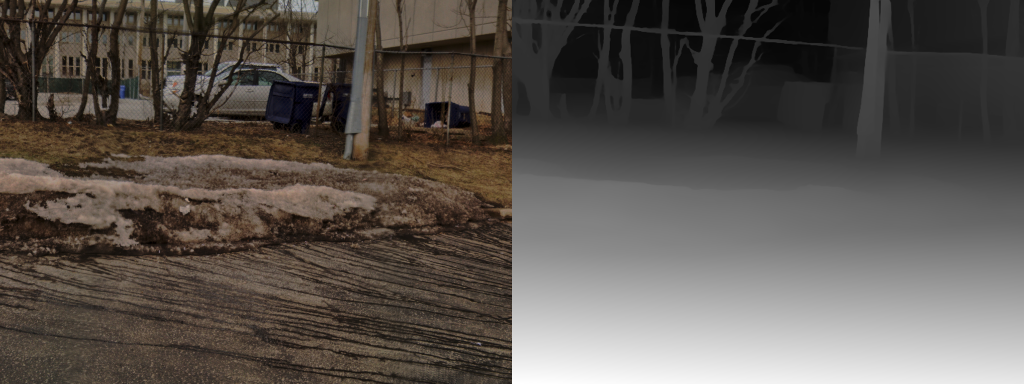

In [ ]:
probe_record = test_records[0]
image = probe_record['image']
print({'ceilings': {'MIN_IMAGE_SIDE': MIN_IMAGE_SIDE, 'MAX_IMAGE_SIDE': MAX_IMAGE_SIDE, 'MAX_ASPECT_RATIO': MAX_ASPECT_RATIO}, 'contract': {'DEPTH_KIND': DEPTH_KIND, 'TRANSFORMER_BLOCKS': TRANSFORMER_BLOCKS, 'PARAMETER_COUNT': PARAMETER_COUNT, 'EVAL_DEPTH_RANGE_M': EVAL_DEPTH_RANGE_M}})
input_manifest = validate_inputs(image, names=[probe_record['id']])
try:
    validate_inputs(Image.new('RGB', (MIN_IMAGE_SIDE, int(MIN_IMAGE_SIDE * (MAX_ASPECT_RATIO + 1)))))
except ValueError as exc:
    input_manifest['findings'].append({'input': 'over-wide-probe', 'verdict': 'rejected', 'message': str(exc)})
with open('outputs/depth_anything_depth_estimation_input_manifest.json', 'w', encoding='utf-8') as handle:
    json.dump(input_manifest, handle, indent=2, ensure_ascii=False)
started = time.perf_counter()
result = pipe.predict(image)
predict_seconds = round(time.perf_counter() - started, 3)
depth = result['depth']
checks = {
    'shape_matches_input': depth.shape == (result['height'], result['width']) == (image.height, image.width),
    'dtype_float32': depth.dtype == np.float32,
    'all_finite': bool(np.isfinite(depth).all()),
    'non_degenerate_range': result['depth_max'] > result['depth_min'],
}
if not all(checks.values()):
    raise RuntimeError(f'depth map failed a sanity check: {checks}')
reference_depth = np.where(probe_record['mask'], probe_record['depth'], 0.0)
report = evaluation_report(result, reference_depth, sample_kind=f"DIODE {probe_record.get('domain', '')} view {probe_record['id']}" if not USE_BYOD else 'BYOD test view')
print({'probe_id': probe_record['id'], 'domain': probe_record.get('domain'), 'seconds': predict_seconds, 'device': pipe.device, 'checks': checks, 'findings': len(input_manifest['findings'])})
print({'verdict': report['verdict'], 'metrics': report['metrics'], 'reason': report['reason']})
assert report['verdict'] == 'sample-sanity' and report['metrics'][0]['id'] == 'abs_rel'

def preview(image, maps):
    tiles = [image.convert('RGB')]
    for m in maps:
        lo, hi = float(m.min()), float(m.max())
        tiles.append(Image.fromarray(np.round((m - lo) / (hi - lo + 1e-9) * 255.0).astype(np.uint8)).convert('RGB'))
    canvas = Image.new('RGB', (image.width * len(tiles), image.height))
    for i, tile in enumerate(tiles):
        canvas.paste(tile, (image.width * i, 0))
    return canvas

try:
    show_image = display  # provided by the isolated worker (and by IPython); IPython is not installed in the isolated environment
except NameError:
    show_image = None
if show_image is not None:
    show_image(preview(image, [depth]).reduce(2))
else:
    print({'preview': 'display unavailable; the preview PNG is written in Section 9'})

## 6. The two priors and the zero-shot policy

Three numbers frame the adaptation, all on the 8 test views. The **constant prior** puts every pixel at the image's own median reference depth — an oracle constant, the strongest flat guess. The **vertical-gradient prior** predicts inverse depth rising from the top row to the bottom row and is aligned exactly like a model prediction: what "the ground is nearer" alone buys. The **zero-shot policy** is `pipe.evaluate` on the untouched checkpoint: mean AbsRel and δ1 over views, per domain and per view. The build record saw the constant prior at AbsRel 0.33, the gradient prior at 0.26 and the zero-shot checkpoint at 0.18 (0.08 indoors, 0.28 outdoors) — read the per-domain split; outdoor DIODE views with sky, foliage and 100 m ranges are where a relative-depth model struggles. Two zero-shot depth maps are kept for the before/after comparison in Section 9. About ten seconds on CPU.

In [ ]:
def brief(m):
    return {'abs_rel': round(m['abs_rel'], 4), 'delta1': round(m['delta1'], 4), 'n': m['n']}

priors = prior_baselines(test_records)
print({'constant_prior': brief(priors['constant_prior']), 'baseline': priors['constant_prior']['baseline']})
print({'vertical_gradient_prior': brief(priors['vertical_gradient_prior']), 'baseline': priors['vertical_gradient_prior']['baseline']})
t0 = time.perf_counter()
zero_shot_test = pipe.evaluate(test_records)
print({'zero_shot_policy': zero_shot_test['policy'], 'test': brief(zero_shot_test), 'per_domain': {d: {'abs_rel': round(v['abs_rel'], 4), 'delta1': round(v['delta1'], 4), 'n': v['n']} for d, v in zero_shot_test['per_domain'].items()}, 'verdict': zero_shot_test['verdict'], 'seconds': round(time.perf_counter() - t0, 1)})
print({'per_view': [(r['id'], r['domain'], round(r['abs_rel'], 3), round(r['delta1'], 3)) for r in zero_shot_test['per_image']]})
print({'definitions': zero_shot_test['definitions']})
show = test_records[:2]
zero_shot_maps = {r['id']: pipe.predict(r['image'])['depth'] for r in show}
assert zero_shot_test['abs_rel'] < priors['constant_prior']['abs_rel'] and zero_shot_test['abs_rel'] < priors['vertical_gradient_prior']['abs_rel']

{'constant_prior': {'abs_rel': 0.3346, 'delta1': 0.5564, 'n': 8}, 'baseline': "every pixel at the image's own median reference depth (oracle constant)"}
{'vertical_gradient_prior': {'abs_rel': 0.2597, 'delta1': 0.5828, 'n': 8}, 'baseline': 'inverse depth rising linearly from the top row to the bottom row, affine-aligned like a prediction'}


{'zero_shot_policy': 'zero-shot (no adaptation)', 'test': {'abs_rel': 0.18, 'delta1': 0.7644, 'n': 8}, 'per_domain': {'indoors': {'abs_rel': 0.075, 'delta1': 0.9485, 'n': 4}, 'outdoor': {'abs_rel': 0.285, 'delta1': 0.5804, 'n': 4}}, 'verdict': 'measured-small-sample', 'seconds': 1.4}
{'per_view': [('test-000', 'outdoor', 0.121, 0.862), ('test-001', 'outdoor', 0.344, 0.656), ('test-002', 'outdoor', 0.404, 0.282), ('test-003', 'indoors', 0.133, 0.898), ('test-004', 'outdoor', 0.271, 0.521), ('test-005', 'indoors', 0.057, 0.956), ('test-006', 'indoors', 0.071, 0.952), ('test-007', 'indoors', 0.039, 0.988)]}
{'definitions': {'alignment': 'per image, least-squares scale and shift mapping the prediction onto 1 / reference depth over the valid pixels inside EVAL_DEPTH_RANGE_M; the aligned inverse depth is floored at 1 / the far cap', 'abs_rel': 'mean over valid pixels of |aligned estimate - reference| / reference, then mean over images', 'delta1': 'fraction of valid pixels with max(estimate /

## 7. The policy ladder: neck and head, then a bounded unfreeze, selected against the checkpoint

`pipe.adapt` scores the untouched checkpoint on the validation views first (epoch 0, the zero-shot policy), then trains the DPT neck and head — 2,728,513 parameters — on the frozen backbone for `HEAD_EPOCHS` epochs (the frozen policy), then unfreezes the last `TRAINABLE_BLOCKS` transformer blocks — two by default, 3,550,464 of 24,785,089 parameters; the patch embedding, the position embedding, the earlier blocks and the final norm stay frozen — and trains them with the neck and head for `EPOCHS` more epochs (the unfrozen policy). Every epoch trains one view at a time with AdamW at `LEARNING_RATE` (weight decay 0.01, gradient clipping 1.0, seeded order, no augmentation) under a scale-and-shift-invariant squared error on inverse depth — the prediction is affinely aligned to the reference in closed form before the residual is taken, because the model's scale and shift are free — and is scored on validation by `evaluate`. The epoch with the **lowest validation AbsRel** is kept and its tensors restored, so the selected policy can be the checkpoint itself.

Watch the validation AbsRel: the build record's ladder at 1e-5 went 0.243 (zero-shot) → 0.220 → 0.194 (neck and head) → 0.139 → 0.133 → 0.130 (unfrozen, still falling at epoch 5, which was selected); at 3e-5 the neck-and-head epoch 2 was selected instead, and at 1e-4 the selected unfreeze scored worse than the checkpoint on the held-out split. The validation views are four scans — one view is an eighth of the number.

In [ ]:
HEAD_EPOCHS = 2  # @param {type:"integer"}
EPOCHS = 3  # @param {type:"integer"}
LEARNING_RATE = 1e-5  # @param {type:"number"}
TRAINABLE_BLOCKS = 2  # @param {type:"integer"}

def report_epoch(entry):
    row = {'epoch': entry['epoch'], 'stage': entry['stage'], 'train_loss': round(entry['train_loss'], 4) if entry['train_loss'] is not None else None}
    if entry.get('val'):
        row['val_abs_rel'] = round(entry['val']['abs_rel'], 4)
        row['val_delta1'] = round(entry['val']['delta1'], 4)
    print(row)

t0 = time.perf_counter()
adapt_result = pipe.adapt(train_records, val_records, trainable_blocks=TRAINABLE_BLOCKS, head_epochs=HEAD_EPOCHS, epochs=EPOCHS, lr=LEARNING_RATE, progress=report_epoch)
adapt_seconds = round(time.perf_counter() - t0, 1)
report_epoch(adapt_result['history'][0])
print({'selected_policy': adapt_result['policy'], 'best_epoch': adapt_result['best_epoch'], 'selection': adapt_result['selection'], 'trainable_neck_head': adapt_result['n_trainable_head'], 'trainable_blocks': adapt_result['n_trainable_blocks'], 'total_parameters': adapt_result['n_total'], 'seconds': adapt_seconds})

{'epoch': 1, 'stage': 'frozen backbone + DPT neck and head', 'train_loss': 0.3717, 'val_abs_rel': 0.2201, 'val_delta1': 0.8218}


{'epoch': 2, 'stage': 'frozen backbone + DPT neck and head', 'train_loss': 0.3628, 'val_abs_rel': 0.1937, 'val_delta1': 0.8309}


{'epoch': 3, 'stage': 'unfrozen last 2 blocks + DPT neck and head', 'train_loss': 0.352, 'val_abs_rel': 0.1394, 'val_delta1': 0.8674}


{'epoch': 4, 'stage': 'unfrozen last 2 blocks + DPT neck and head', 'train_loss': 0.3356, 'val_abs_rel': 0.1328, 'val_delta1': 0.8577}


{'epoch': 5, 'stage': 'unfrozen last 2 blocks + DPT neck and head', 'train_loss': 0.3241, 'val_abs_rel': 0.1295, 'val_delta1': 0.8713}
{'epoch': 0, 'stage': 'zero-shot (no adaptation)', 'train_loss': None, 'val_abs_rel': 0.2426, 'val_delta1': 0.8121}
{'selected_policy': 'unfrozen last 2 blocks + DPT neck and head', 'best_epoch': 5, 'selection': 'lowest validation AbsRel (epoch 0 = zero-shot checkpoint)', 'trainable_neck_head': 2728513, 'trainable_blocks': 3550464, 'total_parameters': 24785089, 'seconds': 24.0}


## 8. Held-out evaluation

The test split was never used for training or policy selection, and no scan in it appears in the training or validation splits. The selected model is scored exactly as the checkpoint was in Section 6, and the four rows are put side by side: constant prior, vertical-gradient prior, zero-shot policy, selected policy — with per-domain and per-view AbsRel. Read the policy first: if validation kept epoch 0, the last two rows are the same model; otherwise the delta is what the adaptation bought on 8 views. The build record saw AbsRel 0.180 → 0.167 and δ1 0.764 → 0.765 at the default settings — a small gain concentrated outdoors, within the grain of an 8-view split. The cell asserts the selected model beats both priors; it does **not** assert a gain over the checkpoint, because that is the question, not the answer. Eight views from four scans of one seeded split give no dispersion estimate.

In [ ]:
adapted_test = pipe.evaluate(test_records)
adapted_val = pipe.evaluate(val_records)
comparison = {
    metric: {'constant_prior': round(priors['constant_prior'][metric], 4), 'vertical_gradient_prior': round(priors['vertical_gradient_prior'][metric], 4), 'zero_shot': round(zero_shot_test[metric], 4), 'selected_policy': round(adapted_test[metric], 4)}
    for metric in ('abs_rel', 'delta1')
}
comparison['per_domain_abs_rel'] = {d: {'zero_shot': round(zero_shot_test['per_domain'][d]['abs_rel'], 4), 'selected': round(v['abs_rel'], 4)} for d, v in adapted_test['per_domain'].items()}
comparison['per_view_abs_rel'] = {z['id']: {'zero_shot': round(z['abs_rel'], 4), 'selected': round(a['abs_rel'], 4)} for z, a in zip(zero_shot_test['per_image'], adapted_test['per_image'])}
comparison['delta_vs_zero_shot'] = {metric: round(adapted_test[metric] - zero_shot_test[metric], 4) for metric in ('abs_rel', 'delta1')}
comparison['selected_policy'] = adapt_result['policy']
for metric, row in comparison.items():
    print({metric: row})
evaluation_report_payload = {
    'model': {'id': MODEL_ID, 'revision': MODEL_REVISION, 'key': MODEL_KEY},
    'data_source': data_source,
    'dataset_digests': {name: manifest['digest'] for name, manifest in dataset_manifests.items()},
    'splits': disjoint,
    'scan_summary': summary,
    'single_view_report': report,
    'priors': {k: {kk: vv for kk, vv in v.items() if kk != 'per_image'} for k, v in priors.items()},
    'zero_shot_test': zero_shot_test,
    'validation_metrics': adapted_val,
    'test_metrics': adapted_test,
    'comparison': comparison,
    'adaptation': {k: v for k, v in adapt_result.items() if k not in ('history', 'trainable_names')},
    'history': adapt_result['history'],
    'adaptation_seconds': adapt_seconds,
}
with open('outputs/depth_anything_depth_estimation_evaluation_report.json', 'w', encoding='utf-8') as f:
    json.dump(evaluation_report_payload, f, indent=2, ensure_ascii=False)
assert adapted_test['abs_rel'] < priors['constant_prior']['abs_rel'] and adapted_test['abs_rel'] < priors['vertical_gradient_prior']['abs_rel']
print({'report': 'outputs/depth_anything_depth_estimation_evaluation_report.json'})

{'abs_rel': {'constant_prior': 0.3346, 'vertical_gradient_prior': 0.2597, 'zero_shot': 0.18, 'selected_policy': 0.1669}}
{'delta1': {'constant_prior': 0.5564, 'vertical_gradient_prior': 0.5828, 'zero_shot': 0.7644, 'selected_policy': 0.7652}}
{'per_domain_abs_rel': {'indoors': {'zero_shot': 0.075, 'selected': 0.0705}, 'outdoor': {'zero_shot': 0.285, 'selected': 0.2634}}}
{'per_view_abs_rel': {'test-000': {'zero_shot': 0.1212, 'selected': 0.164}, 'test-001': {'zero_shot': 0.3444, 'selected': 0.3064}, 'test-002': {'zero_shot': 0.4037, 'selected': 0.3594}, 'test-003': {'zero_shot': 0.1326, 'selected': 0.0988}, 'test-004': {'zero_shot': 0.2705, 'selected': 0.2236}, 'test-005': {'zero_shot': 0.0575, 'selected': 0.076}, 'test-006': {'zero_shot': 0.071, 'selected': 0.0734}, 'test-007': {'zero_shot': 0.0391, 'selected': 0.0339}}}
{'delta_vs_zero_shot': {'abs_rel': -0.0131, 'delta1': 0.0008}}
{'selected_policy': 'unfrozen last 2 blocks + DPT neck and head'}
{'report': 'outputs/depth_anything_de

## 9. Depth maps before and after, export the adapter and reload it

Two test views are predicted by the selected model and rendered beside the zero-shot maps kept in Section 6 (image | zero-shot | selected, normalised per map, brighter = nearer) with each map's aligned AbsRel; `outputs/depth_anything_depth_estimation_preview.png` holds the render. A relative-depth map is a per-image ordering, so read the pair for structure — where the selected model places the ground plane, the walls, the far field — not for absolute brightness.

`pipe.save_artifact` writes the DPT neck and head tensors and, when the unfrozen policy was selected, the trained block tensors — 10.9 MB for neck and head, 25.1 MB with two blocks — as `adapter.safetensors`, with a `manifest.json` recording the artifact format, the base model id and revision, the digest of the base `model.safetensors`, the selected policy, the tensor names, the file size and SHA-256, the training configuration and the epoch history (OUT8). `DepthAnythingPipeline.from_artifact` re-verifies the base snapshot, checks the artifact manifest and digest **before** deserialising, refuses any tensor that is not a neck, head or transformer-block tensor of the base, and overlays the tensors onto a freshly loaded base — a new object from files, not the in-memory model (VER2). The cell asserts an identical depth map on a test view and an identical test AbsRel (VER4).

{'id': 'test-000', 'domain': 'outdoor', 'zero_shot_abs_rel': 0.1212, 'selected_abs_rel': 0.164, 'source_url': 'https://share.phys.ethz.ch/~pf/bingkedata/marigold/evaluation_dataset/diode/diode_val.tar#outdoor/scene_00023/scan_00199/00023_00199_outdoor_010_000.png'}
{'id': 'test-001', 'domain': 'outdoor', 'zero_shot_abs_rel': 0.3444, 'selected_abs_rel': 0.3064, 'source_url': 'https://share.phys.ethz.ch/~pf/bingkedata/marigold/evaluation_dataset/diode/diode_val.tar#outdoor/scene_00024/scan_00202/00024_00202_outdoor_070_010.png'}


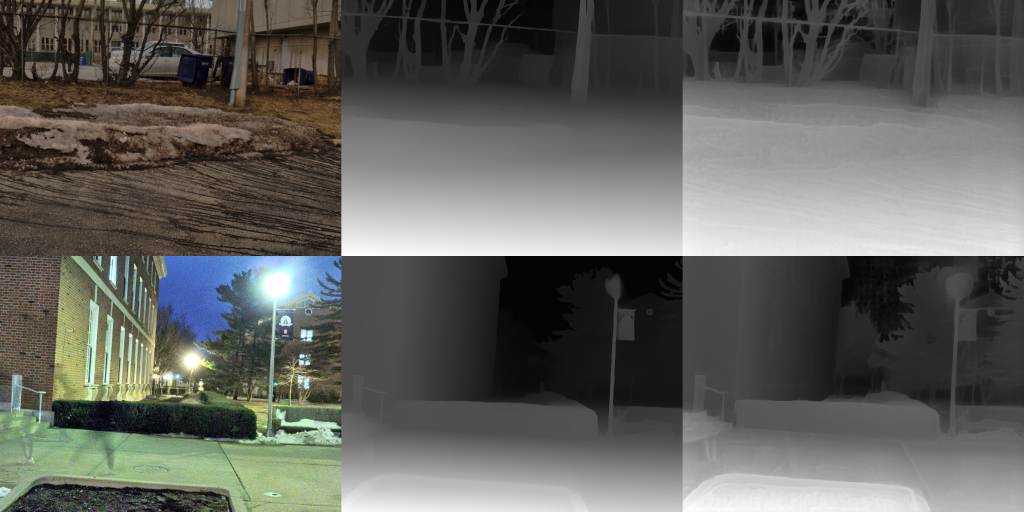

{'artifact': 'outputs/depth_anything_depth_estimation_adapter', 'format': 'org.valcorza.depth-anything-v2-small.adapter.v1', 'policy': 'unfrozen last 2 blocks + DPT neck and head', 'tensors': 100, 'bytes': 25127700, 'sha256': '504722cefde7fd44...'}


{'reload_parity': {'depth_map_identical': True, 'abs_rel_in_memory': 0.166934, 'abs_rel_reloaded': 0.166934}, 'reloaded_policy': 'unfrozen last 2 blocks + DPT neck and head', 'reloaded_best_epoch': 5}
['depth_anything_depth_estimation_adapter', 'depth_anything_depth_estimation_evaluation_report.json', 'depth_anything_depth_estimation_input_manifest.json', 'depth_anything_depth_estimation_preview.png', 'depth_anything_depth_estimation_result.json', 'depth_anything_depth_estimation_train.csv']


In [ ]:
import shutil

rows = []
canvases = []
for record in show:
    after = pipe.predict(record['image'])['depth']
    before = zero_shot_maps[record['id']]
    rows.append({'id': record['id'], 'domain': record.get('domain', ''), 'zero_shot_abs_rel': round(aligned_abs_rel(before, record['depth'], record['mask']), 4), 'selected_abs_rel': round(aligned_abs_rel(after, record['depth'], record['mask']), 4), 'source_url': record.get('source_url', '')})
    print(rows[-1])
    canvases.append(preview(record['image'], [before, after]))
sheet = Image.new('RGB', (max(c.width for c in canvases), sum(c.height for c in canvases)))
y = 0
for c in canvases:
    sheet.paste(c, (0, y))
    y += c.height
sheet.save('outputs/depth_anything_depth_estimation_preview.png')
if show_image is not None:
    show_image(sheet.reduce(3))

artifact_dir = Path('outputs/depth_anything_depth_estimation_adapter')
shutil.rmtree(artifact_dir, ignore_errors=True)
pipe.save_artifact(artifact_dir, metadata={'tutorial': 'depth_anything_depth_estimation', 'data_source': data_source})
artifact_manifest = json.loads((artifact_dir / 'manifest.json').read_text(encoding='utf-8'))
print({'artifact': str(artifact_dir), 'format': artifact_manifest['format'], 'policy': artifact_manifest['adapter']['policy'], 'tensors': len(artifact_manifest['tensors']), 'bytes': artifact_manifest['files'][0]['bytes'], 'sha256': artifact_manifest['files'][0]['sha256'][:16] + '...'})

reloaded = DepthAnythingPipeline.from_artifact(artifact_dir, weights_dir=WEIGHTS_DIR, device=pipe.device)
reloaded_map = reloaded.predict(show[0]['image'])['depth']
reloaded_test = reloaded.evaluate(test_records)
parity = {'depth_map_identical': bool(np.array_equal(reloaded_map, pipe.predict(show[0]['image'])['depth'])), 'abs_rel_in_memory': round(adapted_test['abs_rel'], 6), 'abs_rel_reloaded': round(reloaded_test['abs_rel'], 6)}
print({'reload_parity': parity, 'reloaded_policy': reloaded.adapter['policy'], 'reloaded_best_epoch': reloaded.adapter['best_epoch']})
assert parity['depth_map_identical'] and abs(adapted_test['abs_rel'] - reloaded_test['abs_rel']) < 1e-9

weight_entry = next(entry for entry in MANIFEST['files'] if entry['path'] == WEIGHTS_FILE)
result_payload = {
    'notebook_source': NOTEBOOK_SOURCE,
    'repository_revision': NOTEBOOK_SOURCE['repository_revision'],
    'model_id': MODEL_ID,
    'model_revision': MODEL_REVISION,
    'model_license': MODEL_LICENSE,
    'snapshot': {'path': str(WEIGHTS_DIR), 'files': snapshot['files'], 'total_bytes': snapshot.get('total_bytes'), 'fetched_this_run': fetched, 'weight_file': WEIGHTS_FILE, 'weight_format': 'safetensors, digest-verified', 'weight_sha256': weight_entry['sha256']},
    'data_source': data_source,
    'corpus': {'name': CORPUS_NAME, 'release': CORPUS_RELEASE, 'url': CORPUS_URL, 'archive_bytes': CORPUS_ARCHIVE_BYTES, 'views': len(SAMPLE_RECORDS), 'bytes': CORPUS_BYTES, 'license': CORPUS_LICENSE},
    'inference_contract': {'input_manifest': input_manifest, 'sanity_checks': checks, 'probe_id': probe_record['id'], 'single_view_report': report, 'seconds': predict_seconds},
    'comparison': comparison,
    'before_after': rows,
    'preview_file': 'outputs/depth_anything_depth_estimation_preview.png',
    'artifact': {'dir': str(artifact_dir), 'sha256': artifact_manifest['files'][0]['sha256'], 'bytes': artifact_manifest['files'][0]['bytes'], 'tensors': len(artifact_manifest['tensors']), 'policy': artifact_manifest['adapter']['policy']},
    'reload_parity': parity,
    'runtime': {'python': platform.python_version(), 'torch': torch.__version__, 'transformers': transformers.__version__, 'device': pipe.device, 'dtype': 'float32', 'source': pipe.source},
}
with open('outputs/depth_anything_depth_estimation_result.json', 'w', encoding='utf-8') as handle:
    json.dump(result_payload, handle, indent=2, ensure_ascii=False)
print(sorted(os.listdir('outputs')))

## Interpretation and limits

The untouched Depth Anything V2 Small checkpoint already beats both priors by a wide margin on eight DIODE views (AbsRel 0.18 against 0.26 and 0.33), and a bounded adaptation on 24 training views — neck and head first, then the last two blocks, selected against the checkpoint by validation AbsRel — was selected at its last epoch and lowered held-out AbsRel from 0.180 to 0.167 in the build record, almost all of it outdoors. That is the claim and the finding: the adaptation contract runs a three-policy ladder end to end on a real RGB-D corpus, lets the checkpoint win when it should, and reports the answer against two priors rather than in isolation.

The test split is eight views from four scans of one seeded split of one small corpus with no dispersion estimate — one view is an eighth of every mean, and two views of one scan are nearly the same scene. AbsRel and δ1 are computed after a per-image affine alignment inside 0.6..350 m, so they say how well the *ordering and relative spacing* of depth match the laser reference, not whether any metre is right; the model's output stays relative after adaptation. A gain of 0.013 AbsRel at 1e-5 turned into a loss at 1e-4 in the build sweep, and the neck-and-head-only policy won at 3e-5: the ladder's outcome is a property of this corpus and these hyperparameters, not of the method.

Three things to carry to real data. **Priors first:** the constant and gradient priors on *your* depth maps are the numbers to read before any model's — a scene that a vertical gradient explains is not testing the model. **Leakage:** split by capture session, scan or device (the contract splits by `scan` / `group`, never by view). **Policy:** the untouched checkpoint is a policy too; keep it in the ladder and let validation decide, and keep the learning rate small — a 25 M-parameter model trained on 62 million images has little to learn from 24 views except your sensor's habits.

Successful execution proves that the recorded repository revision's pipeline modules, carried in this standalone notebook, can acquire and digest-verify the pinned model snapshot, fetch and digest-verify a real RGB-D corpus, validate the demonstrated dataset contract without leakage, execute the inference contract with a `sample-sanity` metric against a laser reference, run the zero-shot, frozen and unfrozen policies with validation-based selection, evaluate by aligned AbsRel and δ1 against two priors on an independent split, and emit the shown machine-readable artifacts — without the repository being reachable. It does **not** establish benchmark superiority, metric accuracy, a usable acceptance threshold, or production fitness.

**Optional experiments (they do not affect the default path):** set `LEARNING_RATE = 3e-5` and watch the neck-and-head policy win on validation (the build record: epoch 2, held-out 0.175); set `LEARNING_RATE = 1e-4` and read what a hot unfreeze does to the held-out split (selected on validation, 0.186 on test — worse than the checkpoint); set `TRAINABLE_BLOCKS = 4` (the build record: neck and head selected, 0.175); set `EPOCHS = 6` and watch whether validation AbsRel keeps falling; or bring your own RGB-D records through BYOD and read the priors before either policy.

## References

- Repository README: https://github.com/kurtvalcorza/depth-anything-depth-estimation-pipeline/blob/main/README.md
- Repository model card: https://github.com/kurtvalcorza/depth-anything-depth-estimation-pipeline/blob/main/MODEL_CARD.md
- Weight provenance: https://github.com/kurtvalcorza/depth-anything-depth-estimation-pipeline/blob/main/docs/WEIGHTS.md
- Upstream model: https://huggingface.co/depth-anything/Depth-Anything-V2-Small-hf
- Upstream code: https://github.com/DepthAnything/Depth-Anything-V2
- Depth Anything V2 paper (Yang et al., 2024): https://arxiv.org/abs/2406.09414
- DIODE: A Dense Indoor and Outdoor DEpth Dataset (Vasiljevic et al., 2019; CC BY 4.0): https://diode-dataset.org — https://arxiv.org/abs/1908.00463
- Marigold evaluation dataset archive (ETH Zürich PRS) serving the pinned DIODE files: https://share.phys.ethz.ch/~pf/bingkedata/marigold/evaluation_dataset/diode/diode_val.tar
- Towards Robust Monocular Depth Estimation (MiDaS; the scale-and-shift-invariant loss and aligned evaluation, Ranftl et al., 2020): https://arxiv.org/abs/1907.01341
- Transformers `DepthAnything` documentation: https://huggingface.co/docs/transformers/model_doc/depth_anything
- DIMER Notebook Specification 2.0 and Model Card Specification 1.1 (fleet specs in the ml-worker repository)